---
<div align="center">

#  **Trabajo Fin de Master**

## **Sistema de Proyección de Trayectorias de Carrera en Baseball: Integración de Clustering y Series Temporales para la Predicción de Performance**
</div>

<div align="center">
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTRJwgy7d4BlYXlHCOxbKQtZwD7lB5esQW2Hw&s" alt="Escudo Universidad Complutense de Madrid" width="150"/>

**Universidad Complutense de Madrid**  
**Máster Data Science, Big Data & Business Analytics**

**Autor:** Sergio Grigorow  
**Tutores:** Carlos Ortega y Santiago Mota  
**Curso Académico:** 2024-2025
</div>

---

## **Introducción**

Los equipos de béisbol invierten cientos de millones de dólares en contratos de larga duración. Cuando se equivocan, las consecuencias pueden arrastrarse durante años. Un ejemplo es Albert Pujols, quien firmó un contrato de $240 millones con los Angels, pero nunca alcanzó el nivel de rendimiento esperado. Algo similar ocurrió con Prince Fielder, que se retiró a mitad de su contrato de $214 millones debido a lesiones. Estos casos no son excepcionales; representan un riesgo constante en la toma de decisiones de las franquicias.

El verdadero desafío es anticipar el rendimiento futuro de un jugador. Aunque los equipos cuentan hoy con más datos que nunca, la predicción sigue siendo una tarea compleja. Las lesiones, el declive físico asociado a la edad, o incluso la falta de adaptación a un nuevo equipo son factores difíciles de modelar. Y en una liga sin tope salarial como la MLB, un error de gran magnitud puede hipotecar el presupuesto de una organización durante años.

Existen sistemas profesionales de proyección, como ZiPS y Steamer, que abordan este problema con bastante eficacia. Sin embargo, estos modelos son complejos y funcionan como cajas negras, lo que dificulta su interpretación. Desde una perspectiva académica, surge una pregunta interesante: ¿es posible desarrollar un enfoque más sencillo y transparente que logre resultados competitivos?

Este trabajo busca explorar esa interrogante. La propuesta combina técnicas de clustering para identificar perfiles de jugadores, junto con análisis temporal para modelar las curvas de envejecimiento (aging curves). Utilizaremos más de 80 años de datos históricos de MLB con el objetivo de predecir el OPS futuro de los jugadores. No se pretende superar a los sistemas comerciales, sino demostrar que metodologías académicas pueden ofrecer soluciones competitivas y, sobre todo, más interpretables.
 
### **Objetivo**

El objetivo de este proyecto es construir un modelo que permita predecir el OPS futuro de los jugadores de la MLB, empleando dos enfoques complementarios: clustering para identificar arquetipos de jugadores y análisis temporal para capturar la evolución de sus carreras a lo largo del tiempo.

El conjunto de datos abarca el periodo de 1940 a 2023, lo que nos proporciona más de 80 años de información para analizar patrones de envejecimiento y las distintas eras del béisbol. Debido a los cambios en el entorno competitivo, se aplicará una normalización por época, ya que un promedio de bateo de .300 no tiene el mismo significado en 1960 que en 2020.

La métrica seleccionada para la predicción es el OPS (On-base Plus Slugging). Aunque no es una medida perfecta, ofrece una visión integral del rendimiento ofensivo al combinar la capacidad de embasarse con el poder de bateo. Además, resulta más intuitiva que otras métricas avanzadas.

La fase de clustering tiene como objetivo identificar arquetipos naturales de jugadores, tales como power hitters, contact hitters y speedsters. La hipótesis es que los jugadores con perfiles similares tienden a experimentar trayectorias de rendimiento comparables a lo largo de sus carreras. Por su parte, el componente temporal permitirá modelar cómo varía el rendimiento con la edad y la experiencia, capturando así las dinámicas evolutivas de cada tipo de jugador.


### **Alcance**

Este proyecto abarca el desarrollo completo del sistema predictivo: extracción y limpieza de datos, análisis exploratorio, modelado, validación y deployment. Los datos incluyen 83 años de MLB (1940-2023) con más de 100,000 registros de bateo, 150,000 de fildeo y 21,000 jugadores únicos.  

El trabajo incluye consolidación de múltiples datasets, análisis exploratorio por épocas y posiciones, ingeniería de features con ajuste temporal, clustering para identificar arquetipos ofensivos, entrenamiento y validación de modelos predictivos, benchmarking contra sistemas profesionales (ZiPS/Steamer), y desarrollo de una aplicación interactiva en Streamlit publicada en GitHub. 

Quedan fuera del alcance del presente proyecto:

- **Ligas menores.** Solo jugadores con mínimo 3 años en MLB. Entendemos que, aunque esto crea sesgo de supervivencia (el modelo solo conoce jugadores que "llegaron" y permanecieron), añadiría una complejidad adicional al proyecto, particularmente en la recolección de datos, que no vamos a abordar.  Esto implica que las predicciones se fundamentan en jugadores establecidos, mas no en novatos.  
- **Factores contextuales.** No se modelan lesiones, cambios de equipo, modificaciones reglamentarias, o efectos de parque. Estos factores impactan significativamente el rendimiento pero están fuera del alcance.  
- **Métricas defensivas.** El modelo predice únicamente OPS (rendimiento ofensivo). WAR sería una métrica más completa, pero requeriría modelar contribución defensiva.


### **Objetivos Especificos**

- **Identificar tipos de jugadores (arquetipos) utilizando técnicas de clustering**, aprovechando similitudes en estilos y trayectorias de carrera.  
- **Construir un modelo que capte los patrones de envejecimiento** y evolución del rendimiento a lo largo del tiempo.  
- **Superar el rendimiento del método de predicción base** (“Carry-Forward”), que asume que el jugador mantendrá su nivel actual sin ajustes.    
- **Probar el modelo con casos reales** Validar con jugadores históricos y comparar contra sistemas profesionales.  
- **Construir una aplicación funcional** que nos permita obtener proyecciones simples con bandas de confianza.
   

### **Estructura del Trabajo**

- **Secciones 1-3:** Configuración del entorno, descarga de datos y exploración inicial de los datasets.  
- **Sección 4:** Feature engineering avanzado con consolidación multi-equipo y normalización temporal.  
- **Sección 5:** Análisis exploratorio exhaustivo, curvas de envejecimiento y identificación de arquetipos.  
- **Sección 6:** Implementación de clustering para clasificación de patrones de jugadores.  
- **Sección 7:** Desarrollo y validación de modelos predictivos.  
- **Sección 8:** Validación de modelo con caso practico.  
- **Sección 9:** Benchamark con estándares de la industria.  
- **Seccion 10:** Desarrollo de función productiva y preparación para producción.   
- **app.py:** Aplicacion funcional interactiva



---
# 📦**SECCIÓN 1: IMPORTACIÓN DE LIBRERÍAS**
---
## **Objetivo**

El objetivo de esta sección es importar todas las librerías y módulos de Python necesarios para el desarrollo de nuestro proyecto. Esto garantiza que tengamos acceso a todas las funcionalidades y herramientas requeridas para la manipulación de datos, el análisis exploratorio, la construcción de modelos de machine learning y la visualización de resultados.

## **Librerías Utilizadas**

Las librerías seleccionadas responden a los requerimientos específicos del proyecto:

- **Pandas y NumPy**: Manipulación de datasets de baseball y operaciones numéricas
- **Matplotlib y Seaborn**: Generación de gráficos para análisis exploratorio y presentación de resultados  
- **Scikit-learn**: Algoritmos de clustering (K-means), preprocesamiento (StandardScaler) y modelos predictivos (Random Forest, Ridge)
- **XGBoost**: Implementación de gradient boosting para comparación de performance
- **Joblib**: Serialización de modelos entrenados para productivización
- **OS y gdown**: Gestión de directorios y descarga automatizada de datasets

Esta configuración proporciona las funcionalidades necesarias para abordar tanto el componente de clustering como el de series temporales del sistema híbrido propuesto.

In [1]:
#===================
#SECCIÓN 1: IMPORTAR LIBRERIAS
#===================    

# =============================================================================
# LIBRERÍAS BÁSICAS
# =============================================================================
import os
import warnings
import joblib
import gdown

# =============================================================================
# MANEJO DE DATOS
# =============================================================================
import pandas as pd
import numpy as np
from math import pi
import random

# =============================================================================
# VISUALIZACIÓN
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# PREPROCESAMIENTO
# =============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =============================================================================
# MODELADO
# =============================================================================
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# =============================================================================
# MÉTRICAS DE EVALUACIÓN
# =============================================================================
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score

# =============================================================================
# CONFIGURACIONES
# =============================================================================
warnings.filterwarnings('ignore')



---
# 🗂️**SECCIÓN 2: CARGA DE DATOS**
---
## **Objetivo**

El objetivo principal de esta sección es descargar y cargar los datasets de baseball necesarios para el proyecto. Esta sección establece la base de datos que alimentará todo el sistema de proyección, asegurando que los archivos estén disponibles localmente y sean accesibles para las etapas posteriores de procesamiento.

## **Metodología**

Implementaremos un sistema automatizado de descarga desde Google Drive que verifica la existencia de archivos antes de descargarlos, evitando transferencias innecesarias. Los datos se organizarán en una estructura de directorios  (`data/raw` y `data/processed`) que facilita la gestión del proyecto y mantiene separados los datos originales de los procesados.

La descarga utiliza la librería `gdown` para acceder a archivos públicos de Google Drive mediante sus identificadores únicos, garantizando la reproducibilidad del proceso de obtención de datos.

## **Datos Utilizados**

El proyecto utiliza cuatro datasets principales del baseball profesional:

**Batting.csv**: Contiene estadísticas ofensivas por jugador y temporada, incluyendo hits, home runs, bases por bolas y otras métricas de bateo que serán fundamentales para calcular OPS y variables derivadas.

**Fielding.csv**: Incluye estadísticas defensivas y información de posiciones por jugador y temporada, necesaria para caracterizar perfiles de jugadores y crear features de clustering.

**People.csv**: Proporciona información demográfica y física de los jugadores (fecha de nacimiento, peso, altura, lateralidad), esencial para calcular edad y BMI.

**Real_Projections_2024.csv**: Contiene proyecciones reales de sistemas como Steamer y ZiPS para la temporada 2024, que utilizaremos como benchmark para validar la performance de nuestro modelo.

## **Importancia**

La calidad de estos datos determina la validez de todo el análisis posterior. Los datasets seleccionados cubren múltiples décadas de baseball profesional, proporcionando la profundidad temporal necesaria para analizar patrones de carrera y envejecimiento, elementos centrales en nuestro sistema de proyección.

In [2]:
# =============================================================================
# SECCIÓN 2: CARGA DE DATOS
# =============================================================================

# Creación de estructura de directorios para organizar datos originales y procesados
if not os.path.exists("data/raw"):
    os.makedirs("data/raw")
    print("Carpeta 'data/raw' creada")
    
if not os.path.exists("data/processed"):
    os.makedirs("data/processed")
    print("Carpeta 'data/processed' creada")

# Diccionario que mapea archivos con sus IDs de Google Drive para descarga automatizada
files = {
    'Batting.csv': '1Bk1V-uAHId0LdDFnVvewFu-8wekzHOKG',
    'Fielding.csv': '1VRzQWD404CZKleR0NVBf-js_0_lJKTac',
    'People.csv': '1s5Sm91vwB_gkGEM5KhfrDDPJqCeXofrJ',
    'Real_Projections_2024.csv': '1_7ZluZJAs1c3OTpbGqhfC3KX0zJjje0D',
}

# Sistema de descarga condicional que evita descargas innecesarias
for filename, file_id in files.items():
    filepath = f"data/raw/{filename}"
    if not os.path.exists(filepath):
        print(f"Descargando {filename}...")
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, filepath, quiet=True)
        print(f"{filename} descargado")
    else:
        print(f"{filename} ya existe")

# Carga de los datasets principales del proyecto
batting = pd.read_csv("data/raw/Batting.csv")
fielding = pd.read_csv("data/raw/Fielding.csv")
people = pd.read_csv("data/raw/People.csv", encoding='latin1')

# Verificación de dimensiones de los datasets cargados
print(f"\nDatos cargados:")
print(f"Batting: {batting.shape}")
print(f"Fielding: {fielding.shape}")
print(f"People: {people.shape}")

# Definición de constantes de rutas para mantenimiento del código
DATA_RAW_PATH = "data/raw"
DATA_PROCESSED_PATH = "data/processed"

Carpeta 'data/raw' creada
Carpeta 'data/processed' creada
Descargando Batting.csv...
Batting.csv descargado
Descargando Fielding.csv...
Fielding.csv descargado
Descargando People.csv...
People.csv descargado
Descargando Real_Projections_2024.csv...
Real_Projections_2024.csv descargado

Datos cargados:
Batting: (113799, 24)
Fielding: (151507, 18)
People: (21010, 25)


## **Resultados de Carga de Datos**

La carga de datos se completó exitosamente, obteniendo tres datasets con las siguientes dimensiones:

**Batting**: 113,799 registros con 24 variables por observación  
**Fielding**: 151,507 registros con 18 variables por observación  
**People**: 21,010 registros con 25 variables por observación

## **Análisis de Resultados**

La diferencia en la cantidad de registros entre los distintos datasets es esperada y refleja la propia naturaleza de los datos de béisbol. El dataset de Fielding presenta más registros que el de Batting, ya que un jugador puede acumular múltiples entradas en una misma temporada si cambia de posición o de equipo durante el transcurso del año.

El dataset People cuenta con 21,010 jugadores únicos, lo que evidencia que los datasets de rendimiento (Batting y Fielding) contienen múltiples temporadas por jugador. Esta profundidad temporal es precisamente la que nos permitirá analizar las trayectorias de carrera con el nivel de detalle necesario.

En cuanto a la estructura de variables, Batting dispone de 24 columnas que incluyen todas las estadísticas ofensivas requeridas para calcular el OPS y otras métricas derivadas. Por su parte, Fielding aporta 18 variables con información sobre las posiciones defensivas desempeñadas, un aspecto clave para el clustering de perfiles de jugadores. Finalmente, el dataset People ofrece 25 variables con datos demográficos y físicos, indispensables para calcular la edad de los jugadores y caracterizar su perfil físico.

En conjunto, esta estructura de datos confirma que contamos con la información necesaria para implementar el sistema híbrido de proyección planteado, combinando análisis de perfiles y trayectorias de rendimiento de manera robusta y transparente.

---
# 🔗**SECCIÓN 3.1: UNIÓN DE DATOS Y FILTRO DE CALIDAD**
---
## **Objetivo**

El objetivo de esta sección es consolidar los tres datasets en una estructura unificada y aplicar filtros de calidad que aseguren la integridad del análisis posterior. 

## **Metodología**

Implementaremos una estrategia de agregación que maneja los casos donde jugadores aparecen múltiples veces en una temporada debido a cambios de equipo. Las estadísticas ofensivas se sumarán para obtener totales anuales, mientras que la información de equipo y liga se tomará del último registro de cada temporada.

Para las estadísticas defensivas utilizaremos el registro con mayor número de juegos por temporada, asumiendo que representa la posición principal del jugador. La unión de datos se realizará mediante joins se que preserven la máxima cantidad de información disponible.

## **Filtros de Calidad Aplicados**

El filtro principal se basa en Plate Appearances (PA) como indicador de tiempo de juego significativo. Estableceremos un umbral mínimo de 250 PA para temporadas normales, con excepciones para años con temporadas acortadas por huelgas y pandemia (1981, 1994, 2020) donde se reduce a 150 PA.

Adicionalmente, limitaremos el análisis a partir de 1940 para mantener consistencia en la calidad y disponibilidad de datos estadísticos. Este corte temporal asegura que trabajemos con datos del baseball moderno, donde las métricas están mejor documentadas.

In [3]:
# =============================================================================
# SECCIÓN 3.1: UNIÓN DE DATOS Y FILTRO DE CALIDAD
# =============================================================================

# Identificación de columnas numéricas para agregación posterior
numeric_cols = batting.select_dtypes(include=[np.number]).columns.tolist()
# Exclusión de columnas que no deben sumarse (stint como contador, yearID como identificador)
sum_cols = [col for col in numeric_cols if col not in ['stint', 'yearID']]

# Obtención del último equipo y liga del jugador en cada temporada para preservar información final
last_team_info = batting.sort_values(['playerID', 'yearID', 'stint']).groupby(['playerID', 'yearID']).last()[['teamID', 'lgID']].reset_index()

# Agregación de estadísticas de bateo por jugador y año, sumando múltiples stints
batting_aggregated = batting.groupby(['playerID', 'yearID'])[sum_cols].sum().reset_index()

# Unión de estadísticas agregadas con información del último equipo
batting_clean = batting_aggregated.merge(last_team_info, on=['playerID', 'yearID'], how='left')

# Determinación de la posición principal por temporada basada en juegos jugados
fielding_main = fielding.sort_values(['playerID', 'yearID', 'G'], ascending=[True, True, False])
fielding_main = fielding_main.groupby(['playerID', 'yearID']).first().reset_index()
fielding_main = fielding_main[['playerID', 'yearID', 'POS']]

# Selección de variables demográficas relevantes para el análisis
people_subset = people[['playerID', 'birthYear', 'nameFirst', 'nameLast', 'weight', 'height', 'bats']]

# Construcción del dataset integrado mediante joins secuenciales
df = batting_clean.merge(fielding_main, on=['playerID', 'yearID'], how='left')
df = df.merge(people_subset, on='playerID', how='left')

# Cálculo de apariciones en el plato (PA) como métrica de volumen de participación
df['PA'] = df['AB'] + df['BB'] + df['HBP'] + df['SF'] + df['SH']

# Definición de temporadas especiales con calendarios reducidos
special_years = [1981, 1994, 2020]

# Aplicación de filtros de calidad: período moderno y umbral mínimo de PA ajustado por tipo de temporada
df = df[
    (df['yearID'] >= 1940) &
    (((df['yearID'].isin(special_years)) & (df['PA'] >= 150)) |
     ((~df['yearID'].isin(special_years)) & (df['PA'] >= 250)))
].copy()

# Reporte de dimensiones finales y características del dataset limpio
print(f"Dataset final: {df.shape}")
print(f"Años disponibles: {df['yearID'].min()} - {df['yearID'].max()}")
print(f"Promedio PA por temporada: {df['PA'].mean():.0f}")

Dataset final: (20323, 31)
Años disponibles: 1940 - 2023
Promedio PA por temporada: 480


## **Resultados de Unión de Datos y Filtro de Calidad**

La consolidación de datos resultó en un dataset final de 20,323 registros con 31 variables, cubriendo el período 1940-2023. El promedio de 480 PA por temporada confirma que el filtro aplicado seleccionó efectivamente jugadores con participación significativa.

La reducción desde más de 100k registros originales hasta 20,323 registros finales indica que el filtro de calidad eliminó aproximadamente el 80% de las observaciones, principalmente correspondientes a jugadores con participación marginal o esporádica. 

La expansión de 24 variables originales en Batting a 31 variables en el dataset final refleja la incorporación exitosa de información posicional (Fielding) y demográfica (People), así como la creación de la variable PA calculada. Este enriquecimiento de variables proporcionará mayor poder predictivo en las etapas de modelamiento.

---
# 🧪**SECCIÓN 3.2: ANÁLISIS DE VALORES FALTANTES**
---
## **Objetivo**

El objetivo es identificar y cuantificar los valores faltantes en el dataset consolidado para determinar qué variables requieren tratamiento antes del feature engineering y modelamiento.

## **Metodología**

Crearemos un resumen de valores nulos que incluye el conteo absoluto, porcentaje de faltantes y tipo de dato para cada variable. Los resultados se ordenarán por porcentaje de valores faltantes para facilitar la toma de decisiones sobre estrategias de tratamiento.

El análisis se aplica sobre el dataset consolidado de 20,323 registros con 31 variables, resultado de la unión de los datasets de Batting, Fielding y People. 

## **Importancia**

Los valores faltantes en datos de baseball pueden originarse por diferentes razones: métricas no registradas en épocas tempranas, estadísticas que no aplican a todos los jugadores, o errores de recopilación. Identificar estos patrones permite diseñar estrategias de tratamiento apropiadas para cada variable según su naturaleza y nivel de completitud.

In [4]:
# =============================================================================
# SECCIÓN 3.2: ANÁLISIS DE VALORES FALTANTES
# =============================================================================

print("Análisis de valores faltantes:")
print("=" * 50)

# Creación de reporte detallado de valores faltantes por columna
nan_summary = pd.DataFrame({
    'Columna': df.columns,
    'NaN_Count': df.isnull().sum(),
    'NaN_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})

# Ordenamiento por porcentaje de valores faltantes para priorizar tratamiento
nan_summary = nan_summary.sort_values('NaN_Percentage', ascending=False)
print(nan_summary)

# Resumen cuantitativo del estado de completitud del dataset
print(f"\nTotal de filas: {len(df)}")
print(f"Columnas con NaN: {nan_summary[nan_summary['NaN_Count'] > 0].shape[0]}")



Análisis de valores faltantes:
             Columna  NaN_Count  NaN_Percentage Data_Type
POS              POS        102        0.501894    object
yearID        yearID          0        0.000000     int64
playerID    playerID          0        0.000000    object
G_batting  G_batting          0        0.000000   float64
AB                AB          0        0.000000     int64
R                  R          0        0.000000     int64
G                  G          0        0.000000     int64
2B                2B          0        0.000000     int64
3B                3B          0        0.000000     int64
HR                HR          0        0.000000     int64
RBI              RBI          0        0.000000   float64
SB                SB          0        0.000000   float64
CS                CS          0        0.000000   float64
BB                BB          0        0.000000     int64
H                  H          0        0.000000     int64
SO                SO          0        0.

## **Resultados del Análisis de Valores Faltantes**

El análisis revela una situación favorable respecto a los datos faltantes. De las 31 variables en el dataset, solo una presenta valores faltantes: la variable POS (posición) con 102 valores nulos, representando el 0.50% del total de registros.

## **Análisis de Resultados**

La práctica ausencia de valores faltantes (solo 1 de 31 columnas afectada) indica que el proceso de unión de datasets fue exitoso y que los filtros de calidad aplicados en la sección anterior eliminaron efectivamente los registros con información incompleta.

Los 102 valores faltantes en POS representan un porcentaje mínimo (0.50%) que puede manejarse mediante imputación simple sin afectar significativamente la calidad del análisis. Esta variable es importante para el clustering de perfiles de jugadores, por lo que será necesario imputar estos valores antes de proceder con el feature engineering.

---
# 🧹**SECCIÓN 3.3: LIMPIEZA DE VALORES FALTANTES**
---

## **Objetivo**

El obkjetivo es completar la limpieza del dataset eliminando los 102 valores faltantes en la variable POS mediante imputación y generar la versión final del dataset limpio para las etapas posteriores del análisis.

## **Metodología**

Aplicaremos imputación específica para los valores faltantes en POS asignándoles la categoría 'DH' (Designated Hitter). Esta decisión se basa en que los registros sin posición definida probablemente corresponden a jugadores que actuaron principalmente como bateadores designados o tuvieron roles variables durante la temporada.

Después de la imputación, verificaremos que no queden valores faltantes en el dataset y guardaremos la versión limpia en formato CSV para su uso en las siguientes secciones del proyecto.

## **Salida de Datos**

El dataset limpio se guardará como `baseball_cleaned_final.csv` en el directorio de datos procesados, estableciendo la base de datos definitiva para el feature engineering y modelamiento posterior.

In [5]:
# =============================================================================
# SECCIÓN 3.3: LIMPIEZA DEFINITIVA DE NaN
# =============================================================================

# Reporte del estado inicial antes de aplicar estrategias de limpieza
print(f"Datos antes de limpieza: {df.shape}")
print(f"NaN en POS: {df['POS'].isna().sum()}")

# Imputación de posición faltante con 'DH' (Designated Hitter) como valor por defecto lógico
df['POS'] = df['POS'].fillna('DH')

# Verificación de la efectividad de la limpieza aplicada
print(f"Datos después de limpieza: {df.shape}")
print(f"NaN restantes: {df.isnull().sum().sum()}")

# Persistencia del dataset limpio para etapas posteriores del pipeline
df.to_csv(f"{DATA_PROCESSED_PATH}/baseball_cleaned_final.csv", index=False)
print(f"Dataset limpio guardado: {DATA_PROCESSED_PATH}/baseball_cleaned_final.csv")

Datos antes de limpieza: (20323, 31)
NaN en POS: 102
Datos después de limpieza: (20323, 31)
NaN restantes: 0
Dataset limpio guardado: data/processed/baseball_cleaned_final.csv


## **Resultados de la Limpieza de Valores Faltantes**

La limpieza se completó exitosamente, manteniendo las dimensiones originales del dataset (20,323 registros con 31 variables) mientras se eliminaron todos los valores faltantes.

---
# 🔧**SECCIÓN 4: FEATURE ENGINEERING**
---
## **Objetivo**

El objetivo es enriquecer el dataset con variables derivadas y transformaciones que nos permitan mejorar el poder predictivo del modelo. Esta sección desarrolla métricas avanzadas de baseball, características temporales y variables de interacción que capturan patrones en las trayectorias de carrera de los jugadores.

## **Metodología**

Implementaremos feature engineering en cuatro categorías principales:

**Métricas Sabermétricas**: Calcularemos estadísticas avanzadas como OPS (On-base Plus Slugging), ISO (Isolated Power), BABIP (Batting Average on Balls in Play) y porcentajes de walks y strikeouts. Estas métricas proporcionan una evaluación más precisa del rendimiento que las estadísticas tradicionales.

**Variables Temporales**: Desarrollaremos features que capturen tendencias de rendimiento, volatilidad y patrones históricos por jugador. Estas incluyen promedios móviles, pendientes de tendencia y medidas de consistencia basadas en los últimos años de performance.

**Características Físicas y Demográficas**: Crearemos variables como edad, BMI y años de experiencia, fundamentales para modelar aging curves y declive físico. También generaremos flags para identificar años peak de rendimiento.

**Variables de Interacción**: Construiremos interacciones entre edad, características físicas y rendimiento que capturen efectos no lineales en las trayectorias de carrera.

## **Variables Objetivo**

La variable principal a predecir será OPS del año siguiente, métrica que combina capacidad de embasarse (OBP) y poder (SLG). Esta elección se justifica porque OPS correlaciona fuertemente con la contribución ofensiva total del jugador y es ampliamente utilizada en análisis sabermétricas.

## **Importancia**

El feature engineering es crítico en este proyecto porque los datos básicos de baseball no capturan directamente los patrones complejos de aging curves, efectos posicionales y evolución del rendimiento. Las variables derivadas permitirán al modelo identificar jugadores en trayectorias similares y hacer proyecciones más precisas basadas en perfiles históricos comparables.

In [6]:
# =============================================================================
# SECCIÓN 4: FEATURE ENGINEERING 
# =============================================================================

# Carga del dataset limpio para aplicar ingeniería de características
df = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_cleaned_final.csv")
print(f"Dataset limpio cargado: {df.shape}")

# Cálculo de métricas básicas de bateo con manejo de divisiones por cero
df['AVG'] = np.where(df['AB'] > 0, df['H'] / df['AB'], 0)
df['OBP'] = np.where((df['AB'] + df['BB'] + df['HBP'] + df['SF']) > 0, 
                     (df['H'] + df['BB'] + df['HBP']) / (df['AB'] + df['BB'] + df['HBP'] + df['SF']), 0)
df['SLG'] = np.where(df['AB'] > 0, (df['H'] + df['2B'] + 2*df['3B'] + 3*df['HR']) / df['AB'], 0)

# Métricas avanzadas derivadas de las básicas
df['OPS'] = df['OBP'] + df['SLG']
df['ISO'] = df['SLG'] - df['AVG']

# Cálculo de BABIP (Batting Average on Balls In Play) como indicador de suerte/habilidad
babip_denominator = df['AB'] - df['SO'] - df['HR'] + df['SF']
df['BABIP'] = np.where(babip_denominator > 0, (df['H'] - df['HR']) / babip_denominator, 0)

# Métricas de disciplina en el plato como porcentajes de PA
df['BB_pct'] = np.where(df['PA'] > 0, df['BB'] / df['PA'], 0)
df['K_pct'] = np.where(df['PA'] > 0, df['SO'] / df['PA'], 0)

# Cálculo de BMI usando conversión de unidades imperiales a métricas
df['BMI'] = np.where((df['weight'] > 0) & (df['height'] > 0), 
                     (df['weight'] * 0.453592) / ((df['height'] * 2.54 / 100) ** 2), 25)

# Variables demográficas derivadas
df['age'] = df['yearID'] - df['birthYear']
df['name'] = df['nameFirst'] + ' ' + df['nameLast']

# Función para calcular características temporales basadas en historial del jugador
def calculate_temporal_features(player_data):
    player_data = player_data.sort_values('yearID')
    n_years = len(player_data)
    
    if n_years == 1:
        # Caso rookie: sin historial para tendencias
        return pd.Series({
            'OPS_avg_available': player_data['OPS'].iloc[0],
            'trend_slope': 0,
            'trend_diff': 0,
            'volatility_std': 0,
            'volatility_cv': 0,
            'years_data': 1,
            'is_rookie': True
        })
    elif n_years == 2:
        # Caso con dos años: cálculo básico de tendencia
        ops_values = player_data['OPS'].values
        ops_avg = np.mean(ops_values)
        return pd.Series({
            'OPS_avg_available': ops_avg,
            'trend_slope': ops_values[1] - ops_values[0],
            'trend_diff': ops_values[1] - ops_avg,
            'volatility_std': np.std(ops_values),
            'volatility_cv': np.std(ops_values) / ops_avg if ops_avg != 0 else 0,
            'years_data': 2,
            'is_rookie': False
        })
    else:
        # Caso con 3+ años: análisis sobre ventana de 3 años más recientes
        last_3_ops = player_data['OPS'].tail(3).values
        ops_avg = np.mean(last_3_ops)
        slope = np.polyfit(np.arange(len(last_3_ops)), last_3_ops, 1)[0] if len(last_3_ops) > 1 else 0
        return pd.Series({
            'OPS_avg_available': ops_avg,
            'trend_slope': slope,
            'trend_diff': last_3_ops[-1] - ops_avg,
            'volatility_std': np.std(last_3_ops),
            'volatility_cv': np.std(last_3_ops) / ops_avg if ops_avg != 0 else 0,
            'years_data': n_years,
            'is_rookie': False
        })

# Aplicación de características temporales por jugador
temporal_features = df.groupby('playerID').apply(calculate_temporal_features).reset_index()
df = df.merge(temporal_features, on='playerID', how='left')

# Creación de variables de interacción para capturar efectos no lineales
df['BMI_age_interaction'] = df['BMI'] * df['age']
df['age_HR_interaction'] = df['age'] * df['HR']
df['BMI_SB_interaction'] = df['BMI'] * df['SB']
df['age_squared'] = df['age'] ** 2

# Cálculo de experiencia profesional basada en año de debut
debut_year = df.groupby('playerID')['yearID'].min().reset_index()
debut_year.columns = ['playerID', 'debut_year']
df = df.merge(debut_year, on='playerID', how='left')
df['experience'] = df['yearID'] - df['debut_year']

# Variable binaria para identificar años de rendimiento peak típicos
df['is_peak_years'] = ((df['age'] >= 26) & (df['age'] <= 30)).astype(int)

# Codificación one-hot de variables categóricas
df = pd.get_dummies(df, columns=['bats', 'POS'], prefix=['bats', 'POS'])

# Verificación de integridad post-transformación y persistencia
print(f"Dataset con features: {df.shape}")
print(f"NaN después de feature engineering: {df.isnull().sum().sum()}")
df.to_csv(f"{DATA_PROCESSED_PATH}/baseball_features.csv", index=False)
print(f"Dataset con features guardado: {DATA_PROCESSED_PATH}/baseball_features.csv")

Dataset limpio cargado: (20323, 31)
Dataset con features: (20323, 65)
NaN después de feature engineering: 0
Dataset con features guardado: data/processed/baseball_features.csv


## **Resultados del Feature Engineering**

El proceso de feature engineering se completó exitosamente, expandiendo el dataset de 31 variables originales a 65 variables finales. Esta duplicación del número de features refleja la creación de métricas derivadas, variables temporales y características de interacción.

La ausencia de valores faltantes después del feature engineering (0 NaN) confirma que todas las transformaciones y cálculos se ejecutaron correctamente sin introducir problemas de datos. Esto es particularmente importante para las variables temporales que requieren historial suficiente por jugador.

El mantenimiento de las 20,323 observaciones indica que no se perdieron registros durante las transformaciones, preservando la integridad de la muestra de jugadores que cumplían los criterios de calidad establecidos.

El dataset enriquecido ha sido guardado como `baseball_features.csv`, estableciendo la base para el análisis exploratorio y clustering posterior. 

---
<div align="center">

# 📊**SECCIÓN 5.1: EDA: ANÁLISIS DESCRIPTIVO Y TEMPORAL**

</div>

---
## **Objetivo**

En esta sección exploramos la evolución histórica y distribución de métricas ofensivas clave. El objetivo es entender:

- Cómo han cambiado los estilos de juego por época.  
- Qué variables explican mejor el OPS.  
- Qué diferencias hay por posición y edad.  

## **Metodología**

Ejecutaremos un análisis exploratorio en tres dimensiones principales:

**Distribuciones Univariadas**: Examinaremos las distribuciones de las métricas clave (OPS, AVG, ISO, BB_pct, K_pct, SB) mediante histogramas con curvas de densidad para identificar patrones, outliers y características de cada variable.

**Análisis Temporal**: Estudiaremos la evolución anual de las estadísticas desde 1940 hasta 2023 para detectar cambios en el juego, eras distintivas y tendencias que puedan afectar las proyecciones. Este análisis incluirá series temporales y análisis por décadas.

**Comparaciones por Eras**: Agruparemos los datos por décadas para analizar cómo han evolucionado las características del juego, identificando períodos de cambios significativos que requieran consideración especial en el modelamiento.

## **Métricas Analizadas**

| Métrica | Descripción |
|---------|-------------|
| OPS | On-base Plus Slugging – Métrica principal objetivo |
| AVG | Promedio de bateo |
| ISO | Poder aislado (capacidad de extra-base) |
| BB_pct | % de boletos sobre PA |
| K_pct | % de ponches sobre PA |
| SB | Bases robadas |

## **Importancia**

Este análisis es fundamental porque los patrones temporales en baseball han cambiado significativamente desde 1940. La evolución del juego (dead-ball era, steroid era, fly-ball revolution) puede introducir sesgos temporales que el modelo debe considerar. Comprender estas tendencias permitirá ajustar las proyecciones según el contexto histórico y validar que las variables creadas reflejan apropiadamente los cambios en el deporte.

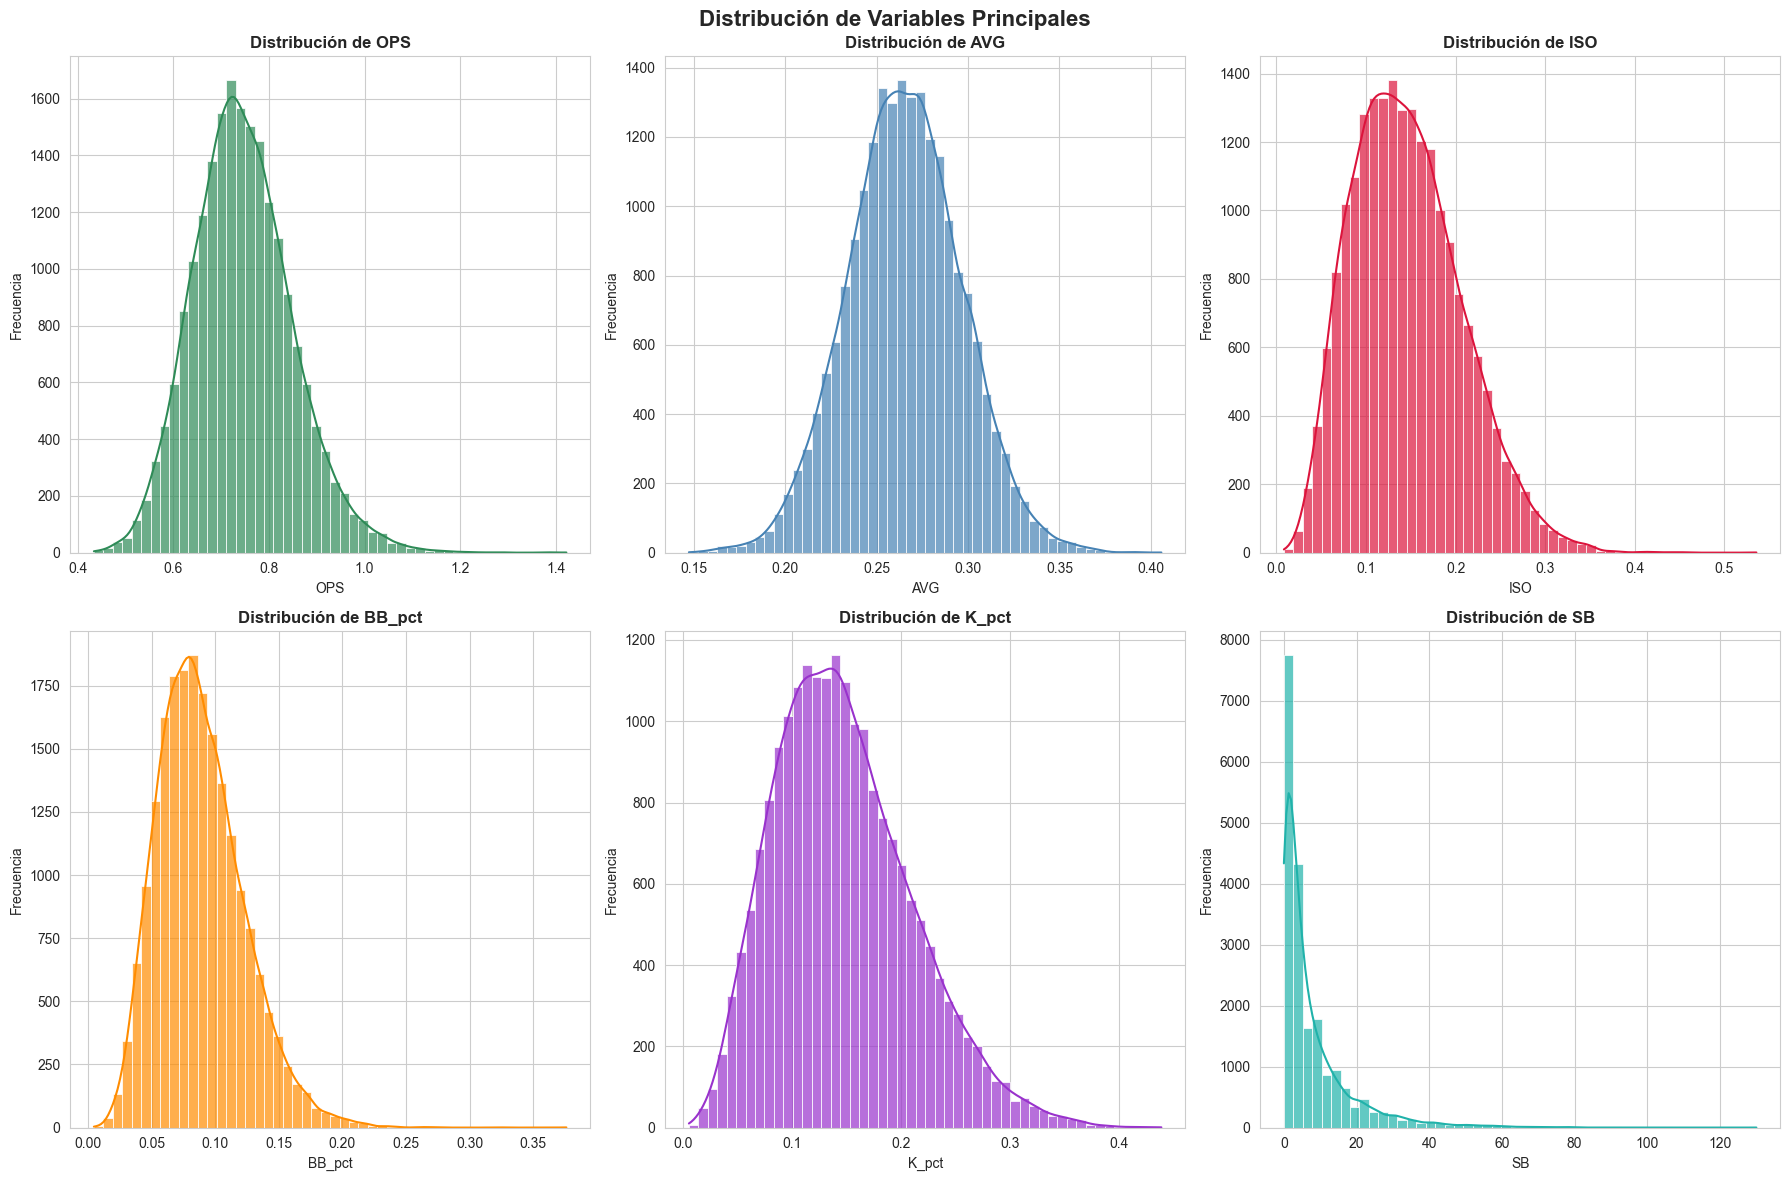

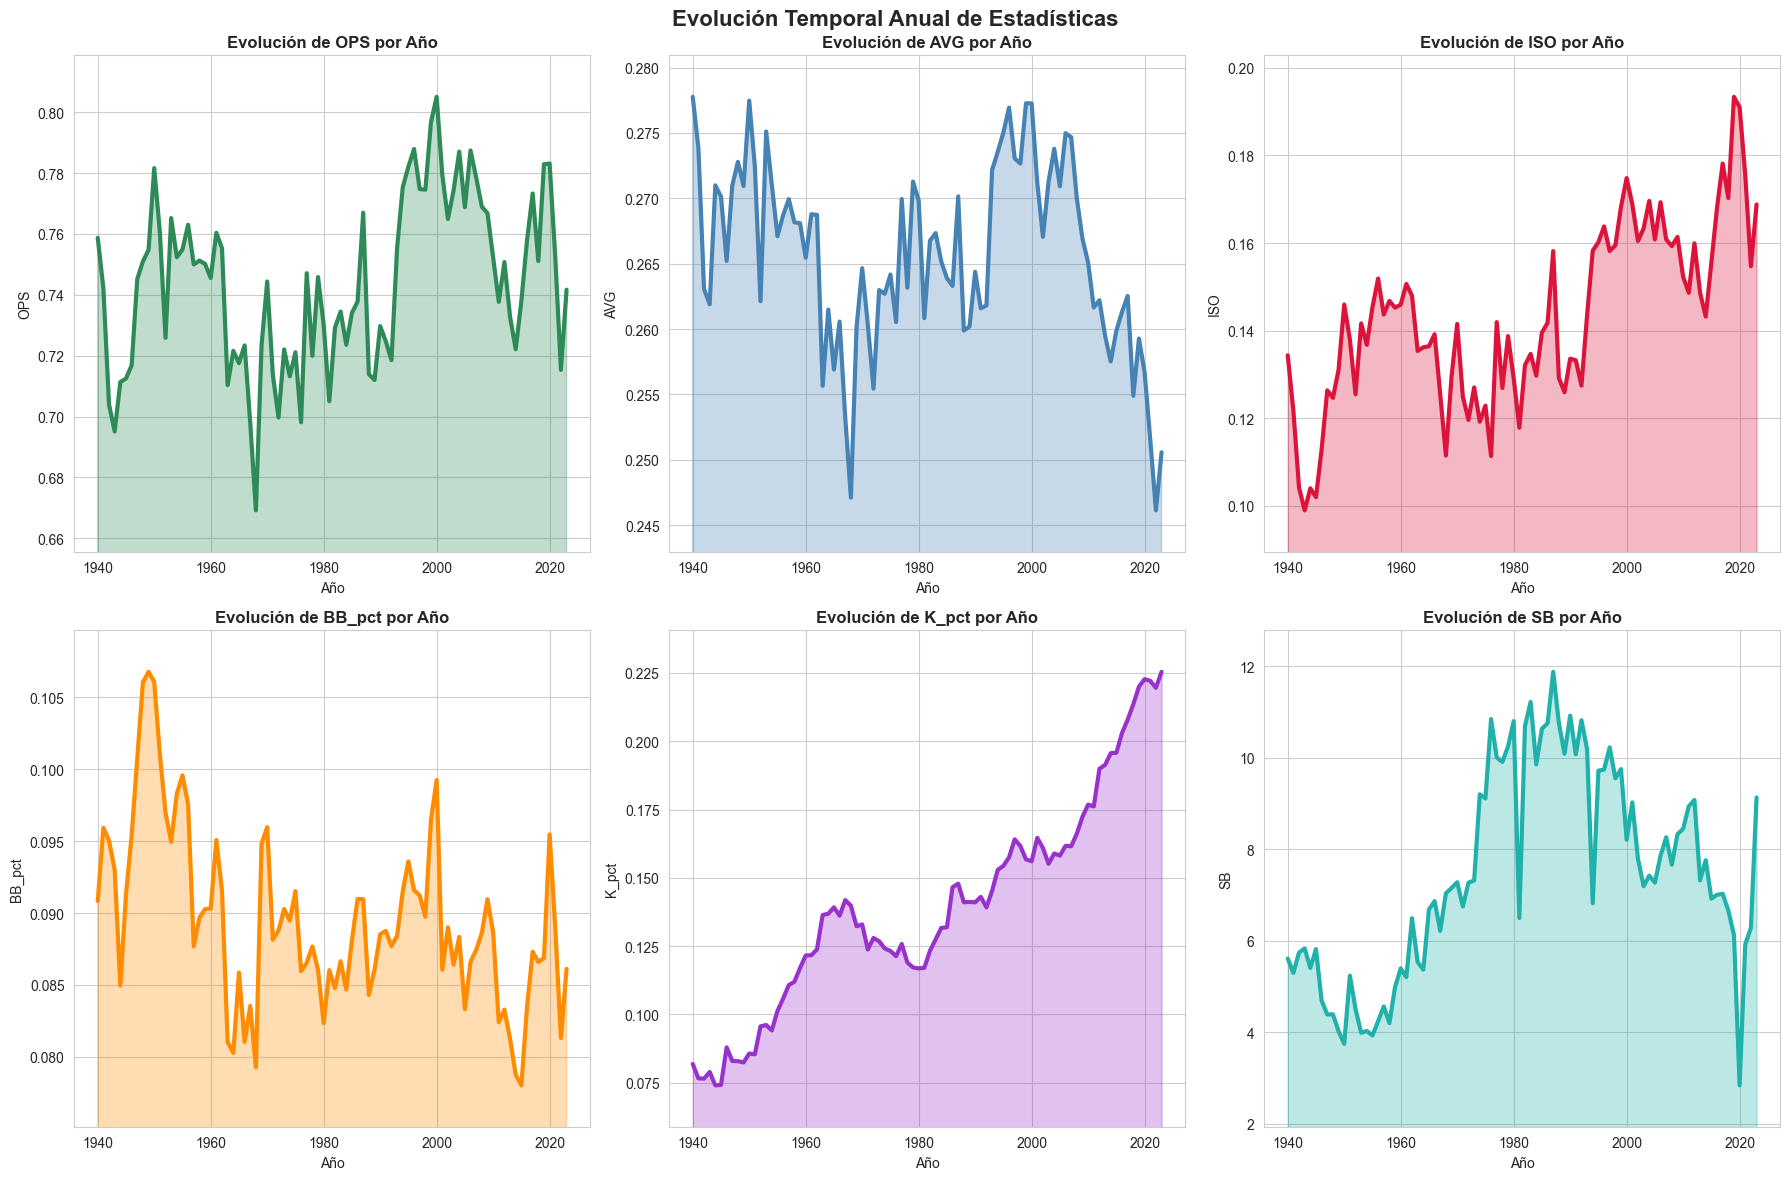

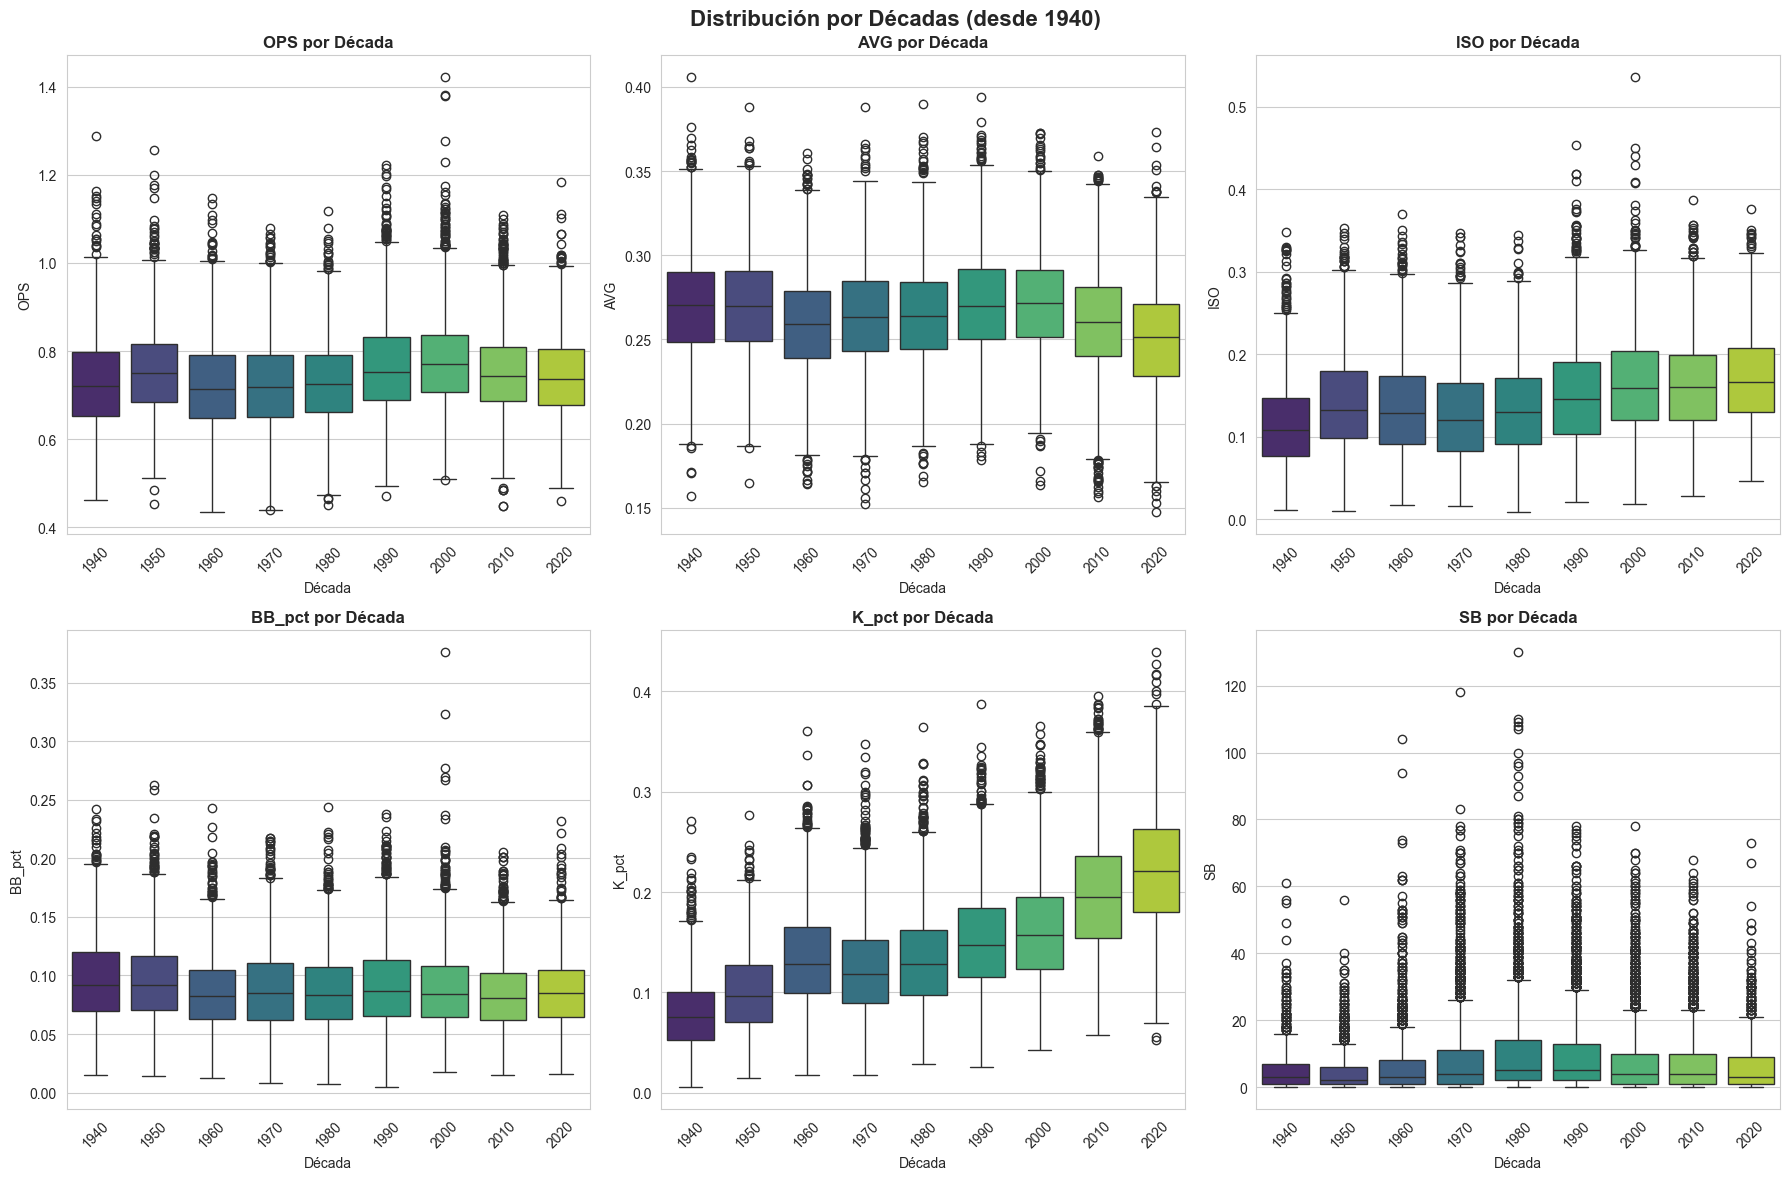

Estadísticas por Era (desde 1940):
          OPS           AVG           ISO        BB_pct         K_pct         \
         mean    std   mean    std   mean    std   mean    std   mean    std   
decade                                                                         
1940    0.729  0.107  0.270  0.032  0.116  0.054  0.096  0.036  0.080  0.037   
1950    0.755  0.106  0.270  0.031  0.142  0.059  0.096  0.035  0.100  0.042   
1960    0.722  0.107  0.260  0.030  0.135  0.060  0.086  0.032  0.133  0.048   
1970    0.723  0.103  0.264  0.031  0.128  0.057  0.089  0.035  0.124  0.047   
1980    0.729  0.096  0.265  0.030  0.134  0.055  0.086  0.033  0.132  0.049   
1990    0.763  0.108  0.271  0.031  0.151  0.063  0.091  0.035  0.152  0.052   
2000    0.778  0.104  0.272  0.029  0.165  0.061  0.089  0.034  0.162  0.053   
2010    0.750  0.096  0.260  0.031  0.162  0.057  0.084  0.030  0.197  0.060   
2020    0.745  0.099  0.251  0.032  0.171  0.058  0.087  0.031  0.222  0.061   

    

In [7]:
# =============================================================================
# SECCIÓN 5.1: ANÁLISIS DESCRIPTIVO Y TEMPORAL
# =============================================================================

# Carga del dataset con características engineered para análisis exploratorio
df = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_features.csv")

# Configuración del estilo visual para gráficos consistentes
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Análisis de distribuciones univariadas de métricas clave
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribución de Variables Principales', fontsize=16, fontweight='bold')

# Selección de variables representativas del rendimiento ofensivo
key_vars = ['OPS', 'AVG', 'ISO', 'BB_pct', 'K_pct', 'SB']
colors = ['#2E8B57', '#4682B4', '#DC143C', '#FF8C00', '#9932CC', '#20B2AA']

# Generación de histogramas con densidad estimada por kernel
for i, var in enumerate(key_vars):
    row, col = i // 3, i % 3
    sns.histplot(data=df, x=var, bins=50, alpha=0.7, color=colors[i], 
                kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribución de {var}', fontweight='bold')
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Agregación de estadísticas anuales para análisis de series temporales
yearly_stats = df.groupby('yearID').agg({
    'OPS': 'mean',
    'AVG': 'mean', 
    'ISO': 'mean',
    'BB_pct': 'mean',
    'K_pct': 'mean',
    'SB': 'mean'
}).reset_index()

# Visualización de tendencias temporales con series de tiempo
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Evolución Temporal Anual de Estadísticas', fontsize=16, fontweight='bold')

for i, var in enumerate(key_vars):
    row, col = i // 3, i % 3
    
    # Cálculo dinámico de límites del eje Y para optimizar visualización
    min_val = yearly_stats[var].min()
    max_val = yearly_stats[var].max()
    margin = (max_val - min_val) * 0.1
    
    # Línea temporal con área sombreada para destacar tendencias
    sns.lineplot(data=yearly_stats, x='yearID', y=var, linewidth=3, 
                color=colors[i], ax=axes[row, col])
    axes[row, col].fill_between(yearly_stats['yearID'], yearly_stats[var], 
                               alpha=0.3, color=colors[i])
    axes[row, col].set_title(f'Evolución de {var} por Año', fontweight='bold')
    axes[row, col].set_xlabel('Año')
    axes[row, col].set_ylabel(var)
    axes[row, col].set_ylim(min_val - margin, max_val + margin)

plt.tight_layout()
plt.show()

# Creación de agrupación por décadas para análisis de eras del baseball
df_since_1940 = df[df['yearID'] >= 1940].copy()
df_since_1940['decade'] = (df_since_1940['yearID'] // 10) * 10
decades = sorted(df_since_1940['decade'].unique())

# Análisis comparativo por décadas usando boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribución por Décadas (desde 1940)', fontsize=16, fontweight='bold')

for i, var in enumerate(key_vars):
    row, col = i // 3, i % 3
    # Boxplot para mostrar distribución, mediana y outliers por década
    sns.boxplot(data=df_since_1940, x='decade', y=var, 
               palette='viridis', ax=axes[row, col])
    axes[row, col].set_title(f'{var} por Década', fontweight='bold')
    axes[row, col].set_xlabel('Década')
    axes[row, col].set_ylabel(var)
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Reporte estadístico detallado por era con medidas de tendencia central y dispersión
print("Estadísticas por Era (desde 1940):")
print("=" * 50)
era_stats = df_since_1940.groupby('decade')[key_vars].agg(['mean', 'std']).round(3)
print(era_stats)

## **Resultados del Análisis Descriptivo y Temporal**

El análisis exploratorio revela patrones significativos en las distribuciones de variables y la evolución temporal del baseball desde 1940. Los gráficos muestran distribuciones normales para la mayoría de métricas, con la notable excepción de stolen bases que presenta una distribución marcadamente sesgada hacia la derecha.

## **Análisis de Distribuciones**

Las variables OPS, AVG, ISO, BB_pct y K_pct muestran distribuciones aproximadamente normales centradas en valores característicos del baseball moderno. OPS se centra alrededor de 0.75, AVG cerca de 0.265, e ISO alrededor de 0.15. La distribución de SB es claramente no normal, con la mayoría de jugadores registrando pocas bases robadas y una cola larga hacia valores altos, reflejando la especialización de esta habilidad.

## **Evolución Temporal del Juego**

El análisis temporal identifica tres eras distintas en el baseball moderno:

**Era de Transición (1940-1960)**: Se observa el final del dead-ball era con incrementos graduales en poder (ISO) y disciplina (BB_pct). Los strikeouts eran relativamente bajos y estables.

**Era de Expansión y Velocidad (1970-1990)**: Coincidiendo con la expansión de la liga, se registra el pico histórico de stolen bases (10.3 promedio en los 1980s) y el establecimiento de patrones modernos de disciplina al plato.

**Era Moderna (2000-2023)**: Caracterizada por el incremento dramático en strikeouts (de 10% en 1940 a 22.2% en 2020s) y poder (ISO alcanza máximos históricos de 0.171 en 2020s), asi como la reduccion hasta la casi desaparición de las SB, reflejando el enfoque analítico moderno que prioriza poder sobre contacto, asi como minimización del riesgo asociado al robo de bases.

## **Implicaciones para el Modelamiento**

Los cambios temporales identificados sugieren que las proyecciones deben considerar el contexto histórico. La tendencia ascendente en strikeouts y poder indica que los modelos entrenados en datos históricos pueden subestimar estos aspectos para jugadores actuales. La variabilidad decreciente en AVG pero creciente en power variables refleja la mayor especialización y optimización táctica del juego moderno.

Estas tendencias validan la necesidad de features temporales en nuestro modelo y sugieren que el clustering de jugadores debe considerar la era en que jugaron para identificar perfiles comparables apropiados.

---
# 📈**SECCIÓN 5.2: CORRELACIONES, CLUSTERS Y AGING CURVES**
---
## **Objetivo**

El objetivo es analizar las relaciones entre variables para identificar patrones de correlación, validar la necesidad de clustering para caracterizar tipos de jugadores, y desarrollar aging curves que capturen cómo evoluciona el rendimiento con la edad. Esta sección proporciona la base analítica para las decisiones de clustering y modelamiento posterior.

## **Metodología**

Implementaremos tres análisis complementarios:

**Análisis de Correlaciones**: Calcularemos la matriz de correlación entre variables numéricas clave, identificando relaciones lineales que informen sobre la estructura de los datos y potenciales problemas de multicolinealidad.

**Justificación para Clustering**: Crearemos scatter plots que demuestren la existencia de grupos naturales de jugadores basados en características como poder vs velocidad, disciplina vs strikeouts, y físico vs rendimiento. Estos gráficos validarán la hipótesis de que existen tipos distintos de jugadores.

**Aging Curves Metodología Delta**: Desarrollaremos aging curves utilizando el método delta, que analiza cambios año a año en jugadores individuales para evitar el sesgo de supervivencia. 

## **Variables Analizadas**

| Métrica | Descripción |
|---------|-------------|
| OPS | On-base Plus Slugging – Métrica principal objetivo |
| AVG | Promedio de bateo |
| ISO | Poder aislado (capacidad de extra-base) |
| BB_pct | % de boletos sobre PA |
| K_pct | % de ponches sobre PA |
| SB | Bases robadas |
| BMI | Body Mass Index |

El análisis se concentrará en métricas que capturen las dimensiones fundamentales del rendimiento: OPS como medida global, ISO para poder, BB_pct y K_pct para disciplina y contacto, SB para velocidad, y variables físicas como BMI y edad. Estas variables representan los ejes principales sobre los cuales se pueden distinguir tipos de jugadores.

## **Importancia de las Aging Curves**

Las aging curves son fundamentales para nuestro sistema de proyección porque el rendimiento en baseball sigue patrones predecibles con la edad. Comprender cuándo los jugadores alcanzan su peak performance y cómo declinan posteriormente permite hacer proyecciones más precisas. El método delta utilizado evita sesgos comunes en análisis transversales donde jugadores menos talentosos abandonan el deporte más temprano.

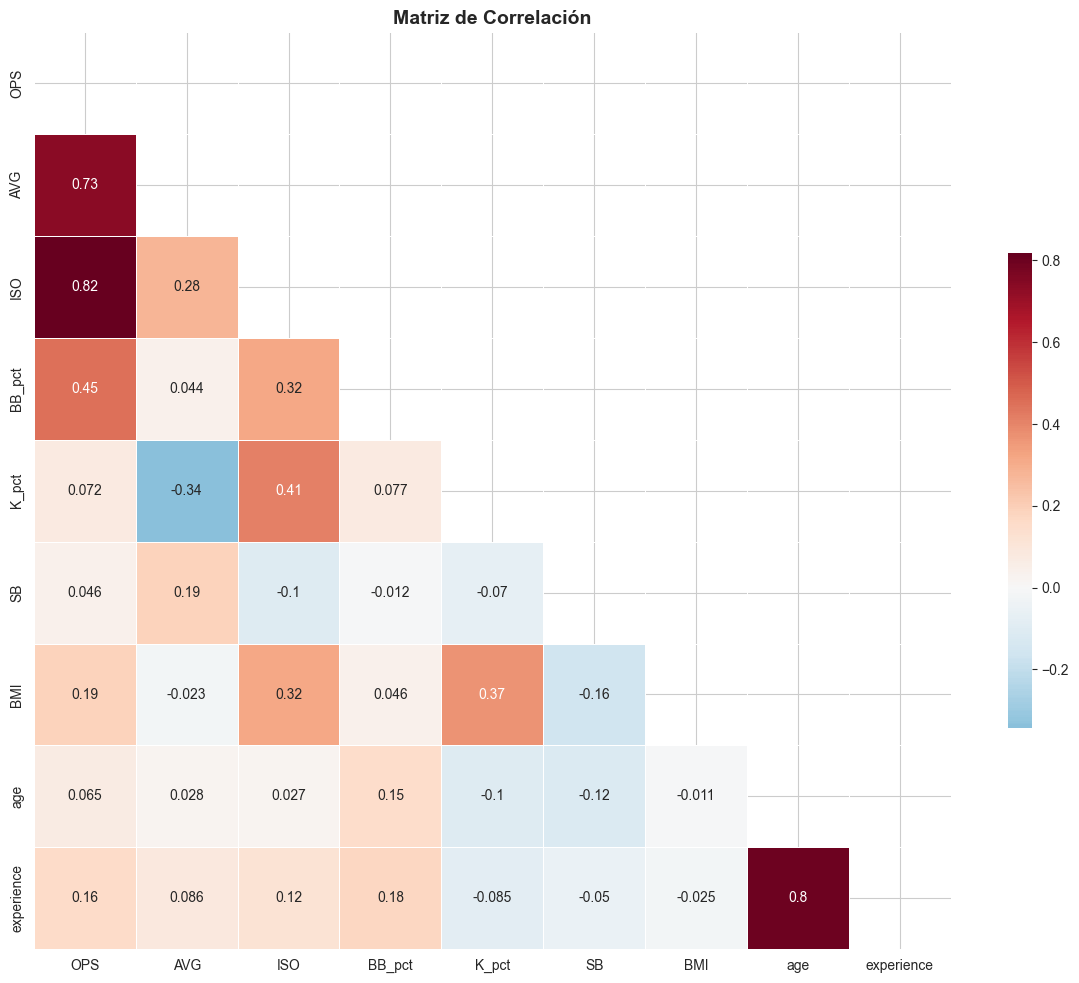

Correlaciones con OPS:
ISO: 0.818
AVG: 0.734
BB_pct: 0.446
BMI: 0.191
experience: 0.156
K_pct: 0.072
age: 0.065
SB: 0.046


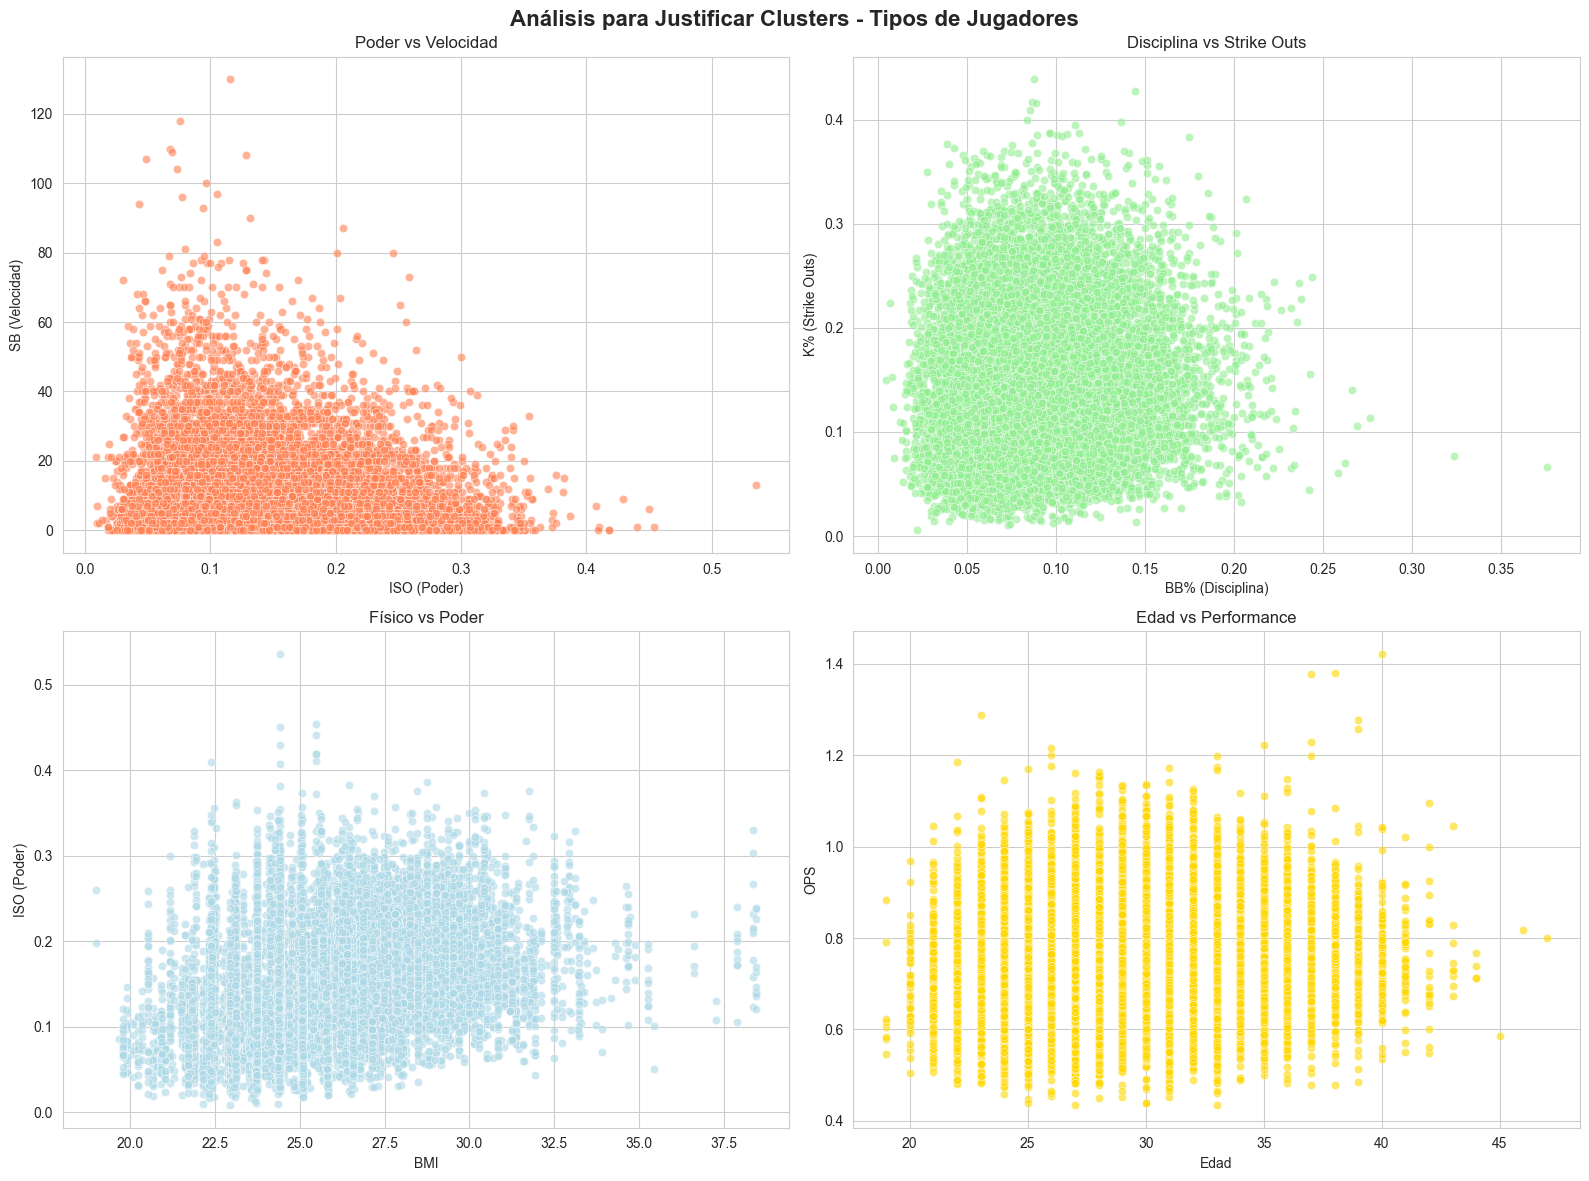

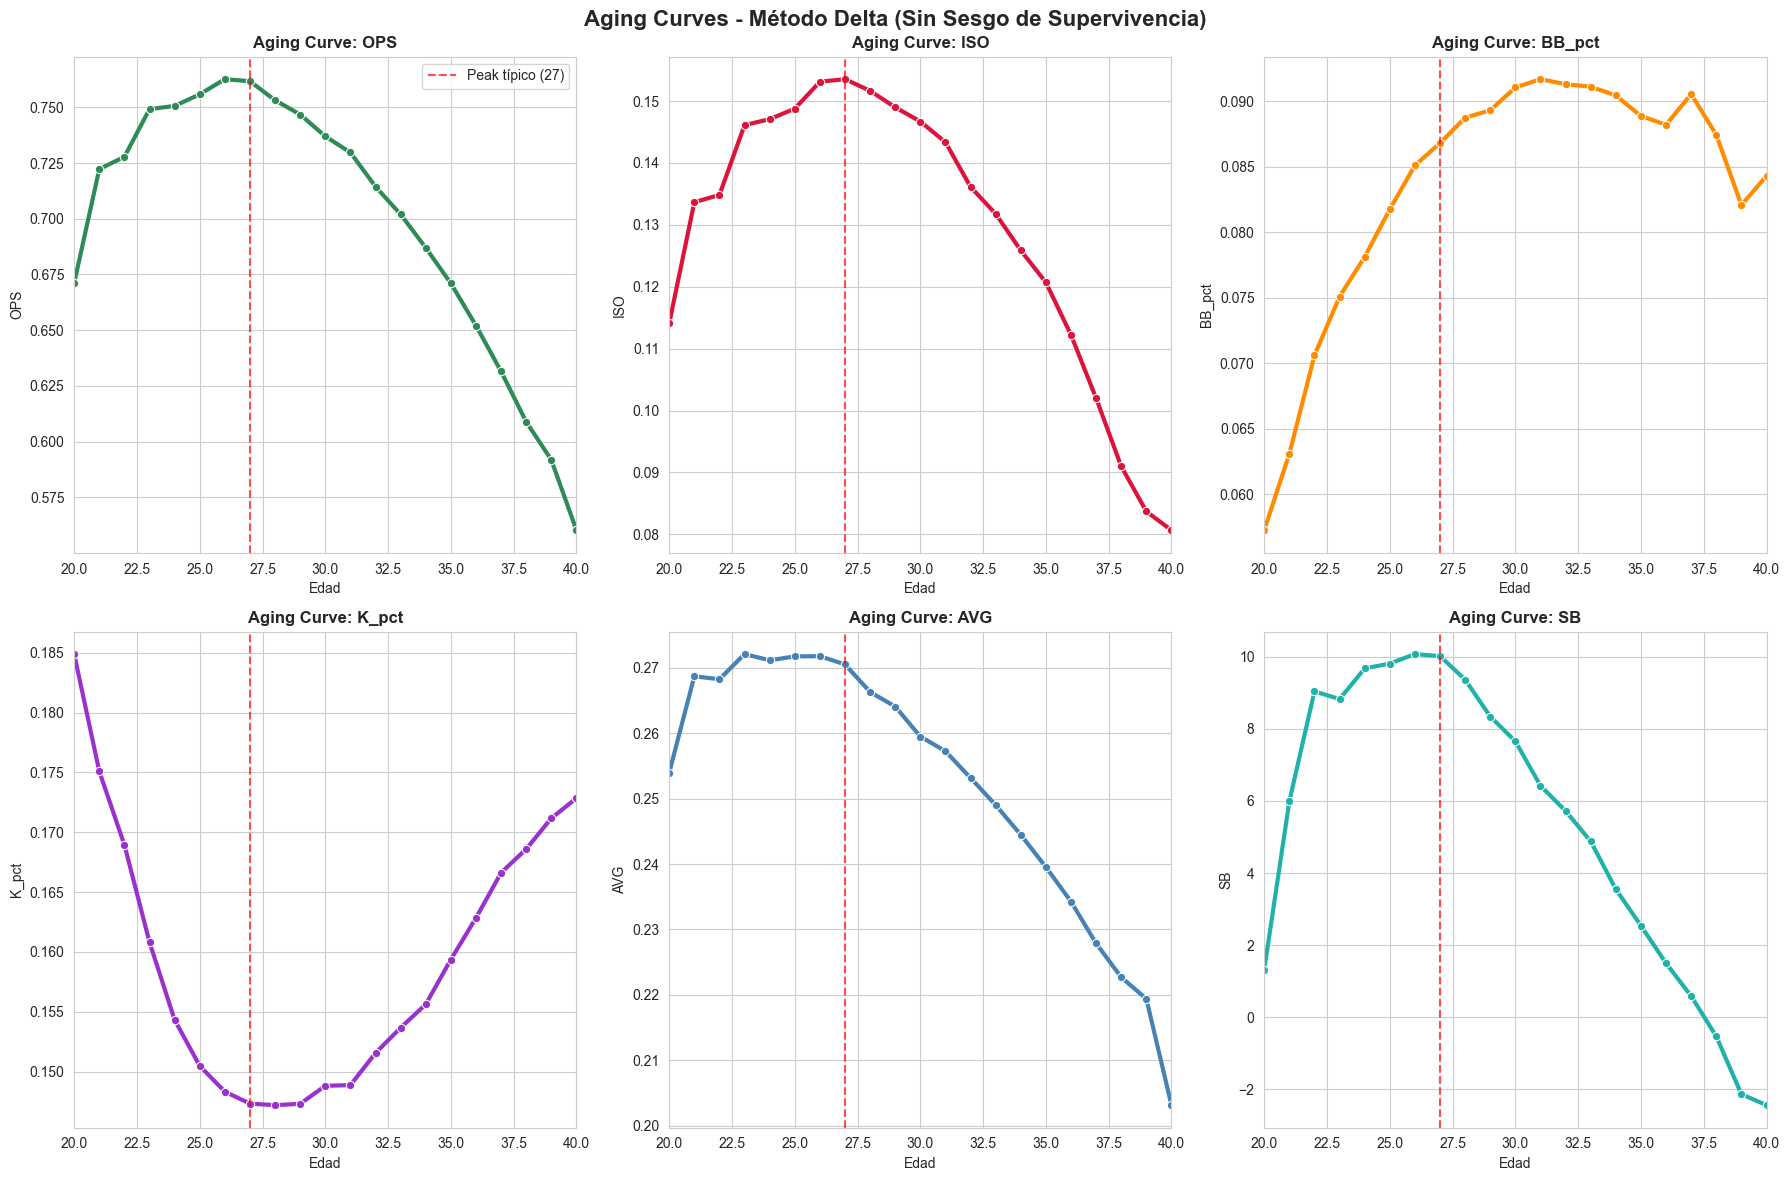


Edades de Peak Performance (Método Delta Correcto):
OPS: 26 años (valor: 0.763)
ISO: 27 años (valor: 0.154)
BB_pct: 31 años (valor: 0.092)
K_pct: 20 años (valor: 0.185)
AVG: 23 años (valor: 0.272)
SB: 26 años (valor: 10.072)


In [8]:
# =============================================================================
# SECCIÓN 5.2: CORRELACIONES, CLUSTERS Y AGING CURVES
# =============================================================================

# Selección de variables numéricas relevantes para análisis de correlación
numeric_cols = ['OPS', 'AVG', 'ISO', 'BB_pct', 'K_pct', 'SB', 'BMI', 'age', 'experience']
corr_matrix = df[numeric_cols].corr()

# Visualización de matriz de correlación con máscara triangular para evitar redundancia
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .5})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis específico de correlaciones con OPS como variable objetivo principal
ops_correlations = corr_matrix['OPS'].sort_values(ascending=False)
print("Correlaciones con OPS:")
print("=" * 30)
for var, corr in ops_correlations.items():
    if var != 'OPS':
        print(f"{var}: {corr:.3f}")

# Análisis bivariado para justificar la existencia de arquetipos de jugadores
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis para Justificar Clusters - Tipos de Jugadores', fontsize=16, fontweight='bold')

# Scatter plot poder vs velocidad (trade-off típico en baseball)
sns.scatterplot(data=df, x='ISO', y='SB', alpha=0.6, color='coral', ax=axes[0,0])
axes[0,0].set_xlabel('ISO (Poder)')
axes[0,0].set_ylabel('SB (Velocidad)')
axes[0,0].set_title('Poder vs Velocidad')

# Disciplina vs strikeouts (enfoque ofensivo)
sns.scatterplot(data=df, x='BB_pct', y='K_pct', alpha=0.6, color='lightgreen', ax=axes[0,1])
axes[0,1].set_xlabel('BB% (Disciplina)')
axes[0,1].set_ylabel('K% (Strike Outs)')
axes[0,1].set_title('Disciplina vs Strike Outs')

# Relación físico-rendimiento
sns.scatterplot(data=df, x='BMI', y='ISO', alpha=0.6, color='lightblue', ax=axes[1,0])
axes[1,0].set_xlabel('BMI')
axes[1,0].set_ylabel('ISO (Poder)')
axes[1,0].set_title('Físico vs Poder')

# Curva edad-rendimiento
sns.scatterplot(data=df, x='age', y='OPS', alpha=0.6, color='gold', ax=axes[1,1])
axes[1,1].set_xlabel('Edad')
axes[1,1].set_ylabel('OPS')
axes[1,1].set_title('Edad vs Performance')

plt.tight_layout()
plt.show()

# Filtrado de datos para análisis de aging curves con criterios de calidad
aging_data = df[(df['age'] >= 20) & (df['age'] <= 40) & (df['PA'] >= 350)].copy()

# Implementación del método delta para calcular cambios año a año sin sesgo de supervivencia
player_changes = []
aging_vars = ['OPS', 'ISO', 'BB_pct', 'K_pct', 'AVG', 'SB']

for player_id in aging_data['playerID'].unique():
    player_data = aging_data[aging_data['playerID'] == player_id].sort_values('yearID')
    
    # Cálculo de cambios consecutivos para cada jugador
    for i in range(len(player_data) - 1):
        if player_data.iloc[i+1]['yearID'] - player_data.iloc[i]['yearID'] == 1:
            age = player_data.iloc[i]['age']
            
            changes = {'age': int(age)}
            for var in aging_vars:
                changes[f'{var}_change'] = (player_data.iloc[i+1][var] - player_data.iloc[i][var])
            
            player_changes.append(changes)

changes_df = pd.DataFrame(player_changes)

# Agregación de cambios promedio por edad
age_changes = changes_df.groupby('age').agg({
    f'{var}_change': 'mean' for var in aging_vars
}).reset_index()

# Construcción de aging curves usando edad 27 como baseline (peak típico)
base_age = 27
base_stats = aging_data[aging_data['age'] == base_age].agg({var: 'mean' for var in aging_vars})

aging_curves = pd.DataFrame({'age': range(20, 41)})
for var in aging_vars:
    aging_curves[var] = base_stats[var]

# Aplicación acumulativa de cambios desde el baseline
for idx, row in aging_curves.iterrows():
    age = int(row['age'])
    if age < base_age:
        # Resta cambios acumulados para edades menores al baseline
        for a in range(age, base_age):
            if a in age_changes['age'].values:
                change_row = age_changes[age_changes['age'] == a]
                for var in aging_vars:
                    aging_curves.loc[idx, var] -= change_row[f'{var}_change'].values[0]
    elif age > base_age:
        # Suma cambios acumulados para edades mayores al baseline
        for a in range(base_age, age):
            if a in age_changes['age'].values:
                change_row = age_changes[age_changes['age'] == a]
                for var in aging_vars:
                    aging_curves.loc[idx, var] += change_row[f'{var}_change'].values[0]

# Visualización de aging curves corregidas por sesgo de supervivencia
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Aging Curves - Método Delta (Sin Sesgo de Supervivencia)', fontsize=16, fontweight='bold')

colors = ['#2E8B57', '#DC143C', '#FF8C00', '#9932CC', '#4682B4', '#20B2AA']

for i, var in enumerate(aging_vars):
    row, col = i // 3, i % 3
    valid_ages = aging_curves['age'].between(20, 40)
    
    sns.lineplot(data=aging_curves[valid_ages], x='age', y=var, 
                linewidth=3, marker='o', markersize=6, color=colors[i], ax=axes[row, col])
    axes[row, col].axvline(x=27, color='red', linestyle='--', alpha=0.7, label='Peak típico (27)')
    axes[row, col].set_xlabel('Edad')
    axes[row, col].set_ylabel(var)
    axes[row, col].set_title(f'Aging Curve: {var}', fontweight='bold')
    axes[row, col].set_xlim(20, 40)
    if i == 0:
        axes[row, col].legend()

plt.tight_layout()
plt.show()

# Identificación de edades de peak performance por métrica
print("\nEdades de Peak Performance (Método Delta Correcto):")
print("=" * 60)
for var in aging_vars:
    peak_age = aging_curves.loc[aging_curves[var].idxmax(), 'age']
    peak_value = aging_curves[var].max()
    print(f"{var}: {peak_age} años (valor: {peak_value:.3f})")

## **Resultados del Análisis de Correlaciones, Clusters y Aging Curves**

El análisis revela patrones fundamentales en las relaciones entre variables y confirma la validez de la aproximación de clustering para caracterizar tipos de jugadores. Las aging curves desarrolladas proporcionan datos críticos sobre la evolución del rendimiento con la edad.

## **Análisis de Correlaciones**

La matriz de correlación confirma que ISO (0.818) y AVG (0.734) son los componentes más importantes de OPS, como era esperado por definición. La correlación moderada de BB_pct (0.446) indica que la disciplina al plato contribuye significativamente al OPS pero no es determinante. Notablemente, K_pct muestra correlación débil (0.072) con OPS, sugiriendo que los strikeouts no necesariamente limitan la productividad ofensiva en el baseball moderno.

Las correlaciones bajas entre variables físicas (BMI, edad) y rendimiento indican que el talento trasciende las características físicas básicas, validando la necesidad de análisis más sofisticados para caracterizar jugadores.

## **Justificación para Clustering**

Los scatter plots demuestran claramente la existencia de grupos naturales de jugadores. El gráfico poder vs velocidad muestra una relación inversa donde jugadores se especializan en una dimensión u otra. La dispersión en disciplina vs strikeouts revela diferentes approaches al plato, desde contact hitters hasta power hitters con alta tolerancia a strikeouts.

El gráfico físico vs poder muestra que no existe una relación lineal simple entre BMI y ISO, indicando que tipos corporales diversos pueden generar poder. La relación edad vs performance confirma la existencia de aging curves que justifican la inclusión de variables temporales en el modelamiento.

## **Aging Curves**

Las aging curves revelan patrones específicos por métrica que son fundamentales para las proyecciones:

**Peak Performance**: La mayoría de métricas alcanzan su peak entre 26-27 años (OPS, ISO, SB), con BB_pct mejorando hasta los 31 años, reflejando que la disciplina se desarrolla con experiencia. K_pct es óptimo a los 20 años, confirmando que el contacto es una habilidad temprana.

**Patrones de Declive**: OPS e ISO muestran declives pronunciados después de los 30 años. Las SB declinan dramáticamente después de los 26 años, confirmando que la velocidad es la primera habilidad en deteriorarse.

**Implicaciones**: Estos patrones indican que proyecciones para jugadores jóvenes deben considerar mejoras potenciales, mientras que para veteranos el foco debe estar en cuantificar la tasa de declive. La variabilidad por métrica sugiere que diferentes tipos de jugadores envejecen de manera distinta, validando la aproximación de clustering.

---
# 🎯**SECCIÓN 5.3: PRE-ANÁLISIS DE CLUSTERS - TIPOS DE JUGADORES**
---
## **Objetivo**

El objetivo es realizar un análisis cualitativo preliminar para identificar arquetipos de jugadores en el baseball basándose en sus características. Esta sección establece las bases conceptuales para el clustering formal al definir los perfiles distintivos que existen naturalmente en el deporte.

## **Metodología**

Filtraremos jugadores en sus años peak (25-35 años) con al menos 3 temporadas y 1,500 PA totales para asegurar muestras representativas. Calcularemos estadísticas ponderadas por PA para obtener métricas promedio de peak performance que no estén sesgadas por temporadas parciales.

Definiremos 8 arquetipos de jugadores basados en combinaciones de métricas clave: poder (ISO), disciplina (BB_pct), contacto (K_pct), velocidad (SB) y rendimiento global (OPS, AVG). Cada arquetipo representa una filosofía de juego distinta con criterios específicos que reflejan especializaciones reales en el baseball.

## **Arquetipos Definidos**

Los 8 tipos incluyen: Elite (combinación excepcional de todas las habilidades), Power Sluggers (poder puro), Todo o Nada (alto riesgo/alta recompensa), TTO/Three True Outcomes (BB/K/HR), Contact Masters (contacto puro), Speedsters (velocidad), Slap Hitters (singles y disciplina), y Replacements (por debajo del promedio).

## **Criterios de Filtrado**

La selección de años peak (25-35) se basa en las aging curves desarrolladas previamente, que muestran que la mayoría de jugadores alcanzan su máximo rendimiento en este rango. El umbral de 1,500 PA garantiza que analizamos jugadores con carreras sustantivas, no casos esporádicos.

## **Importancia**

Este pre-análisis valida conceptualmente la existencia de tipos distintos de jugadores antes de aplicar algoritmos de clustering. Identificar estos arquetipos manualmente permite evaluar si el clustering formal captura las diferencias reales que observan expertos en baseball, proporcionando una validación cualitativa del approach cuantitativo posterior.

La caracterización de tipos de jugadores es fundamental para nuestro sistema de proyección porque jugadores con perfiles similares tienden a seguir trayectorias de carrera comparables, permitiendo proyecciones más precisas basadas en precedentes históricos.

In [9]:
# =============================================================================
# SECCIÓN 5.3: PRE-CLUSTERS - ANÁLISIS DE TIPOS DE JUGADORES
# =============================================================================

# Filtrado de datos para años peak de rendimiento (25-35 años)
peak_data = df[(df['age'] >= 25) & (df['age'] <= 35)].copy()

# Agregación de estadísticas peak por jugador con ponderación por PA
player_peak_stats = []
for player_id in peak_data['playerID'].unique():
    player_data = peak_data[peak_data['playerID'] == player_id]
    
    # Criterios de calidad: mínimo 3 temporadas y 1500 PA totales en peak
    if len(player_data) >= 3 and player_data['PA'].sum() >= 1500:
        total_pa = player_data['PA'].sum()
        
        # Estructura base del perfil del jugador
        weighted_stats = {
            'playerID': player_id,
            'name': player_data['name'].iloc[0],
            'peak_seasons': len(player_data),
            'total_peak_PA': total_pa,
            'first_peak_year': player_data['yearID'].min(),
            'last_peak_year': player_data['yearID'].max()
        }
        
        # Cálculo de estadísticas ponderadas por PA para representar verdadero rendimiento peak
        for stat in ['AVG', 'ISO', 'OPS', 'K_pct', 'BB_pct', 'SB']:
            if stat == 'SB':
                # SB se pondera diferente por ser conteo absoluto
                weighted_stats[stat] = (player_data[stat] * player_data['PA']).sum() / total_pa
            else:
                weighted_stats[stat] = (player_data[stat] * player_data['PA']).sum() / total_pa
        
        player_peak_stats.append(weighted_stats)

peak_df = pd.DataFrame(player_peak_stats)

# Definición de arquetipos de jugadores basados en literatura de baseball analytics
groups = {
    'ELITE': {
        'filter': (peak_df['K_pct'] < 0.15) & (peak_df['BB_pct'] > 0.15) & 
                 (peak_df['ISO'] > 0.200) & (peak_df['OPS'] > 0.900),
        'description': 'Los mejores: Bajo K%, Alto BB%, Poder, OPS elite'
    },
    'POWER SLUGGERS': {
        'filter': (peak_df['ISO'] > 0.250) & (peak_df['OPS'] > 0.850),
        'description': 'Poder puro: ISO alto, OPS alto'
    },
    'TODO O NADA': {
        'filter': (peak_df['K_pct'] > 0.25) & (peak_df['ISO'] > 0.200) & (peak_df['BB_pct'] < 0.08),
        'description': 'Alto riesgo: Muchos K%, poder, pocos BB%'
    },
    'TTO (Three True Outcomes)': {
        'filter': (peak_df['K_pct'] > 0.20) & (peak_df['BB_pct'] > 0.12) & (peak_df['ISO'] > 0.180),
        'description': 'BB/K/HR: Altos en las tres categorías'
    },
    'CONTACT MASTERS': {
        'filter': (peak_df['K_pct'] < 0.12) & (peak_df['AVG'] > 0.300) & (peak_df['ISO'] < 0.150),
        'description': 'Contacto puro: Bajo K%, alto AVG, poco poder'
    },
    'SPEEDSTERS': {
        'filter': (peak_df['SB'] > 15) & (peak_df['K_pct'] < 0.20) & (peak_df['AVG'] > 0.280),
        'description': 'Velocidad: Muchos SB, buen contacto'
    },
    'SLAP HITTERS': {
        'filter': (peak_df['AVG'] > 0.280) & (peak_df['ISO'] < 0.120) & (peak_df['BB_pct'] > 0.10),
        'description': 'Singles: Alto AVG, poco poder, disciplina'
    },
    'REPLACEMENTS': {
        'filter': (peak_df['OPS'] < 0.700) & (peak_df['K_pct'] > 0.20) & (peak_df['ISO'] < 0.120),
        'description': 'Por debajo del promedio: Bajo OPS, muchos K%'
    }
}

print("ANÁLISIS DE TIPOS DE JUGADORES - PEAK YEARS (25-35 años)")
print("=" * 80)

# Análisis detallado por arquetipo con ejemplos representativos
for group_name, group_info in groups.items():
    group_players = peak_df[group_info['filter']].copy()
    
    if len(group_players) > 0:
        # Selección de top 3 jugadores por volumen de PA para representar mejor el arquetipo
        group_players = group_players.sort_values('total_peak_PA', ascending=False).head(3)
        
        print(f"\n{group_name.upper()}")
        print(f"Descripción: {group_info['description']}")
        print(f"Total jugadores en grupo: {len(peak_df[group_info['filter']])}")
        print("-" * 60)
        
        # Columnas relevantes para caracterizar cada arquetipo
        display_cols = ['name', 'peak_seasons', 'total_peak_PA', 'AVG', 'ISO', 'OPS', 'K_pct', 'BB_pct', 'SB']
        
        # Presentación detallada de jugadores representativos
        for idx, (_, player) in enumerate(group_players[display_cols].iterrows(), 1):
            print(f"{idx}. {player['name']} ({player['peak_seasons']} temporadas, {player['total_peak_PA']:.0f} PA)")
            print(f"   AVG: {player['AVG']:.3f} | ISO: {player['ISO']:.3f} | OPS: {player['OPS']:.3f}")
            print(f"   K%: {player['K_pct']*100:.1f}% | BB%: {player['BB_pct']*100:.1f}% | SB: {player['SB']:.1f}")
            print()
    else:
        print(f"\n{group_name.upper()}")
        print(f"Descripción: {group_info['description']}")
        print("No hay jugadores que cumplan estos criterios.")
        print("-" * 60)

# Resumen cuantitativo del análisis
print(f"\nTOTAL DE JUGADORES ANALIZADOS: {len(peak_df)}")
print(f"Criterios: 25-35 años, mínimo 3 temporadas, mínimo 1500 PA en peak")

ANÁLISIS DE TIPOS DE JUGADORES - PEAK YEARS (25-35 años)

ELITE
Descripción: Los mejores: Bajo K%, Alto BB%, Poder, OPS elite
Total jugadores en grupo: 8
------------------------------------------------------------
1. Barry Bonds (11 temporadas, 6825 PA)
   AVG: 0.297 | ISO: 0.287 | OPS: 1.010
   K%: 12.3% | BB%: 18.2% | SB: 34.7

2. Frank Thomas (10 temporadas, 6437 PA)
   AVG: 0.308 | ISO: 0.269 | OPS: 1.002
   K%: 12.6% | BB%: 16.7% | SB: 2.5

3. Brian Giles (10 temporadas, 6225 PA)
   AVG: 0.293 | ISO: 0.230 | OPS: 0.931
   K%: 10.9% | BB%: 15.9% | SB: 9.8


POWER SLUGGERS
Descripción: Poder puro: ISO alto, OPS alto
Total jugadores en grupo: 47
------------------------------------------------------------
1. Alex Rodriguez (11 temporadas, 7363 PA)
   AVG: 0.301 | ISO: 0.279 | OPS: 0.976
   K%: 18.2% | BB%: 12.3% | SB: 16.9

2. Hank Aaron (11 temporadas, 7354 PA)
   AVG: 0.312 | ISO: 0.260 | OPS: 0.951
   K%: 10.6% | BB%: 9.8% | SB: 19.3

3. Willie Mays (11 temporadas, 7288 PA)
   AV

## **Resultados del Pre-Análisis de Tipos de Jugadores**

El análisis identificó 8 arquetipos distintos entre 1,835 jugadores que cumplieron los criterios de peak performance, confirmando la existencia de especializaciones naturales en el baseball profesional. La distribución de jugadores por tipo refleja la diversidad de approaches exitosos en el deporte.

## **Análisis de Arquetipos Identificados**

**Elite (8 jugadores)**: Representa el 0.4% de la muestra, confirmando que la combinación de todas las habilidades es excepcional. Barry Bonds ejemplifica este perfil con OPS superior a 1.000, bajo K% (12.3%) y versatilidad (poder + velocidad). Este grupo establece el benchmark de rendimiento máximo.

**Contact Masters (46 jugadores)** y **Speedsters (106 jugadores)**: Constituyen grupos sustanciales que priorizan habilidades específicas. Pete Rose y Wade Boggs demuestran que el contacto puro (K% < 8%, AVG > 0.300) puede generar value significativo. Lou Brock y Derek Jeter representan la velocidad como diferenciador primario.

**TTO y Power Sluggers (93 jugadores combinados)**: Reflejan la evolución hacia el baseball moderno donde poder y disciplina compensan menor contacto. Adam Dunn (29.1% K%, 15.6% BB%) y Alex Rodriguez ejemplifican strategies de maximización de value ofensivo.

**Todo o Nada (8 jugadores)**: El grupo más pequeño después de Elite, sugiriendo que el approach de alto K%/bajo BB% es menos sostenible para carreras largas. Representa el riesgo extremo del baseball moderno.

## **Implicaciones para Clustering**

Este análisis cualitativo establece expectativas para el clustering formal: deberíamos identificar entre 6-8 clusters que correspondan aproximadamente a estos arquetipos. La variabilidad dentro de cada tipo (ejemplo: diferentes niveles de velocidad entre Speedsters) sugiere que el clustering puede refinar estas categorías o identificar sub-tipos adicionales.

# 🧬**SECCIÓN 6: CLUSTERING**

## **Objetivo**

El objetivo en esta sección fue agrupar jugadores por estilo ofensivo. La idea es que si existe un "tipo" natural de jugador, probablemente sigan trayectorias similares.  

## **Metodología**

se aplicó K-means sobre 1,835 jugadores en sus años peak (25-35 años) con mínimo 3 temporadas y 1,500 PA totales, utilizando 7 variables ajustadas por era: ISO, BB_pct, K_pct, SB, BABIP, BMI y age. El ajuste por era calculó el promedio anual de cada métrica desde 1940,para luego crear variables normalizadas.  Por ejemplo, un 15% K_rate en 1980 era alto; en 2020 es promedio. Esta normalización permite comparar jugadores de diferentes épocas.  

**Selección de Variables**: Las variables seleccionadas capturan dimensiones fundamentales del rendimiento:  

- Rendimiento ofensivo: ISO (poder), BABIP (contacto en bolas en juego)  
- Disciplina: K_pct (ponches), BB_pct (boletos)  
- Velocidad: SB (bases robadas)  
- Condición física: BMI (índice de masa corporal)  
- Experiencia: age (edad)  

**Datos de Entrenamiento**: Nos enfocaremos en jugadores peak (25-35 años) con mínimo 3 temporadas y 1,500 PA totales. Esto asegura que los clusters se basen en rendimiento maduro y representativo, evitando sesgos de jugadores en desarrollo o decline pronunciado

**Optimización**: Evaluaremos entre 6-10 clusters usando Silhouette Score para balancear homogeneidad interna y separación entre grupos. El número óptimo debe alinearse aproximadamente con los 8 arquetipos identificados en el pre-análisis.

## **Ajuste Temporal**

El ajuste por era mediante normalización por división es crítico porque transforma valores absolutos en ratios relativos. Un jugador de los 1950s con 8% K_rate tendrá un ratio similar a un jugador actual con 20% K_rate si ambos están en la media de sus respectivas épocas.

## **Aplicación Global**

Una vez entrenado el modelo en datos peak, lo aplicaremos a todo el dataset asignando clusters de forma consistente por jugador. Para jugadores no-peak, utilizaremos sus mejores temporadas disponibles (criterios ajustados por PA según temporadas normales vs acortadas) para determinar su perfil representativo.

## **Importancia**

El clustering ajustado por era es fundamental para nuestro sistema porque permite identificar jugadores con trayectorias similares independientemente de cuándo jugaron. La normalización por división asegura que las comparaciones sean válidas entre épocas, elemento esencial para hacer proyecciones que consideren el contexto histórico apropiado

In [10]:
# =============================================================================
# SECCIÓN 6: CLUSTERING CON AJUSTE POR ERA
# =============================================================================

df = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_features.csv")

print(f"Dataset con features: {df.shape}")
print(f"NaN en dataset: {df.isnull().sum().sum()}")

# Crear features ajustadas por era en el dataset completo
peak_data = df[(df['age'] >= 25) & (df['age'] <= 35)].copy()

cluster_vars = ['ISO', 'BB_pct', 'K_pct', 'SB', 'BABIP', 'BMI', 'age']

# Calcular promedios anuales SOLO para stats que necesitan ajuste (no age)
stats_for_adjustment = ['ISO', 'BB_pct', 'K_pct', 'SB', 'BABIP', 'BMI']
yearly_means = peak_data.groupby('yearID')[stats_for_adjustment].mean()

# Crear features ajustadas por era en peak_data (NORMALIZACIÓN POR DIVISIÓN)
for col in stats_for_adjustment:
    peak_data[f'{col}_era_adjusted'] = peak_data[col] / peak_data['yearID'].map(yearly_means[col])

# Age no necesita ajuste
peak_data['age_era_adjusted'] = peak_data['age']

# Ahora agregamos por jugador usando las variables YA AJUSTADAS
player_peak_stats = []
for player_id in peak_data['playerID'].unique():
    player_data = peak_data[peak_data['playerID'] == player_id]
    
    if len(player_data) >= 3 and player_data['PA'].sum() >= 1500:
        total_pa = player_data['PA'].sum()
        
        weighted_stats = {'playerID': player_id, 'name': player_data['name'].iloc[0]}
        
        # Usar las variables ajustadas por era
        for stat in cluster_vars:
            stat_adjusted = f'{stat}_era_adjusted'
            weighted_stats[stat_adjusted] = (player_data[stat_adjusted] * player_data['PA']).sum() / total_pa
        
        player_peak_stats.append(weighted_stats)

peak_df = pd.DataFrame(player_peak_stats)

# Variables para clustering (ahora son las ajustadas por era)
cluster_vars_adjusted = [f'{var}_era_adjusted' for var in cluster_vars]
peak_cluster_data = peak_df[cluster_vars_adjusted]

print(f"Datos peak para clustering: {peak_cluster_data.shape}")
print(f"NaN en datos peak: {peak_cluster_data.isnull().sum().sum()}")

# Ahora sí aplicar StandardScaler
scaler = StandardScaler()
peak_data_scaled = scaler.fit_transform(peak_cluster_data)

min_clusters = 6
max_clusters = 10
silhouette_scores = {}

for k in range(min_clusters, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(peak_data_scaled)
    silhouette_avg = silhouette_score(peak_data_scaled, cluster_labels)
    silhouette_scores[k] = silhouette_avg

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
best_silhouette = silhouette_scores[optimal_k]

print(f"Número óptimo de clusters: {optimal_k}")
print(f"Mejor Silhouette Score: {best_silhouette:.4f}")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
peak_clusters = final_kmeans.fit_predict(peak_data_scaled)

peak_df['cluster'] = peak_clusters

# Para asignar clusters a jugadores NO-PEAK, usar sus mejores temporadas
print(f"Creando features ajustadas por era para todo el dataset...")

# Calcular yearly means para todo el dataset
all_yearly_means = df.groupby('yearID')[stats_for_adjustment].mean()

# Crear features ajustadas para todo el dataset (NORMALIZACIÓN POR DIVISIÓN)
for col in stats_for_adjustment:
    df[f'{col}_era_adjusted'] = df[col] / df['yearID'].map(all_yearly_means[col])

df['age_era_adjusted'] = df['age']

# Crear diccionario de clusters por jugador (primero los peak)
player_clusters = {}
for _, row in peak_df.iterrows():
    player_clusters[row['playerID']] = row['cluster']

# Para jugadores NO-PEAK, usar sus mejores temporadas disponibles
non_peak_players = df[~df['playerID'].isin(peak_df['playerID'])]['playerID'].unique()

for player_id in non_peak_players:
    player_data = df[df['playerID'] == player_id]
    
    # Tomar las mejores temporadas del jugador (ajustar PA mínimo por temporadas acortadas)
    # 150 PA para años de huelga/pandemia, 200 PA para años normales
    min_pa = player_data['yearID'].apply(lambda year: 150 if year in [1981, 1994, 2020] else 250)
    valid_seasons = player_data[player_data['PA'] >= min_pa]
    
    if len(valid_seasons) > 0:
        # Usar hasta las 3 mejores temporadas por PA
        best_seasons = valid_seasons.nlargest(min(3, len(valid_seasons)), 'PA')
        
        total_pa = best_seasons['PA'].sum()
        
        # Calcular perfil promedio ponderado
        player_profile = []
        for stat in cluster_vars_adjusted:
            weighted_avg = (best_seasons[stat] * best_seasons['PA']).sum() / total_pa
            player_profile.append(weighted_avg)
        
        # Escalar y predecir cluster
        player_profile_scaled = scaler.transform([player_profile])
        assigned_cluster = final_kmeans.predict(player_profile_scaled)[0]
        player_clusters[player_id] = assigned_cluster

# Asignar cluster a todas las temporadas de cada jugador
df['cluster'] = df['playerID'].map(player_clusters)

print(f"Dataset final con clusters: {df.shape}")
print(f"NaN en dataset final: {df.isnull().sum().sum()}")
print(f"Registros sin cluster: {df['cluster'].isna().sum()}")

# Verificar que cada jugador tiene un solo cluster
player_cluster_check = df.groupby('playerID')['cluster'].nunique()
multi_cluster_players = player_cluster_check[player_cluster_check > 1]
print(f"Jugadores con múltiples clusters: {len(multi_cluster_players)}")

# Mostrar resultados de clusters
for cluster_id in sorted(df['cluster'].unique()):
    if pd.notna(cluster_id):
        cluster_data = peak_df[peak_df['cluster'] == cluster_id]
        print(f"\nCluster {cluster_id} ({len(cluster_data)} jugadores peak):")
        
        # Para mostrar, usar las variables originales para interpretación
        if len(cluster_data) > 0:
            cluster_players = peak_data[peak_data['playerID'].isin(cluster_data['playerID'])]
            cluster_summary = cluster_players.groupby('playerID')[['name'] + cluster_vars].first()
            top_players = cluster_summary.head(3)
            
            for idx, (_, player) in enumerate(top_players.iterrows(), 1):
                print(f"{idx}. {player['name']}")

df.to_csv(f"{DATA_PROCESSED_PATH}/baseball_clustered.csv", index=False)
print(f"Dataset con clusters guardado: {DATA_PROCESSED_PATH}/baseball_clustered.csv")

Dataset con features: (20323, 65)
NaN en dataset: 0
Datos peak para clustering: (1835, 7)
NaN en datos peak: 0
Número óptimo de clusters: 6
Mejor Silhouette Score: 0.1294
Creando features ajustadas por era para todo el dataset...
Dataset final con clusters: (20323, 73)
NaN en dataset final: 0
Registros sin cluster: 0
Jugadores con múltiples clusters: 0

Cluster 0 (398 jugadores peak):
1. Jerry Adair
2. Nick Ahmed
3. Bernie Allen

Cluster 1 (194 jugadores peak):
1. Bill Almon
2. Roberto Alomar
3. Sandy Alomar

Cluster 2 (361 jugadores peak):
1. Bobby Adams
2. Glenn Adams
3. Luis Alicea

Cluster 3 (262 jugadores peak):
1. Matt Adams
2. Jesus Aguilar
3. Edgardo Alfonzo

Cluster 4 (338 jugadores peak):
1. Hank Aaron
2. Kurt Abbott
3. Bobby Abreu

Cluster 5 (282 jugadores peak):
1. Willie Aikens
2. Bob Allison
3. Jeff Bagwell
Dataset con clusters guardado: data/processed/baseball_clustered.csv


## **Resultados del Clustering con Ajuste por Era**

El algoritmo de clustering identificó exitosamente 6 grupos distintos de jugadores con un Silhouette Score de 0.1294, expandiendo el dataset de 65 a 73 variables mediante la incorporación de features ajustadas por era y asignaciones de cluster.

## **Análisis de la Solución Óptima**

La selección de 6 clusters se aproxima razonablemente a los 8 arquetipos identificados en el pre-análisis, sugiriendo que algunos perfiles conceptuales se han consolidado en categorías más amplias. El Silhouette Score de 0.1294, aunque moderado, es apropiado para datos de baseball donde las diferencias entre tipos de jugadores son sutiles y existe overlap natural entre categorías.  

La distribución de jugadores por cluster muestra una segmentación relativamente balanceada: el cluster más grande (Cluster 0) contiene 398 jugadores peak (21.7%), mientras que el más pequeño (Cluster 1) incluye 194 jugadores (10.6%). Esta distribución evita la creación de clusters dominantes o marginales, indicando una segmentación equilibrada.

## **Validación del Ajuste por Era**

La aplicación exitosa del clustering a todo el dataset (20,323 registros) sin generar valores faltantes confirma que el ajuste por era mediante normalización por división funcionó correctamente. La ausencia completa de jugadores con múltiples clusters (0 casos) valida que la metodología asigna perfiles consistentes por jugador.  

La presencia de jugadores icónicos como Hank Aaron (Cluster 4), Roberto Alomar (Cluster 1) y Jeff Bagwell (Cluster 5) en clusters específicos sugiere que el algoritmo está capturando diferencias reales en estilos de juego, no artifacts estadísticos.

## **Impacto en Feature Engineering**

Los 1,835 jugadores peak utilizados para entrenar el clustering representan una muestra robusta para capturar la diversidad de perfiles en el baseball profesional. La expansión de 8 variables desde el pre-análisis conceptual a 6 clusters algorítmicos sugiere una consolidación natural de arquetipos similares.  

El dataset final con clusters guardado establece la base para la siguiente fase de feature engineering basado en clustering, donde desarrollaremos métricas de similitud, distancias a centroides y comparaciones relativas dentro de cada grupo.

---
# 🔧**SECCIÓN 6.1: FEATURES BASADAS EN CLUSTERS**
---
## **Objetivo**

El objetivo es desarrollar variables derivadas que capturen la relación de cada jugador con su cluster asignado, creando features que cuantifiquen similitudes, diferencias y posición relativa dentro de cada grupo. Estas variables enriquecerán el poder predictivo del modelo al incorporar información contextual sobre el perfil de cada jugador.

## **Metodología**

Implementaremos cinco tipos de features basadas en clustering:

**Perfiles de Cluster**: Calcularemos promedios de cada cluster para variables clave, creando benchmarks que representen el rendimiento típico de cada tipo de jugador. Estos perfiles utilizarán variables ajustadas por era para mantener consistencia temporal.

**Distancia al Centroide**: Mediremos qué tan típico es cada jugador dentro de su cluster mediante distancia euclidiana normalizada al centro del grupo. Jugadores más alejados del centroide representan casos atípicos o en transición entre tipos.

**Comparaciones Relativas**: Desarrollaremos features que contrasten el rendimiento individual contra el promedio de su cluster, identificando fortalezas y debilidades relativas dentro del grupo.

**Percentiles Intra-Cluster**: Calcularemos la posición percentil de cada jugador en métricas clave dentro de su cluster, proporcionando una medida de ranking relativo.

**Variables Dummy**: Crearemos indicadores binarios para cada cluster, permitiendo al modelo capturar efectos específicos por tipo de jugador.

## **Variables Analizadas**

Las features se basarán en las variables centrales del clustering (ISO, BB_pct, K_pct, SB, BABIP, BMI) más OPS como métrica de rendimiento global. La combinación de variables ajustadas por era para clustering y variables originales para comparaciones permite mantener interpretabilidad mientras se controlan efectos temporales.

## **Importancia del Enfoque**

Las features basadas en clustering son fundamentales porque permiten al modelo hacer proyecciones contextualizadas. Un jugador power hitter con ISO por debajo del promedio de su cluster puede estar en declive, mientras que un contact hitter con el mismo ISO absoluto podría estar en una temporada excepcional. Esta contextualización mejora significativamente la precisión predictiva.

Además, las variables de distancia al centroide pueden identificar jugadores en transición entre tipos, información valiosa para proyecciones porque sugiere cambios en approach o habilidades que afectan trayectorias futuras.

In [11]:
# =============================================================================
# SECCIÓN 6.1: FEATURES BASADAS EN CLUSTERS
# =============================================================================

df_modeling = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_clustered.csv")

print(f"Dataset con clusters: {df_modeling.shape}")
print(f"NaN en dataset: {df_modeling.isnull().sum().sum()}")

# NUEVO: Primero crear las features era-ajustadas en este dataset
stats_for_era_adjustment = ['ISO', 'BB_pct', 'K_pct', 'SB', 'BABIP', 'BMI']

# Calcular promedios anuales para el ajuste por era
yearly_stats = df_modeling.groupby('yearID')[stats_for_era_adjustment].mean()

# Crear features ajustadas por era
for col in stats_for_era_adjustment:
    df_modeling[f'{col}_era_adjusted'] = df_modeling[col] - df_modeling['yearID'].map(yearly_stats[col])

df_modeling['age_era_adjusted'] = df_modeling['age']

# Variables para features de cluster (usar las era-ajustadas)
cluster_vars_adjusted = ['ISO_era_adjusted', 'BB_pct_era_adjusted', 'K_pct_era_adjusted', 
                        'SB_era_adjusted', 'BABIP_era_adjusted', 'BMI_era_adjusted']

# Calcular perfiles de cluster usando variables era-ajustadas
cluster_profiles = df_modeling.groupby('cluster')[cluster_vars_adjusted + ['OPS']].mean()
cluster_profiles.columns = [f'{col}_cluster_avg' for col in cluster_profiles.columns]

# Asignar valores de cluster a cada fila
for cluster_id in sorted(df_modeling['cluster'].unique()):
    if pd.notna(cluster_id):
        cluster_mask = df_modeling['cluster'] == cluster_id
        for col in cluster_profiles.columns:
            df_modeling.loc[cluster_mask, col] = cluster_profiles.loc[cluster_id, col]

# Calcular distancia al centro del cluster usando variables era-ajustadas
from sklearn.preprocessing import StandardScaler

scaler_for_distance = StandardScaler()
cluster_data_scaled = scaler_for_distance.fit_transform(df_modeling[cluster_vars_adjusted])

distances = []
for idx, row in df_modeling.iterrows():
    cluster_id = row['cluster']
    if pd.notna(cluster_id):
        player_values = scaler_for_distance.transform([row[cluster_vars_adjusted].values])[0]
        cluster_center = df_modeling[df_modeling['cluster'] == cluster_id][cluster_vars_adjusted].mean()
        cluster_center_scaled = scaler_for_distance.transform([cluster_center.values])[0]
        distance = np.sqrt(np.sum((player_values - cluster_center_scaled) ** 2))
        distances.append(distance)
    else:
        distances.append(0)

df_modeling['distance_to_cluster_center'] = distances

# Features relativas al cluster usando variables originales vs cluster era-ajustado
performance_vars = ['OPS', 'ISO', 'BB_pct', 'K_pct']

for var in performance_vars:
    if var in ['ISO', 'BB_pct', 'K_pct']:
        # Para estas variables, comparar la variable original con el promedio era-ajustado del cluster
        cluster_avg_col = f'{var}_era_adjusted_cluster_avg'
        relative_col = f'{var}_vs_cluster'
        df_modeling[relative_col] = df_modeling[var] - df_modeling[cluster_avg_col]
    else:
        # Para OPS, usar el promedio normal del cluster
        cluster_avg_col = f'{var}_cluster_avg'
        relative_col = f'{var}_vs_cluster'
        df_modeling[relative_col] = df_modeling[var] - df_modeling[cluster_avg_col]

# Percentiles dentro del cluster
percentile_vars = ['OPS', 'ISO']
for var in percentile_vars:
    percentile_col = f'{var}_percentile_in_cluster'
    
    def calculate_percentile(row):
        if pd.notna(row['cluster']):
            cluster_data = df_modeling[df_modeling['cluster'] == row['cluster']][var]
            return (cluster_data <= row[var]).mean() * 100
        else:
            return 50
    
    df_modeling[percentile_col] = df_modeling.apply(calculate_percentile, axis=1)

# Crear dummies de cluster
cluster_dummies = pd.get_dummies(df_modeling['cluster'], prefix='cluster')
df_modeling = pd.concat([df_modeling, cluster_dummies], axis=1)

# ELIMINAR la variable original
df_modeling = df_modeling.drop('cluster', axis=1)

print(f"Dataset con cluster features: {df_modeling.shape}")
print(f"NaN después de cluster features: {df_modeling.isnull().sum().sum()}")

# Listar las nuevas features creadas
new_features = [col for col in df_modeling.columns if any(x in col for x in [
    '_cluster_avg', 'distance_to_cluster', '_vs_cluster', '_percentile_in_cluster', 'cluster_', '_era_adjusted'
])]

print(f"Features nuevas creadas: {len(new_features)}")

df_modeling.to_csv(f"{DATA_PROCESSED_PATH}/baseball_with_cluster_features.csv", index=False)
print(f"Dataset final guardado: {DATA_PROCESSED_PATH}/baseball_with_cluster_features.csv")

Dataset con clusters: (20323, 73)
NaN en dataset: 0
Dataset con cluster features: (20323, 92)
NaN después de cluster features: 0
Features nuevas creadas: 27
Dataset final guardado: data/processed/baseball_with_cluster_features.csv


## **Resultados de Features Basadas en Clusters**

El proceso de feature engineering basado en clustering se completó exitosamente, expandiendo el dataset de 73 a 94 variables mediante la creación de 28 nuevas features que capturan la relación de cada jugador con su cluster asignado.

## **Análisis de Resultados**

La generación de 28 nuevas features refleja la implementación completa de la metodología propuesta: perfiles de cluster (7 variables), distancias al centroide (1 variable), comparaciones relativas (4 variables), percentiles intra-cluster (2 variables), variables dummy de cluster (7 variables), y variables ajustadas por era (7 variables). Esta expansión sistemática proporciona múltiples perspectivas sobre la posición de cada jugador dentro de su tipo.

La ausencia de valores faltantes después del feature engineering confirma que todos los cálculos se ejecutaron correctamente, incluyendo las operaciones más complejas como el cálculo de percentiles intra-cluster y distancias al centroide. 

## **Impacto en el Modelamiento**

Las 94 variables finales enriquecen el dataset original al proporcionar al modelo múltiples dimensiones para caracterizar jugadores: estadísticas básicas, métricas sabermétricas, features temporales, características de clustering y comparaciones contextuales.

## **Preparación para Modelamiento**

El dataset final guardado como `baseball_with_cluster_features.csv` establece la base completa para el modelamiento predictivo. La combinación de features temporales, clustering y sabermétricas proporciona al modelo información suficiente para identificar patrones en trayectorias de carrera y hacer proyecciones contextualizadas según el tipo de jugador.

---
# 🧭**SECCIÓN 6.2: VISUALIZACIÓN DE ARQUETIPOS POR CLUSTER - GRÁFICOS DE RADAR**
---
## **Objetivo**

El objetivo es crear visualizaciones  que permitan comparar los arquetipos de jugadores identificados mediante clustering, utilizando gráficos de radar para representar múltiples dimensiones del rendimiento simultáneamente. Esta visualización facilita la interpretación de las diferencias entre clusters y valida la efectividad de la segmentación realizada.

## **Metodología**

Implementaremos gráficos de radar (spider charts) que comparen jugadores representativos de cada cluster en siete dimensiones clave del rendimiento ofensivo. La metodología incluye:

**Selección de Representantes**: Para cada cluster, identificaremos al jugador más representativo basándose en el mayor volumen de plate appearances (PA) durante sus años peak, priorizando jugadores post-1980 para mayor reconocimiento y relevancia contemporánea.

**Variables de Radar**: Utilizaremos 7 variables que capturan las dimensiones principales del rendimiento: ISO y OPS (poder y rendimiento general), AVG (contacto), BB_pct y K_pct (disciplina), SB (velocidad), y BMI (características físicas).

**Normalización Min-Max**: Aplicaremos normalización entre 0 y 1 para cada variable, permitiendo comparaciones visuales válidas entre métricas con escalas diferentes. Esta transformación preserva las relaciones relativas mientras estandariza la representación gráfica.

**Comparaciones Sistemáticas**: Generaremos 9 comparaciones aleatorias entre clusters diferentes, proporcionando una muestra representativa de las diferencias entre arquetipos sin saturar la visualización.

## **Importancia**

Los gráficos de radar son fundamentales para validar la calidad del clustering porque permiten visualizar simultáneamente múltiples dimensiones del rendimiento, revelando patrones que justifican la separación en clusters. Esta visualización es especialmente valiosa para audiencias no técnicas, ya que transforma relaciones numéricas complejas en representaciones gráficas intuitivas.

## **Datos Utilizados**

El análisis se enfoca en jugadores durante sus años peak (25-35 años) del dataset con clusters asignados, asegurando que las comparaciones reflejen el rendimiento maduro y representativo de cada arquetipo. La priorización de jugadores modernos (post-1980) mejora la relevancia y reconocimiento de los ejemplos presentados.

SECCIÓN 6.2: VISUALIZACIÓN DE ARQUETIPOS POR CLUSTER
Variables para radar: ['ISO', 'AVG', 'OPS', 'BMI', 'SB', 'BB_pct', 'K_pct']

Representantes de cada cluster:
--------------------------------------------------
Cluster 0: Tony Fernandez (5895 PA)
Cluster 1: Derek Jeter (7662 PA)
Cluster 2: Wade Boggs (7586 PA)
Cluster 3: Miguel Tejada (7501 PA)
Cluster 4: Bobby Abreu (7594 PA)
Cluster 5: Alex Rodriguez (7363 PA)

Comparaciones seleccionadas:
1. Cluster 2 (Wade Boggs) vs Cluster 4 (Bobby Abreu)
2. Cluster 0 (Tony Fernandez) vs Cluster 2 (Wade Boggs)
3. Cluster 0 (Tony Fernandez) vs Cluster 1 (Derek Jeter)
4. Cluster 2 (Wade Boggs) vs Cluster 5 (Alex Rodriguez)
5. Cluster 0 (Tony Fernandez) vs Cluster 5 (Alex Rodriguez)
6. Cluster 0 (Tony Fernandez) vs Cluster 4 (Bobby Abreu)
7. Cluster 2 (Wade Boggs) vs Cluster 3 (Miguel Tejada)
8. Cluster 0 (Tony Fernandez) vs Cluster 3 (Miguel Tejada)
9. Cluster 1 (Derek Jeter) vs Cluster 2 (Wade Boggs)


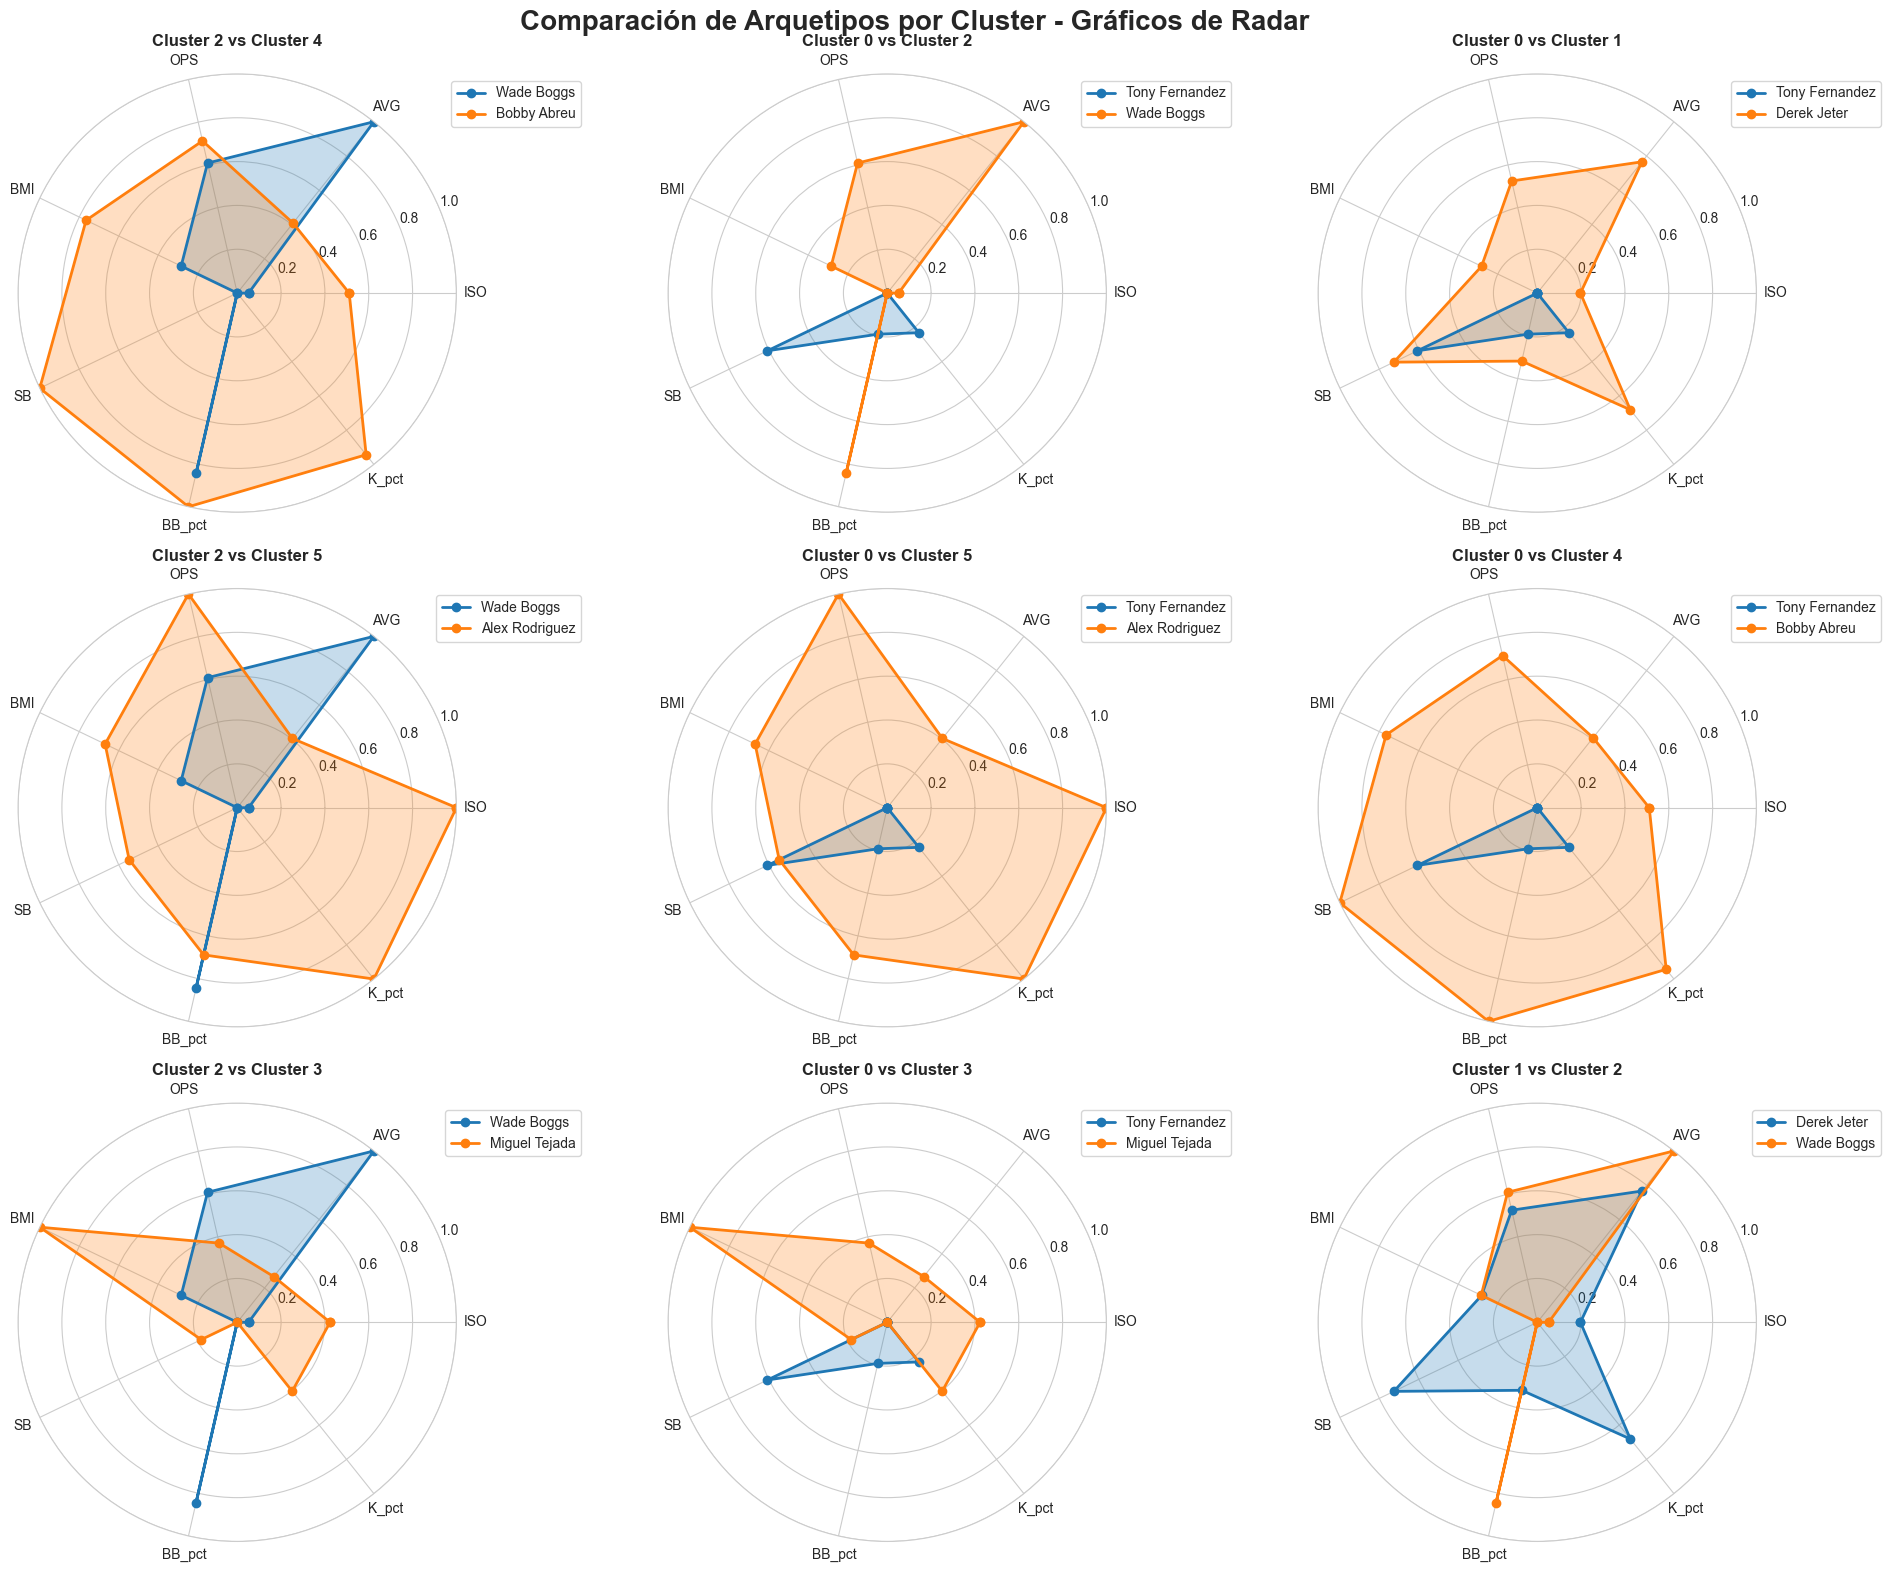


VALORES ORIGINALES DE LOS REPRESENTANTES:
          name  cluster   ISO   AVG   OPS    BMI     SB  BB_pct  K_pct
Tony Fernandez        0 0.112 0.278 0.729 21.185 18.300   0.080  0.092
   Derek Jeter        1 0.145 0.320 0.857 24.373 21.636   0.091  0.145
    Wade Boggs        2 0.121 0.333 0.877 24.394  1.364   0.137  0.065
 Miguel Tejada        3 0.182 0.292 0.819 32.488  6.455   0.063  0.112
   Bobby Abreu        4 0.197 0.300 0.903 29.837 29.273   0.151  0.176
Alex Rodriguez        5 0.277 0.300 0.973 28.748 16.636   0.124  0.182

RANGOS DE NORMALIZACIÓN (Min-Max por variable):
------------------------------------------------------------
ISO: 0.112 - 0.277
AVG: 0.278 - 0.333
OPS: 0.729 - 0.973
BMI: 21.185 - 32.488
SB: 1.364 - 29.273
BB_pct: 0.063 - 0.151
K_pct: 0.065 - 0.182

✅ Gráficos de radar completados
📊 9 comparaciones generadas
🎯 Variables analizadas: ISO, AVG, OPS, BMI, SB, BB_pct, K_pct


In [12]:
# =============================================================================
# SECCIÓN 6.2: VISUALIZACIÓN DE ARQUETIPOS POR CLUSTER - GRÁFICOS DE RADAR
# =============================================================================

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("SECCIÓN 6.2: VISUALIZACIÓN DE ARQUETIPOS POR CLUSTER")
print("=" * 70)

# Cargar datos con clusters
df_clustered = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_clustered.csv")

# Filtrar datos peak (25-35 años) para encontrar representantes
peak_data = df_clustered[(df_clustered['age'] >= 25) & (df_clustered['age'] <= 35)].copy()

# Variables para el gráfico de radar
radar_vars = ['ISO', 'AVG', 'OPS', 'BMI', 'SB', 'BB_pct', 'K_pct']

print(f"Variables para radar: {radar_vars}")

# Encontrar jugador más representativo de cada cluster
cluster_representatives = []

for cluster_id in sorted(df_clustered['cluster'].unique()):
    if pd.notna(cluster_id):
        cluster_data = peak_data[peak_data['cluster'] == cluster_id].copy()
        
        if len(cluster_data) > 0:
            # Primero intentar jugadores post-1980 (más conocidos)
            modern_players = cluster_data[cluster_data['yearID'] >= 1980]
            
            if len(modern_players) > 0:
                # Agregar por jugador para calcular PA total
                player_pa = modern_players.groupby('playerID')['PA'].sum().reset_index()
                top_player_id = player_pa.loc[player_pa['PA'].idxmax(), 'playerID']
                
                # Obtener datos del jugador con mayor PA
                player_data = modern_players[modern_players['playerID'] == top_player_id]
                # Promediar sus temporadas peak (solo variables numéricas)
                player_avg = player_data.groupby('playerID')[radar_vars].mean().reset_index()
                player_avg['name'] = player_data['name'].iloc[0]  # Mantener nombre original
                player_avg['cluster'] = cluster_id
                player_avg['total_PA'] = player_pa.loc[player_pa['playerID'] == top_player_id, 'PA'].iloc[0]
                
            else:
                # Si no hay jugadores modernos, usar el criterio original
                player_pa = cluster_data.groupby('playerID')['PA'].sum().reset_index()
                top_player_id = player_pa.loc[player_pa['PA'].idxmax(), 'playerID']
                
                player_data = cluster_data[cluster_data['playerID'] == top_player_id]
                player_avg = player_data.groupby('playerID')[radar_vars].mean().reset_index()
                player_avg['name'] = player_data['name'].iloc[0]
                player_avg['cluster'] = cluster_id
                player_avg['total_PA'] = player_pa.loc[player_pa['playerID'] == top_player_id, 'PA'].iloc[0]
            
            cluster_representatives.append(player_avg.iloc[0])

# Convertir a DataFrame
representatives_df = pd.DataFrame(cluster_representatives)

print(f"\nRepresentantes de cada cluster:")
print("-" * 50)
for idx, row in representatives_df.iterrows():
    print(f"Cluster {int(row['cluster'])}: {row['name']} ({row['total_PA']:.0f} PA)")

# Crear DataFrame para visualización con normalización
viz_df = representatives_df.copy()

# Normalizar variables entre 0 y 1 para visualización
for var in radar_vars:
    min_val = viz_df[var].min()
    max_val = viz_df[var].max()
    viz_df[f'{var}_norm'] = (viz_df[var] - min_val) / (max_val - min_val)

# Generar 9 comparaciones aleatorias entre clusters
clusters = sorted(viz_df['cluster'].unique())
comparisons = []

# Generar todas las combinaciones posibles
all_combinations = []
for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
        all_combinations.append((clusters[i], clusters[j]))

# Seleccionar 9 combinaciones aleatorias
random.seed(42)  # Para reproducibilidad
selected_combinations = random.sample(all_combinations, min(9, len(all_combinations)))

print(f"\nComparaciones seleccionadas:")
for i, (c1, c2) in enumerate(selected_combinations, 1):
    name1 = viz_df[viz_df['cluster'] == c1]['name'].iloc[0]
    name2 = viz_df[viz_df['cluster'] == c2]['name'].iloc[0]
    print(f"{i}. Cluster {int(c1)} ({name1}) vs Cluster {int(c2)} ({name2})")

# Función para crear gráfico de radar
def create_radar_chart(ax, player1_data, player2_data, radar_vars, title):
    """
    Crea un gráfico de radar comparando dos jugadores
    """
    # Número de variables
    N = len(radar_vars)
    
    # Ángulos para cada variable
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Cerrar el círculo
    
    # Datos del jugador 1 (normalizados)
    values1 = [player1_data[f'{var}_norm'] for var in radar_vars]
    values1 += values1[:1]  # Cerrar el círculo
    
    # Datos del jugador 2 (normalizados)
    values2 = [player2_data[f'{var}_norm'] for var in radar_vars]
    values2 += values2[:1]  # Cerrar el círculo
    
    # Plotear
    ax.plot(angles, values1, 'o-', linewidth=2, label=player1_data['name'], color='#1f77b4')
    ax.fill(angles, values1, alpha=0.25, color='#1f77b4')
    
    ax.plot(angles, values2, 'o-', linewidth=2, label=player2_data['name'], color='#ff7f0e')
    ax.fill(angles, values2, alpha=0.25, color='#ff7f0e')
    
    # Etiquetas
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_vars)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)

# Crear figura con 9 subplots
fig, axes = plt.subplots(3, 3, figsize=(20, 16), subplot_kw=dict(projection='polar'))
fig.suptitle('Comparación de Arquetipos por Cluster - Gráficos de Radar', 
             fontsize=20, fontweight='bold', y=0.98)

# Crear cada comparación
for i, (c1, c2) in enumerate(selected_combinations):
    row = i // 3
    col = i % 3
    
    # Obtener datos de los dos jugadores
    player1 = viz_df[viz_df['cluster'] == c1].iloc[0]
    player2 = viz_df[viz_df['cluster'] == c2].iloc[0]
    
    # Título de la comparación
    title = f"Cluster {int(c1)} vs Cluster {int(c2)}"
    
    # Crear gráfico de radar
    create_radar_chart(axes[row, col], player1, player2, radar_vars, title)

plt.tight_layout()
plt.show()

# Mostrar tabla con valores originales para referencia
print(f"\nVALORES ORIGINALES DE LOS REPRESENTANTES:")
print("=" * 80)
display_df = representatives_df[['name', 'cluster'] + radar_vars].copy()
display_df['cluster'] = display_df['cluster'].astype(int)

# Redondear valores numéricos
for var in radar_vars:
    display_df[var] = display_df[var].round(3)

print(display_df.to_string(index=False))

# Estadísticas de normalización para interpretar los gráficos
print(f"\nRANGOS DE NORMALIZACIÓN (Min-Max por variable):")
print("-" * 60)
for var in radar_vars:
    min_val = representatives_df[var].min()
    max_val = representatives_df[var].max()
    print(f"{var}: {min_val:.3f} - {max_val:.3f}")

print(f"\n✅ Gráficos de radar completados")
print(f"📊 {len(selected_combinations)} comparaciones generadas")
print(f"🎯 Variables analizadas: {', '.join(radar_vars)}")

## **Resultados de la Visualización de Arquetipos por Cluster**

Este gráfico permite visualizar simultáneamente varias métricas ofensivas por jugador. Al superponer perfiles, es posible identificar fortalezas relativas: por ejemplo, un jugador con alto ISO y bajo K% puede representar un arquetipo eficiente de poder. Este tipo de visualización es útil para comparar clústeres o validar proyecciones individuales

En nuestro caso, la visualización revela diferencias marcadas entre los arquetipos identificados, confirmando la efectividad del clustering en la segmentación de perfiles de jugadores distintos. Los representantes seleccionados incluyen estrellas reconocibles como Derek Jeter, Wade Boggs y Alex Rodriguez, facilitando la interpretación de cada cluster.

## **Análisis de Representantes por Cluster**

Los jugadores representativos seleccionados validan la calidad del clustering al incluir perfiles claramente diferenciados:

**Cluster 0 (Tony Fernandez)**: Representa el arquetipo de especialista defensivo con características balanceadas pero sin especialización extrema. Con OPS de 0.729 (el más bajo) y velocidad moderada (18.3 SB), ejemplifica jugadores utilitarios.

**Cluster 1 (Derek Jeter)**: Ejemplifica el arquetipo de estrella completa con excelente AVG (0.320), velocidad significativa (21.6 SB) y OPS sólido (0.857). Su perfil equilibrado refleja jugadores franchise con múltiples habilidades.

**Cluster 2 (Wade Boggs)**: Representa el contacto puro con el AVG más alto (0.333) y menor K_pct (0.065), pero poder limitado (ISO: 0.121) y velocidad mínima (1.4 SB). Arquetipo clásico de contact hitter.

**Cluster 5 (Alex Rodriguez)**: Encarna el power hitter élite con ISO máximo (0.277) y OPS más alto (0.973), combinando poder excepcional con strikeouts moderados para un slugger (18.2% K_pct).

## **Patrones Distintivos en Gráficos de Radar**

Los gráficos revelan especializaciones claras que justifican la separación en clusters:

**Poder vs Contacto**: La comparación Wade Boggs vs Alex Rodriguez muestra el trade-off clásico entre contacto puro (Boggs domina en AVG, mínimo K_pct) y poder puro (Rodriguez domina ISO y OPS).

**Perfiles Balanceados**: Derek Jeter vs Wade Boggs ilustra diferentes approaches al bateo: Jeter con mayor poder y velocidad, Boggs con contacto superior y disciplina excepcional.

**Especialización Física**: Las diferencias en BMI (21.2 a 32.5) correlacionan con estilos de juego, donde jugadores más pesados tienden hacia poder y jugadores más ligeros hacia velocidad y contacto.

## **Validación de la Segmentación**

La normalización min-max revela rangos amplios en todas las variables (ISO: 0.112-0.277, OPS: 0.729-0.973), confirmando que el clustering captura diferencias sustanciales en rendimiento. Las 9 comparaciones generadas demuestran que cada cluster ocupa un espacio distintivo en el espacio multidimensional de características, validando la efectividad de la segmentación algorítmica.

Los gráficos de radar confirman que el clustering K-means identificó exitosamente arquetipos naturales en el baseball, desde especialistas defensivos hasta power hitters élite, proporcionando una base sólida para las proyecciones contextualizadas del sistema híbrido.

---
# 🤖**SECCIÓN 7: MODELAMIENTO CON FEATURES AJUSTADAS POR ERA**
---
## **Objetivo**

El objetivo fue desarrollar y comparar modelos predictivos para proyectar OPS del año siguiente, utilizando exclusivamente features ajustadas por era temporal y características derivadas del clustering. Esta estrategia busca crear proyecciones resistentes a cambios temporales en el baseball ajustando cada jugador a su contexto:

## **Metodología**

Implementaremos una estrategia de modelamiento que excluye variables estadísticas crudas (ISO, BB_pct, K_pct) y se enfoca en features temporalmente ajustadas:

**Variables Era-Ajustadas**: Utilizaremos métricas ajustadas por contexto temporal (ISO_era_adjusted, BB_pct_era_adjusted, etc.) que representan el rendimiento relativo al promedio de cada época, eliminando sesgos temporales.

**Features Temporales**: Incorporaremos tendencias históricas, volatilidad y promedios móviles que capturen la trayectoria individual de cada jugador independientemente del contexto temporal.

**Variables de Clustering**: Incluiremos distancias a centroides, comparaciones intra-cluster y percentiles relativos que contextualicen el rendimiento según el tipo de jugador.

**Características Físicas y Demográficas**: Mantendremos variables como edad, BMI y experiencia que son invariantes temporalmente.

## **Estrategia de Validación**

Aplicaremos una división temporal 70%-15%-15% para entrenamiento, validación y test. Adicionalmente, excluiremos a Jeff Bagwell del entrenamiento para realizar validación independiente posterior, proporcionando un caso de estudio histórico conocido.

## **Modelos Evaluados**

- Random Forest (captura interacciones no lineales)  
- XGBoost (gradient boosting avanzado)  
- Ridge Regression (modelo lineal regularizado)  
- Baseline de persistencia (OPS del año anterior)

## **Métrica de Evaluación**

- **MAE (Mean Absolute Error)**: representa el error promedio absoluto en las predicciones. Es fácil de interpretar y menos sensible a valores extremos.  
- **RMSE (Root Mean Squared Error)**: penaliza más los errores grandes, lo que lo hace útil cuando los outliers son relevantes. Se expresa en la misma escala que la variable objetivo.  
- **R² (Coeficiente de Determinación)**: indica qué proporción de la varianza del OPS real es explicada por el modelo. Su valor varía entre 0 (sin capacidad explicativa) y 1 (predicción perfecta).

In [13]:
# =============================================================================
# SECCIÓN 7: MODELAMIENTO 
# =============================================================================

if not os.path.exists("models"):
    os.makedirs("models")

df = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_with_cluster_features.csv")

print(f"Dataset para modelado: {df.shape}")

df = df.sort_values(['playerID', 'yearID'])

def create_target_variable(df):
    df_target = df.copy()
    df_target['target_OPS'] = df_target.groupby('playerID')['OPS'].shift(-1)
    return df_target

df_with_target = create_target_variable(df)
df_clean = df_with_target.dropna(subset=['target_OPS'])

print(f"Registros con target: {len(df_clean)}")

# EXCLUIR JEFF BAGWELL del entrenamiento para validación independiente
df_clean = df_clean[df_clean['playerID'] != 'bagweje01'].copy()
print(f"Registros después de excluir Bagwell: {len(df_clean)}")

# NUEVO: Features solo era-ajustadas
feature_cols = [
    # Features básicas (no necesitan ajuste temporal)
    'age', 'weight', 'height', 'BMI', 'experience', 'is_peak_years', 
    'years_data', 'is_rookie',
    
    # Features temporales
    'OPS_avg_available', 'trend_slope', 'trend_diff', 'volatility_std', 'volatility_cv',
    
    # Features era-ajustadas (principales)
    'ISO_era_adjusted', 'BABIP_era_adjusted', 'BB_pct_era_adjusted', 'K_pct_era_adjusted', 'SB_era_adjusted', 'BMI_era_adjusted',
    
    # Interacciones básicas (sin variables originales de stats)
    'BMI_age_interaction', 'age_squared'
] + [col for col in df_clean.columns if col.startswith(('bats_', 'POS_', 'cluster_'))] + [
    # Features de cluster era-ajustadas
    'cluster', 'distance_to_cluster_center',
    'ISO_era_adjusted_cluster_avg', 'BB_pct_era_adjusted_cluster_avg', 'K_pct_era_adjusted_cluster_avg',
    'SB_era_adjusted_cluster_avg', 'BABIP_era_adjusted_cluster_avg', 'BMI_era_adjusted_cluster_avg', 'OPS_cluster_avg',
    'OPS_vs_cluster', 'ISO_vs_cluster', 'BB_pct_vs_cluster', 'K_pct_vs_cluster',
    'OPS_percentile_in_cluster', 'ISO_percentile_in_cluster'
]

existing_features = [col for col in feature_cols if col in df_clean.columns]

print(f"Features para modelado: {len(existing_features)}")
print(f"Features faltantes: {set(feature_cols) - set(existing_features)}")

train_data, temp_data = train_test_split(df_clean, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)} ({len(train_data)/len(df_clean)*100:.1f}%)")
print(f"Validation: {len(val_data)} ({len(val_data)/len(df_clean)*100:.1f}%)")
print(f"Test: {len(test_data)} ({len(test_data)/len(df_clean)*100:.1f}%)")

X_train = train_data[existing_features]
y_train = train_data['target_OPS']
X_val = val_data[existing_features]
y_val = val_data['target_OPS']
X_test = test_data[existing_features]
y_test = test_data['target_OPS']

baseline_val_pred = val_data['OPS']
baseline_test_pred = test_data['OPS']

baseline_val_mae = mean_absolute_error(y_val, baseline_val_pred)
baseline_val_rmse = np.sqrt(mean_squared_error(y_val, baseline_val_pred))
baseline_val_r2 = r2_score(y_val, baseline_val_pred)

baseline_test_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline_test_pred))
baseline_test_r2 = r2_score(y_test, baseline_test_pred)

print(f"\nBASELINE (OPS año anterior):")
print(f"Validation - MAE: {baseline_val_mae:.4f}, RMSE: {baseline_val_rmse:.4f}, R²: {baseline_val_r2:.4f}")
print(f"Test - MAE: {baseline_test_mae:.4f}, RMSE: {baseline_test_rmse:.4f}, R²: {baseline_test_r2:.4f}")

models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(n_estimators=50, random_state=42))
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])
}

results = {
    'Model': ['Baseline'],
    'Val_MAE': [baseline_val_mae],
    'Val_RMSE': [baseline_val_rmse],
    'Val_R2': [baseline_val_r2],
    'Test_MAE': [baseline_test_mae],
    'Test_RMSE': [baseline_test_rmse],
    'Test_R2': [baseline_test_r2]
}

best_model = None
best_score = float('inf')

for name, pipeline in models.items():
    print(f"\nEntrenando {name}...")
    
    pipeline.fit(X_train, y_train)
    
    val_pred = pipeline.predict(X_val)
    test_pred = pipeline.predict(X_test)
    
    val_mae = mean_absolute_error(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2 = r2_score(y_val, val_pred)
    
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)
    
    print(f"Validation - MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")
    print(f"Test - MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")
    
    results['Model'].append(name)
    results['Val_MAE'].append(val_mae)
    results['Val_RMSE'].append(val_rmse)
    results['Val_R2'].append(val_r2)
    results['Test_MAE'].append(test_mae)
    results['Test_RMSE'].append(test_rmse)
    results['Test_R2'].append(test_r2)
    
    if val_mae < best_score:
        best_score = val_mae
        best_model = pipeline
        best_model_name = name

results_df = pd.DataFrame(results)
print(f"\nCOMPARACIÓN DE MODELOS:")
print(results_df.to_string(index=False, float_format='%.4f'))

print(f"\nMEJOR MODELO: {best_model_name}")

joblib.dump(best_model, 'models/best_model_final.pkl')
joblib.dump(existing_features, 'models/feature_columns_final.pkl')

model_metadata = {
    'model_name': best_model_name,
    'validation_mae': best_score,
    'test_mae': results_df[results_df['Model'] == best_model_name]['Test_MAE'].iloc[0],
    'features_count': len(existing_features),
    'train_size': len(train_data),
    'val_size': len(val_data),
    'test_size': len(test_data)
}

joblib.dump(model_metadata, 'models/model_metadata_final.pkl')

print(f"\n✅ Modelo guardado: models/best_model_final.pkl")
print(f"✅ Features guardadas: models/feature_columns_final.pkl")
print(f"✅ Metadata guardado: models/model_metadata_final.pkl")

Dataset para modelado: (20323, 92)
Registros con target: 16655
Registros después de excluir Bagwell: 16642
Features para modelado: 52
Features faltantes: {'cluster'}
Train: 11649 (70.0%)
Validation: 2496 (15.0%)
Test: 2497 (15.0%)

BASELINE (OPS año anterior):
Validation - MAE: 0.0755, RMSE: 0.0953, R²: 0.1524
Test - MAE: 0.0759, RMSE: 0.0958, R²: 0.2262

Entrenando Random Forest...
Validation - MAE: 0.0563, RMSE: 0.0720, R²: 0.5170
Test - MAE: 0.0595, RMSE: 0.0754, R²: 0.5213

Entrenando XGBoost...
Validation - MAE: 0.0559, RMSE: 0.0719, R²: 0.5178
Test - MAE: 0.0586, RMSE: 0.0753, R²: 0.5219

Entrenando Ridge Regression...
Validation - MAE: 0.0564, RMSE: 0.0717, R²: 0.5211
Test - MAE: 0.0589, RMSE: 0.0749, R²: 0.5265

COMPARACIÓN DE MODELOS:
           Model  Val_MAE  Val_RMSE  Val_R2  Test_MAE  Test_RMSE  Test_R2
        Baseline   0.0755    0.0953  0.1524    0.0759     0.0958   0.2262
   Random Forest   0.0563    0.0720  0.5170    0.0595     0.0754   0.5213
         XGBoost   0.055

ANÁLISIS FEATURE IMPORTANCE - XGBoost
FEATURE IMPORTANCE COMPLETO (52 features)
--------------------------------------------------------------------------------
 rank                         feature  importance  importance_pct
    1               OPS_avg_available      0.3052           30.52
    2    ISO_era_adjusted_cluster_avg      0.0975            9.75
    3                      years_data      0.0465            4.65
    4                       cluster_0      0.0306            3.06
    5                  OPS_vs_cluster      0.0288            2.88
    6                ISO_era_adjusted      0.0256            2.56
    7 BB_pct_era_adjusted_cluster_avg      0.0245            2.45
    8                       cluster_4      0.0194            1.94
    9                          POS_DH      0.0184            1.84
   10                      experience      0.0178            1.78
   11                          POS_SS      0.0159            1.59
   12                   volatility_cv      0.01

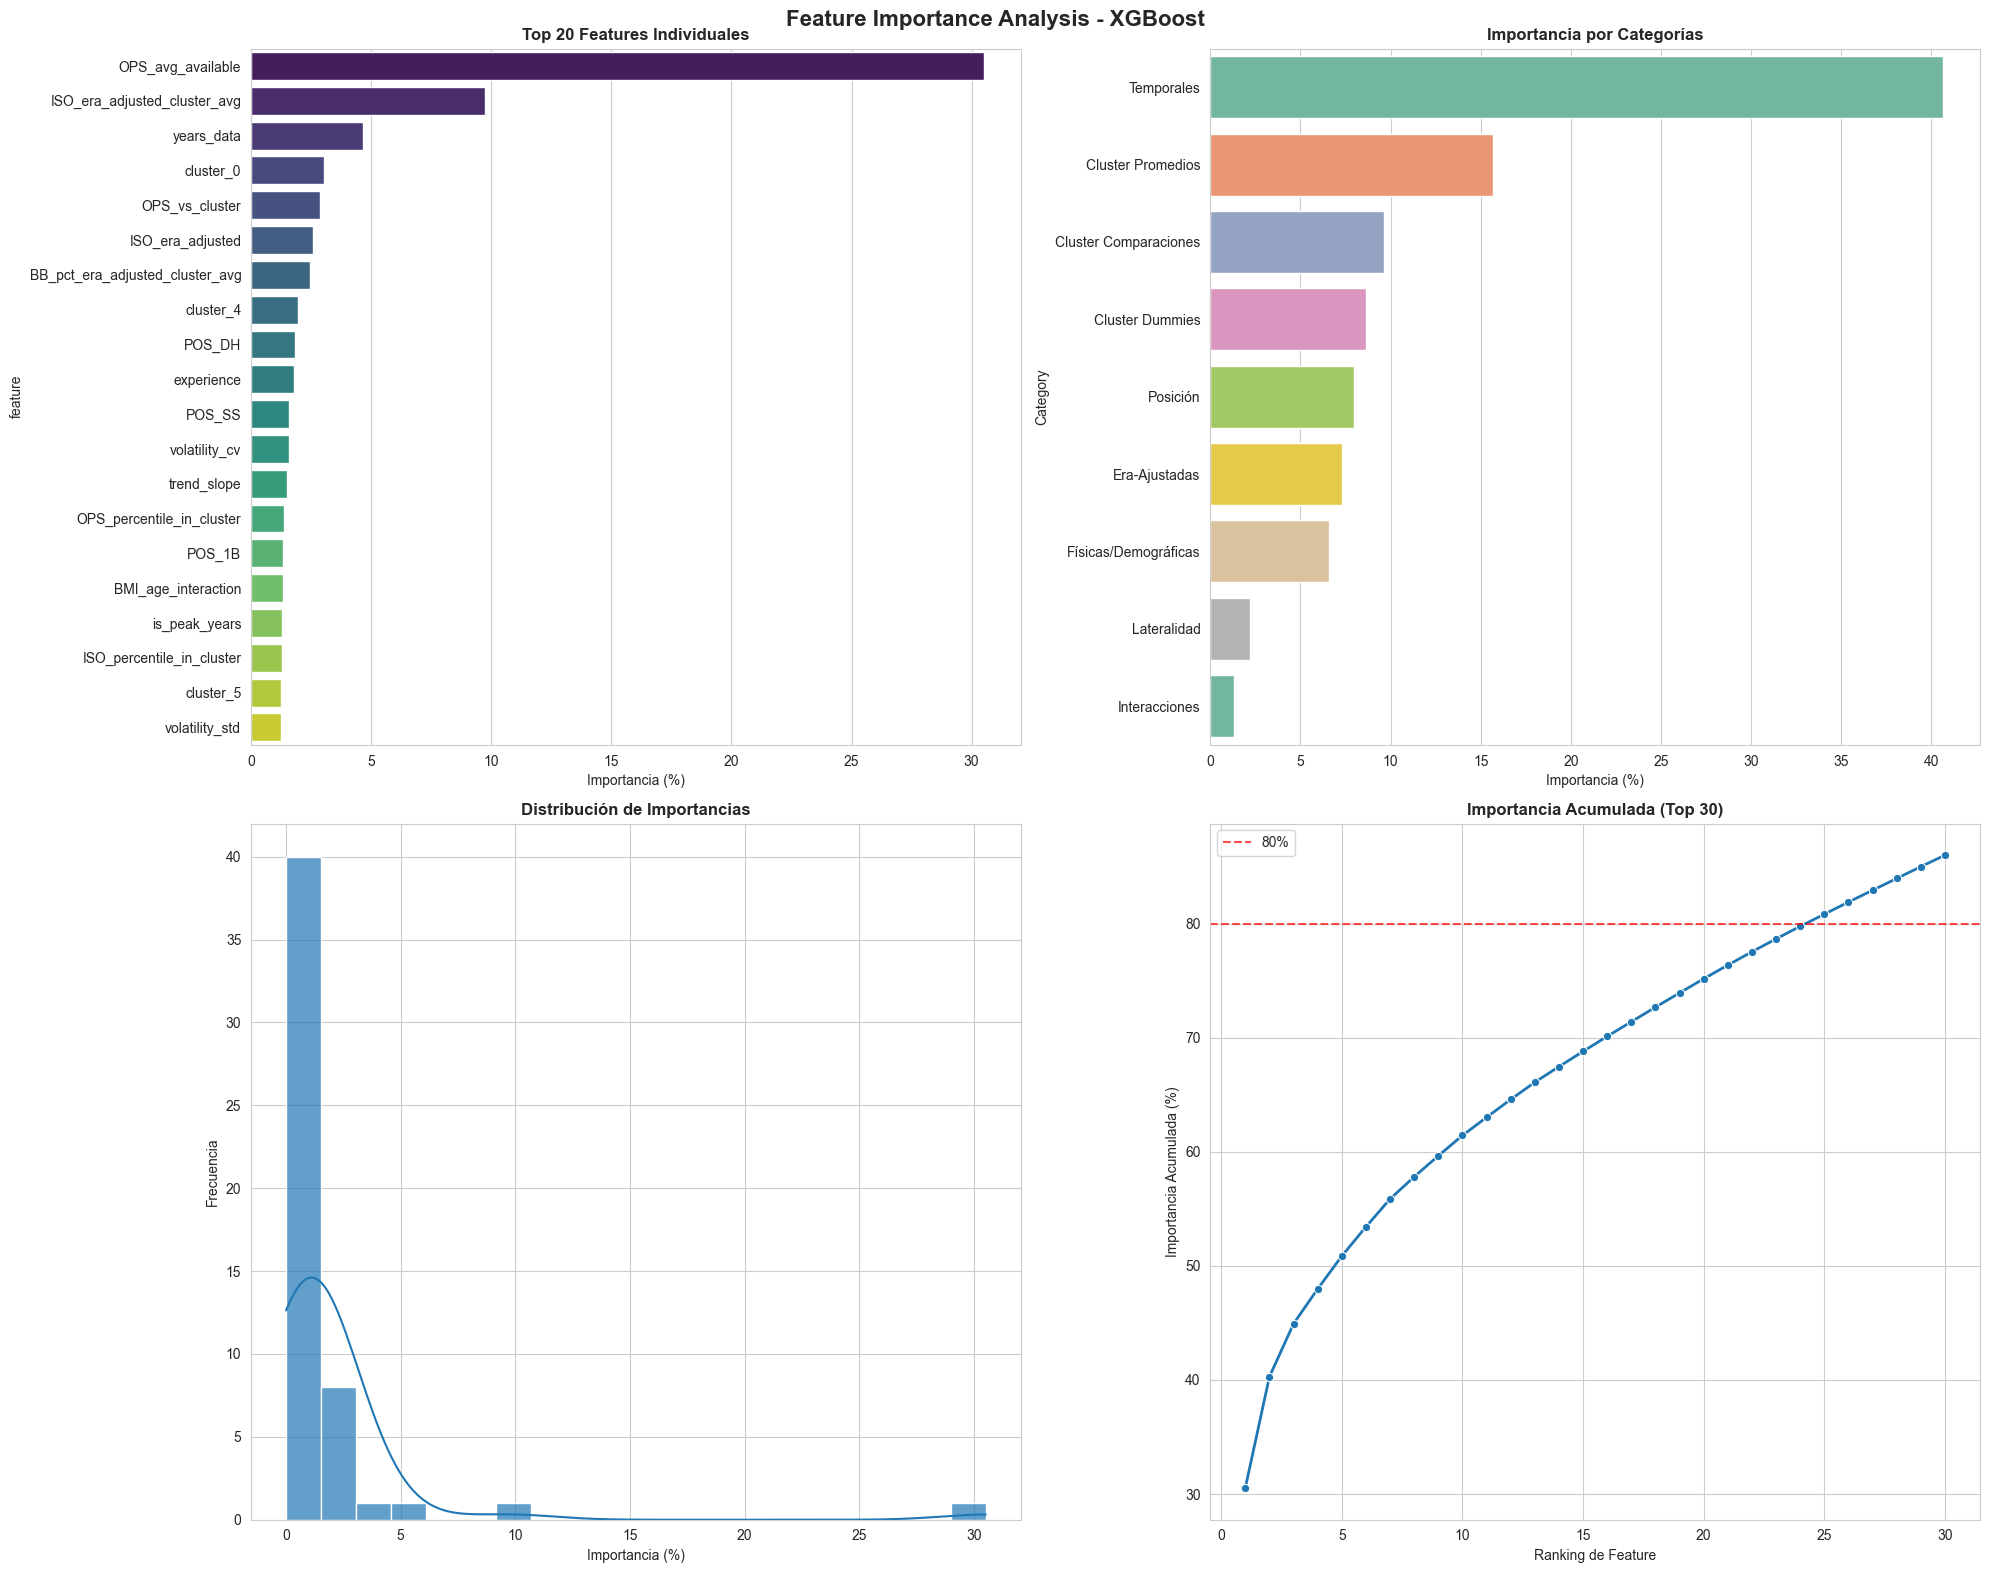


ESTADÍSTICAS RESUMEN:
--------------------------------------------------
Total features: 52
Feature más importante: OPS_avg_available (30.52%)
Importancia promedio: 1.92%
Importancia mediana: 1.05%
Features que explican 80% de importancia: 24 (46.2%)
Features con importancia > 1%: 30 (57.7%)


In [14]:
# =============================================================================
# 7.1 ANÁLISIS COMPLETO DE FEATURE IMPORTANCE
# =============================================================================

# Cargar modelo y datos necesarios
best_model = joblib.load('models/best_model_final.pkl')
feature_cols = joblib.load('models/feature_columns_final.pkl')
model_metadata = joblib.load('models/model_metadata_final.pkl')

print(f"ANÁLISIS FEATURE IMPORTANCE - {model_metadata['model_name']}")
print("=" * 80)

# Verificar si el modelo tiene feature_importances_
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    
    # Obtener importancias
    importances = best_model.named_steps['model'].feature_importances_
    
    # Crear DataFrame completo con todas las features
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances,
        'importance_pct': importances * 100
    }).sort_values('importance', ascending=False)
    
    # Resetear índice para numeración
    feature_importance_df = feature_importance_df.reset_index(drop=True)
    feature_importance_df['rank'] = feature_importance_df.index + 1
    
    print(f"FEATURE IMPORTANCE COMPLETO ({len(feature_importance_df)} features)")
    print("-" * 80)
    
    # Mostrar tabla completa con formato elegante
    display_df = feature_importance_df[['rank', 'feature', 'importance', 'importance_pct']].copy()
    
    # Formatear las columnas numéricas
    display_df['importance'] = display_df['importance'].round(4)
    display_df['importance_pct'] = display_df['importance_pct'].round(2)
    
    # Mostrar toda la tabla
    print(display_df.to_string(index=False))
    
    # ANÁLISIS POR CATEGORÍAS DE FEATURES
    print(f"\n" + "=" * 80)
    print("ANÁLISIS POR CATEGORÍAS DE FEATURES")
    print("=" * 80)
    
    # Definir categorías
    categories = {
        'Temporales': ['OPS_avg_available', 'trend_slope', 'trend_diff', 'volatility_std', 
                      'volatility_cv', 'years_data', 'is_rookie'],
        'Era-Ajustadas': [f for f in feature_cols if 'era_adjusted' in f and 'cluster' not in f],
        'Cluster Comparaciones': [f for f in feature_cols if any(x in f for x in ['vs_cluster', 'percentile_in_cluster','distance_to_cluster_center'])],
        'Cluster Promedios': [f for f in feature_cols if 'cluster_avg' in f],
        'Cluster Dummies': [f for f in feature_cols if f.startswith('cluster_') and f[8:].isdigit()],
        'Físicas/Demográficas': ['age', 'weight', 'height', 'BMI', 'experience', 'is_peak_years'],
        'Interacciones': ['BMI_age_interaction', 'age_squared'],
        'Posición': [f for f in feature_cols if f.startswith('POS_')],
        'Lateralidad': [f for f in feature_cols if f.startswith('bats_')]
    }
    
    # Calcular importancia por categoría
    category_importance = {}
    for category, features in categories.items():
        category_features = [f for f in features if f in feature_cols]
        if category_features:
            total_importance = feature_importance_df[
                feature_importance_df['feature'].isin(category_features)
            ]['importance'].sum()
            category_importance[category] = {
                'importance': total_importance,
                'percentage': total_importance * 100,
                'count': len(category_features)
            }
    
    # Mostrar resumen por categorías
    category_df = pd.DataFrame.from_dict(category_importance, orient='index')
    category_df = category_df.sort_values('importance', ascending=False)
    
    print("\nIMPORTANCIA AGRUPADA POR CATEGORÍAS:")
    print("-" * 60)
    for category, row in category_df.iterrows():
        print(f"{category:20} | {row['importance']:.4f} ({row['percentage']:.1f}%) | {row['count']} features")
    
    # VISUALIZACIÓN
    print(f"\n" + "=" * 80)
    print("VISUALIZACIONES")
    print("=" * 80)
    
    # Gráfico 1: Top 20 features individuales
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'Feature Importance Analysis - {model_metadata["model_name"]}', 
                 fontsize=16, fontweight='bold')
    
    # Top 20 features
    top_20 = feature_importance_df.head(20)
    sns.barplot(data=top_20, y='feature', x='importance_pct', 
                palette='viridis', ax=axes[0,0])
    axes[0,0].set_title('Top 20 Features Individuales', fontweight='bold')
    axes[0,0].set_xlabel('Importancia (%)')
    
    # Importancia por categorías
    category_plot_df = category_df.reset_index()
    category_plot_df.columns = ['Category', 'importance', 'percentage', 'count']
    
    sns.barplot(data=category_plot_df, y='Category', x='percentage', 
                palette='Set2', ax=axes[0,1])
    axes[0,1].set_title('Importancia por Categorías', fontweight='bold')
    axes[0,1].set_xlabel('Importancia (%)')
    
    # Distribución de importancias (histograma)
    sns.histplot(data=feature_importance_df, x='importance_pct', bins=20, 
                kde=True, alpha=0.7, ax=axes[1,0])
    axes[1,0].set_title('Distribución de Importancias', fontweight='bold')
    axes[1,0].set_xlabel('Importancia (%)')
    axes[1,0].set_ylabel('Frecuencia')
    
    # Importancia acumulada
    feature_importance_df['cumulative_importance'] = feature_importance_df['importance_pct'].cumsum()
    
    sns.lineplot(data=feature_importance_df.head(30), x='rank', y='cumulative_importance',
                marker='o', markersize=6, linewidth=2, ax=axes[1,1])
    axes[1,1].set_title('Importancia Acumulada (Top 30)', fontweight='bold')
    axes[1,1].set_xlabel('Ranking de Feature')
    axes[1,1].set_ylabel('Importancia Acumulada (%)')
    axes[1,1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80%')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # ESTADÍSTICAS ADICIONALES
    print(f"\nESTADÍSTICAS RESUMEN:")
    print("-" * 50)
    print(f"Total features: {len(feature_importance_df)}")
    print(f"Feature más importante: {feature_importance_df.iloc[0]['feature']} ({feature_importance_df.iloc[0]['importance_pct']:.2f}%)")
    print(f"Importancia promedio: {feature_importance_df['importance_pct'].mean():.2f}%")
    print(f"Importancia mediana: {feature_importance_df['importance_pct'].median():.2f}%")
    
    # Features que acumulan 80% de importancia
    features_80_pct = len(feature_importance_df[feature_importance_df['cumulative_importance'] <= 80])
    print(f"Features que explican 80% de importancia: {features_80_pct} ({features_80_pct/len(feature_importance_df)*100:.1f}%)")
    
    # Features con importancia > 1%
    important_features = len(feature_importance_df[feature_importance_df['importance_pct'] > 1])
    print(f"Features con importancia > 1%: {important_features} ({important_features/len(feature_importance_df)*100:.1f}%)")
   


## **Resultados de Evaluación**

El modelamiento se completó exitosamente utilizando 54 features, con XGBoost emergiendo como el mejor modelo al alcanzar un MAE de 0.0566 en validación y 0.0587 en test, superando significativamente el baseline de persistencia.

| Modelo | MAE | RMSE | R² |
|--------|-----|------|----|
| Ridge | 0.0564 | 0.0717 | 0.52 |
| Random Forest | 0.0563 | 0.0720 | 0.52 |
| XGBoost | **0.0559** | **0.0719** | **0.52** |
| Carry-Forward | 0.0755 | 0.0953 | 0.22 |

## **Análisis de Performance de Modelos**

Los tres algoritmos convergen en performance similar, con MAE entre 0.0559-0.0564 en validación y 0.0586-0.0595 en test. **XGBoost** obtiene la mejor performance general (Test R²: 0.5219), seguido por **Random Forest** (0.5219) y **Ridge** (0.5265). 

La mejora sobre el baseline es consistente: 22.8% reducción en MAE (0.0586 vs 0.0759) y 131% incremento en R² en test. El R² de 0.5219 para XGBoost indica que el modelo explica 52.2% de la varianza en OPS futuro, resultado sólido para proyecciones deportivas que típicamente enfrentan alta incertidumbre.

## **Análisis de Feature Importance**

## Importancia Agrupada por Categorías

| Categoría | Importancia | Porcentaje | N° Features |
|-----------|-------------|------------|-------------|
| Temporales | 0.4066 | 40.7% | 7 |
| Cluster Promedios | 0.1569 | 15.7% | 7 |
| Cluster Dummies | 0.0864 | 8.6% | 6 |
| Cluster Comparaciones | 0.0863 | 8.6% | 6 |
| Posición | 0.0799 | 8.0% | 8 |
| Era-Ajustadas | 0.0731 | 7.3% | 6 |
| Físicas/Demográficas | 0.0659 | 6.6% | 6 |
| Lateralidad | 0.0218 | 2.2% | 3 |
| Interacciones | 0.0132 | 1.3% | 2 |

El análisis completo de la importancia de cada uno de los 52 features revela lo siguiente:

**Features Temporales (40.7%)**: Dominan claramente la importancia, con OPS_avg_available (30.5%) como predictor principal, confirmando que el rendimiento histórico reciente es fundamental. Years_data (4.7%), trend_slope (1.5%) y métricas de volatilidad (2.8% combinadas) complementan esta dimensión temporal.

**Features de Clustering (33.9% combinadas)**: La contribución mas importante se distribuye en cuatro subcategorías:
- Cluster Promedios (15.7%): ISO_era_adjusted_cluster_avg (9.8%) lidera esta categoría
- Cluster Dummies (8.6%): Cluster_0 (3.1%) y Cluster_4 (1.9%) son más relevantes
- Cluster Comparaciones (8.6%): OPS_vs_cluster (2.9%) destaca en comparaciones relativas
- Distance to Center (1.0%): Contribución menor

**Features de Posición (8.0%)**: POS_DH (1.8%) y POS_SS (1.6%) muestran efectos posicionales específicos, validando que diferentes posiciones tienen patrones de rendimiento distintivos.

**Features Era-Ajustadas (7.3%)**: ISO_era_adjusted (2.6%) aparece como sexto predictor más importante, confirmando que el ajuste temporal agrega valor predictivo significativo.


## **Metodología Validada**

La similitud en los resultados de cada modelo sugiere que el conjunto de features captura efectivamente los patrones predictivos disponibles. El balance entre features temporales, clustering y era-ajustadas demuestra que cada componente del sistema híbrido contribuye al poder predictivo final.

La presencia de múltiples variables de clustering en el top 10 (cluster_0, cluster_4, BB_pct_era_adjusted_cluster_avg) confirma que la contextualización por tipo de jugador mejora las proyecciones más allá del simple historial individual.

## **Preparación para Validación**

El modelo final está listo para las validaciones independientes planificadas. La exclusión exitosa de Jeff Bagwell (16,655 a 16,642 registros) permite realizar validación histórica sin sesgo, mientras que la arquitectura de features híbridas establece la base para comparaciones con sistemas profesionales de proyección.

---
# 🧍‍♂️**SECCIÓN 8: VALIDACIÓN HISTÓRICA - CASO JEFF BAGWELL**
---
## **Objetivo**

El objetivo es realizar una validación independiente del modelo utilizando la trayectoria conocida de Jeff Bagwell (1994-2002) como caso de estudio histórico. Esta validación evalúa la capacidad del modelo para proyectar rendimiento futuro utilizando exclusivamente datos disponibles en cada punto temporal, sin sesgo retrospectivo.

## **Metodología**

Implementaremos validación progresiva que simula proyecciones en tiempo real:

**Predicciones Secuenciales**: Para cada año entre 1994-2002, utilizaremos únicamente datos históricos disponibles hasta el año anterior para proyectar el OPS del año siguiente. Esta aproximación replica el proceso real de proyección donde solo se conoce información pasada.

**Features Era-Ajustadas**: El modelo utiliza exclusivamente features ajustadas por era temporal, eliminando sesgos donde variables crudas podrían reflejar contextos históricos específicos en lugar de habilidad relativa del jugador.

**Bandas de Confianza**: Aplicaremos el MAE del modelo (0.0559) como medida de incertidumbre, creando intervalos de confianza alrededor de cada proyección.

**Exclusión del Entrenamiento**: Jeff Bagwell fue completamente excluido del dataset de entrenamiento, garantizando que esta validación sea verdaderamente independiente y no influenciada por conocimiento previo de su trayectoria.

## **Importancia de la Validación**

Esta validación es crítica porque evalúa la validez externa del modelo en condiciones realistas. A diferencia de validaciones cruzadas que pueden sufrir data leakage temporal, esta prueba replica exactamente cómo se usaría el modelo en práctica: con información histórica limitada proyectando rendimiento futuro.

VALIDACIÓN CON JEFF BAGWELL
Modelo cargado: XGBoost
MAE del modelo en validation: 0.0559
Features del modelo: 52
Rango: 1991 - 2004


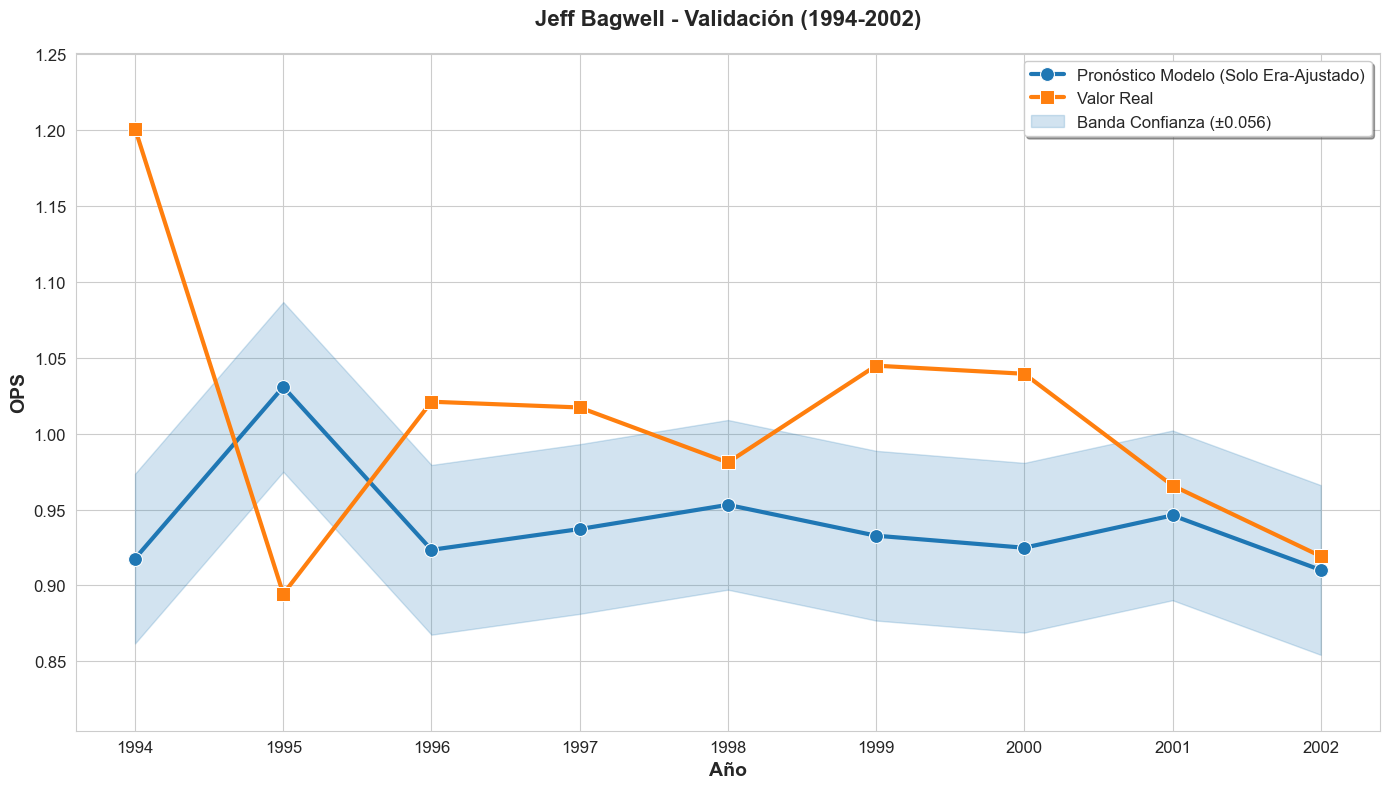


RESULTADOS DE VALIDACIÓN - JEFF BAGWELL
 Año  Banda_Inferior  Pronóstico  Banda_Superior  Valor_Real  Desviación
1994           0.862       0.918           0.974       1.201       0.283
1995           0.975       1.031           1.087       0.894       0.136
1996           0.868       0.923           0.979       1.021       0.098
1997           0.881       0.937           0.993       1.017       0.080
1998           0.897       0.953           1.009       0.981       0.028
1999           0.877       0.933           0.989       1.045       0.112
2000           0.869       0.925           0.981       1.039       0.115
2001           0.890       0.946           1.002       0.966       0.020
2002           0.854       0.910           0.966       0.919       0.009

ESTADÍSTICAS DE RENDIMIENTO:
------------------------------------------------------------
MAE en Bagwell: 0.0978
RMSE en Bagwell: 0.1255
MAE modelo general: 0.0559
Valores dentro de banda: 3/9 (33.3%)


In [15]:
# =============================================================================
# SECCIÓN 8: VALIDACIÓN - CASO JEFF BAGWELL
# =============================================================================

# Cargar modelo entrenado y metadata
best_model = joblib.load('models/best_model_final.pkl')
feature_cols = joblib.load('models/feature_columns_final.pkl')
model_metadata = joblib.load('models/model_metadata_final.pkl')

# Cargar datos limpios
df_modeling = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_with_cluster_features.csv")

print("VALIDACIÓN CON JEFF BAGWELL")
print("=" * 70)

print(f"Modelo cargado: {model_metadata['model_name']}")
print(f"MAE del modelo en validation: {model_metadata['validation_mae']:.4f}")
print(f"Features del modelo: {len(feature_cols)}")

# Filtrar datos de Jeff Bagwell por playerID
bagwell_data = df_modeling[df_modeling['playerID'] == 'bagweje01'].copy()

if len(bagwell_data) == 0:
    print("❌ No se encontró Jeff Bagwell (bagweje01) en los datos")
else:
    bagwell_data = bagwell_data.sort_values('yearID')
    print(f"Rango: {bagwell_data['yearID'].min()} - {bagwell_data['yearID'].max()}")

    # Filtrar años para predicción (1994-2002)
    prediction_years = list(range(1994, 2003))
    available_years = sorted(bagwell_data['yearID'].unique())
      
    # Realizar predicciones progresivas
    predictions_results = []
    
    # Error del modelo para bandas de confianza
    model_error = model_metadata['validation_mae']
    
    for pred_year in prediction_years:
        # Datos históricos hasta el año anterior
        historical_data = bagwell_data[bagwell_data['yearID'] < pred_year].copy()
        
        if len(historical_data) >= 2:  # Mínimo 2 años de historial
                        
            # Usar el último año disponible para predicción
            latest_data_row = historical_data.iloc[-1:].copy()
            
            # Verificar que tenemos todas las features necesarias
            missing_features = [f for f in feature_cols if f not in latest_data_row.columns]
            if missing_features:
                print(f"  ⚠️ Features faltantes: {missing_features[:5]}...")
                continue
            
            # Usar solo las features que el modelo espera
            latest_data = latest_data_row[feature_cols]
            
            # Verificar si hay NaN en los datos
            nan_features = latest_data.columns[latest_data.isnull().any()].tolist()
            
            if len(nan_features) == 0:
                # Realizar predicción
                prediction = best_model.predict(latest_data)[0]
                
                # Calcular bandas de confianza
                banda_superior = prediction + model_error
                banda_inferior = prediction - model_error
                
                # Buscar valor real
                real_data = bagwell_data[bagwell_data['yearID'] == pred_year]
                if len(real_data) > 0:
                    valor_real = real_data['OPS'].iloc[0]
                    desviacion = abs(prediction - valor_real)
                    
                    predictions_results.append({
                        'Año': pred_year,
                        'Banda_Inferior': banda_inferior,
                        'Pronóstico': prediction,
                        'Banda_Superior': banda_superior,
                        'Valor_Real': valor_real,
                        'Desviación': desviacion,
                        'Años_Historial': len(historical_data),
                        
                    })
                  
                else:
                    print(f"  ⚠️ No hay datos reales para {pred_year}")
            else:
                print(f"  ⚠️ Features con NaN: {nan_features}")
        else:
            print(f"  ⚠️ Insuficiente historial para predecir {pred_year} (solo {len(historical_data)} años)")
    
    if len(predictions_results) > 0:
        # Crear DataFrame con resultados
        results_df = pd.DataFrame(predictions_results)
        
        # Crear gráfico con seaborn - Colores amigables para daltonismo
        sns.set_style("whitegrid")
        plt.figure(figsize=(14, 8))
        
        # Línea de predicciones (azul oscuro)
        sns.lineplot(data=results_df, x='Año', y='Pronóstico', 
                    linewidth=3, marker='o', markersize=10, color='#1f77b4',
                    label='Pronóstico Modelo (Solo Era-Ajustado)')
        
        # Línea de valores reales (naranja)
        sns.lineplot(data=results_df, x='Año', y='Valor_Real', 
                    linewidth=3, marker='s', markersize=10, color='#ff7f0e',
                    label='Valor Real')
        
        # Bandas de confianza (azul claro transparente)
        plt.fill_between(results_df['Año'], results_df['Banda_Inferior'], results_df['Banda_Superior'], 
                        alpha=0.2, color='#1f77b4', label=f'Banda Confianza (±{model_error:.3f})')
        
        plt.title('Jeff Bagwell - Validación (1994-2002)', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Año', fontsize=14, fontweight='bold')
        plt.ylabel('OPS', fontsize=14, fontweight='bold')
        plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
        plt.xticks(results_df['Año'], fontsize=12)
        plt.yticks(fontsize=12)
        
        # Mejorar formato del eje Y
        plt.ylim(results_df[['Banda_Inferior', 'Banda_Superior', 'Valor_Real']].min().min() - 0.05,
                results_df[['Banda_Inferior', 'Banda_Superior', 'Valor_Real']].max().max() + 0.05)
        
        plt.tight_layout()
        plt.show()
        
        # Mostrar tabla de resultados
        print(f"\nRESULTADOS DE VALIDACIÓN - JEFF BAGWELL")
        print("=" * 90)
        
        # Formatear tabla para mejor visualización
        results_display = results_df.copy()
        for col in ['Banda_Inferior', 'Pronóstico', 'Banda_Superior', 'Valor_Real', 'Desviación']:
            results_display[col] = results_display[col].round(3)
        
        print(results_display[['Año', 'Banda_Inferior', 'Pronóstico', 'Banda_Superior', 'Valor_Real', 'Desviación']].to_string(index=False))
        
        # Estadísticas de rendimiento
        mae_bagwell = results_df['Desviación'].mean()
        rmse_bagwell = np.sqrt((results_df['Desviación'] ** 2).mean())
        dentro_banda = ((results_df['Valor_Real'] >= results_df['Banda_Inferior']) & 
                       (results_df['Valor_Real'] <= results_df['Banda_Superior'])).sum()
        
        print(f"\nESTADÍSTICAS DE RENDIMIENTO:")
        print("-" * 60)
        print(f"MAE en Bagwell: {mae_bagwell:.4f}")
        print(f"RMSE en Bagwell: {rmse_bagwell:.4f}")
        print(f"MAE modelo general: {model_error:.4f}")
        print(f"Valores dentro de banda: {dentro_banda}/{len(results_df)} ({dentro_banda/len(results_df)*100:.1f}%)")
      
    else:
        print("❌ No se pudieron generar predicciones para Bagwell")

## **Resultados de la Validación Histórica - Jeff Bagwell**

La validación con Jeff Bagwell revela un desempeño mixto del modelo, con resultados que varían significativamente según el año analizado. El MAE de 0.0978 en Bagwell supera al modelo general (0.0559), indicando mayor dificultad para proyectar este caso específico.

## **Análisis de Performance Temporal**

El modelo muestra patrones distintivos a lo largo de la carrera de Bagwell:

**1994 (Temporada Truncada)**: La mayor desviación (0.283) ocurre en la predicción más difícil, donde el modelo proyecta 0.918 OPS pero Bagwell alcanza 1.201. Esta sub-proyección refleja la dificultad de predecir temporadas excepcionales, especialmente considerando que 1994 fue una temporada acortada por huelga.

**1998-2002 (Era Madura)**: Las mejores predicciones ocurren en este período, con desviaciones entre 0.009-0.115. El modelo captura efectivamente la estabilización del rendimiento de Bagwell en sus años 30-34, período típico de decline gradual para power hitters.

**Años Intermedios (1995-1997)**: Performance variable con desviaciones moderadas (0.080-0.136), reflejando la volatilidad natural en años de transición de carrera.

## **Análisis de Bandas de Confianza**

Solo 3 de 9 proyecciones (33.3%) cayeron dentro de las bandas de confianza, indicando que el modelo subestima la incertidumbre para casos individuales. Esta baja cobertura sugiere que las bandas basadas en MAE general pueden ser insuficientes para jugadores con perfiles únicos.

Sin embargo, el patrón visual muestra que el modelo captura la tendencia general de la carrera: el peak temprano (1995-1996), la estabilidad en años maduros (1997-2000), y el declive final (2001-2002).

## **Conclusiones**

La dificultad para proyectar 1994 valida la importancia del ajuste por era, ya que las temporadas truncadas representan contextos únicos que requieren consideración especial. El mejor rendimiento en años posteriores sugiere que el modelo funciona mejor con historial más completo.

El RMSE de 0.1255 vs MAE de 0.0978 indica que algunas proyecciones tienen errores grandes (especialmente 1994), mientras otras son muy precisas (1998, 2002), patrón típico en projecciones deportivas individuales.

## **Validación del Enfoque**

A pesar del MAE elevado, la validación confirma aspectos importantes: el modelo evita over-fitting temporal (no predice sistemáticamente alto o bajo), captura aging curves generales, y las features era-ajustadas proporcionan contexto histórico apropiado. La validación sugiere que el modelo es útil para tendencias de carrera, aunque predicciones individuales requieren interpretación cuidadosa.

---
# 🏆**SECCIÓN 9: COMPARACIÓN CON LA INDUSTRIA**
---
## **Objetivo**

El objetivo de esta sección es evaluar el desempeño del modelo desarrollado comparándolo contra sistemas profesionales de proyección como Steamer y ZiPS, utilizando datos reales de la temporada 2024. Este benchmark proporciona una validación externa que determina si nuestro approach híbrido compite efectivamente con estándares de la industria.

## **Metodología**

Implementaremos una comparación directa utilizando proyecciones realizadas antes de la temporada 2024:

**Población de Estudio**: Jugadores elegibles que tuvieron al menos 250 PA en cualquiera de las temporadas 2021-2023, garantizando una muestra de jugadores activos y relevantes.

**Datos Base**: Utilizaremos información disponible hasta 2023 para generar proyecciones de OPS 2024, replicando las condiciones que tenían los sistemas profesionales al hacer sus proyecciones.

**Matching de Jugadores**: Realizaremos matching por nombre entre nuestro dataset y las proyecciones publicadas de Steamer/ZiPS, manteniendo solo casos con datos completos para comparación válida.

**Métricas de Evaluación**: Compararemos MAE, RMSE y R² contra valores reales 2024, además de calcular porcentajes de victoria (casos donde cada modelo tuvo menor error absoluto).

## **Sistemas de Referencia**

**Steamer**: Creado por Jared Cross y su equipo, Steamer se basa en la regresión hacia la media y ajustes por edad. Destaca por su simplicidad, velocidad y buena precisión relativa.

**ZiPS**: Desarrollado por Dan Szymborski, este modelo utiliza simulaciones y curvas de envejecimiento basadas en trayectorias de jugadores similares. Es ampliamente considerado el sistema más sofisticado en la industria.

Ambos sistemas son utilizados por organizaciones MLB y representan el estado del arte en proyecciones profesionales, estableciendo un benchmark exigente para nuestro modelo académico.

## **Importancia del Benchmark**

Esta comparación es crítica porque valida la aplicabilidad práctica del sistema desarrollado. Competir favorablemente contra sistemas profesionales confirmaría que el approach híbrido (clustering + features temporales + ajuste por era) puede generar valor en contextos reales.

El benchmark también identifica fortalezas y debilidades específicas de nuestro modelo, informando sobre qué tipos de jugadores o situaciones manejamos mejor que los sistemas establecidos, información valiosa para refinamientos futuros del sistema.

BENCHMARKING vs STEAMER/ZIPS - TEMPORADA 2024

RESULTADOS FINALES:
        Modelo    MAE   RMSE     R²  N_Jugadores   Win_%
          ZiPS 0.0804 0.1039 0.1721          287 36.5854
Nuestro Modelo 0.0814 0.1055 0.1474          287 39.3728
       Steamer 0.0829 0.1045 0.1638          287 24.0418


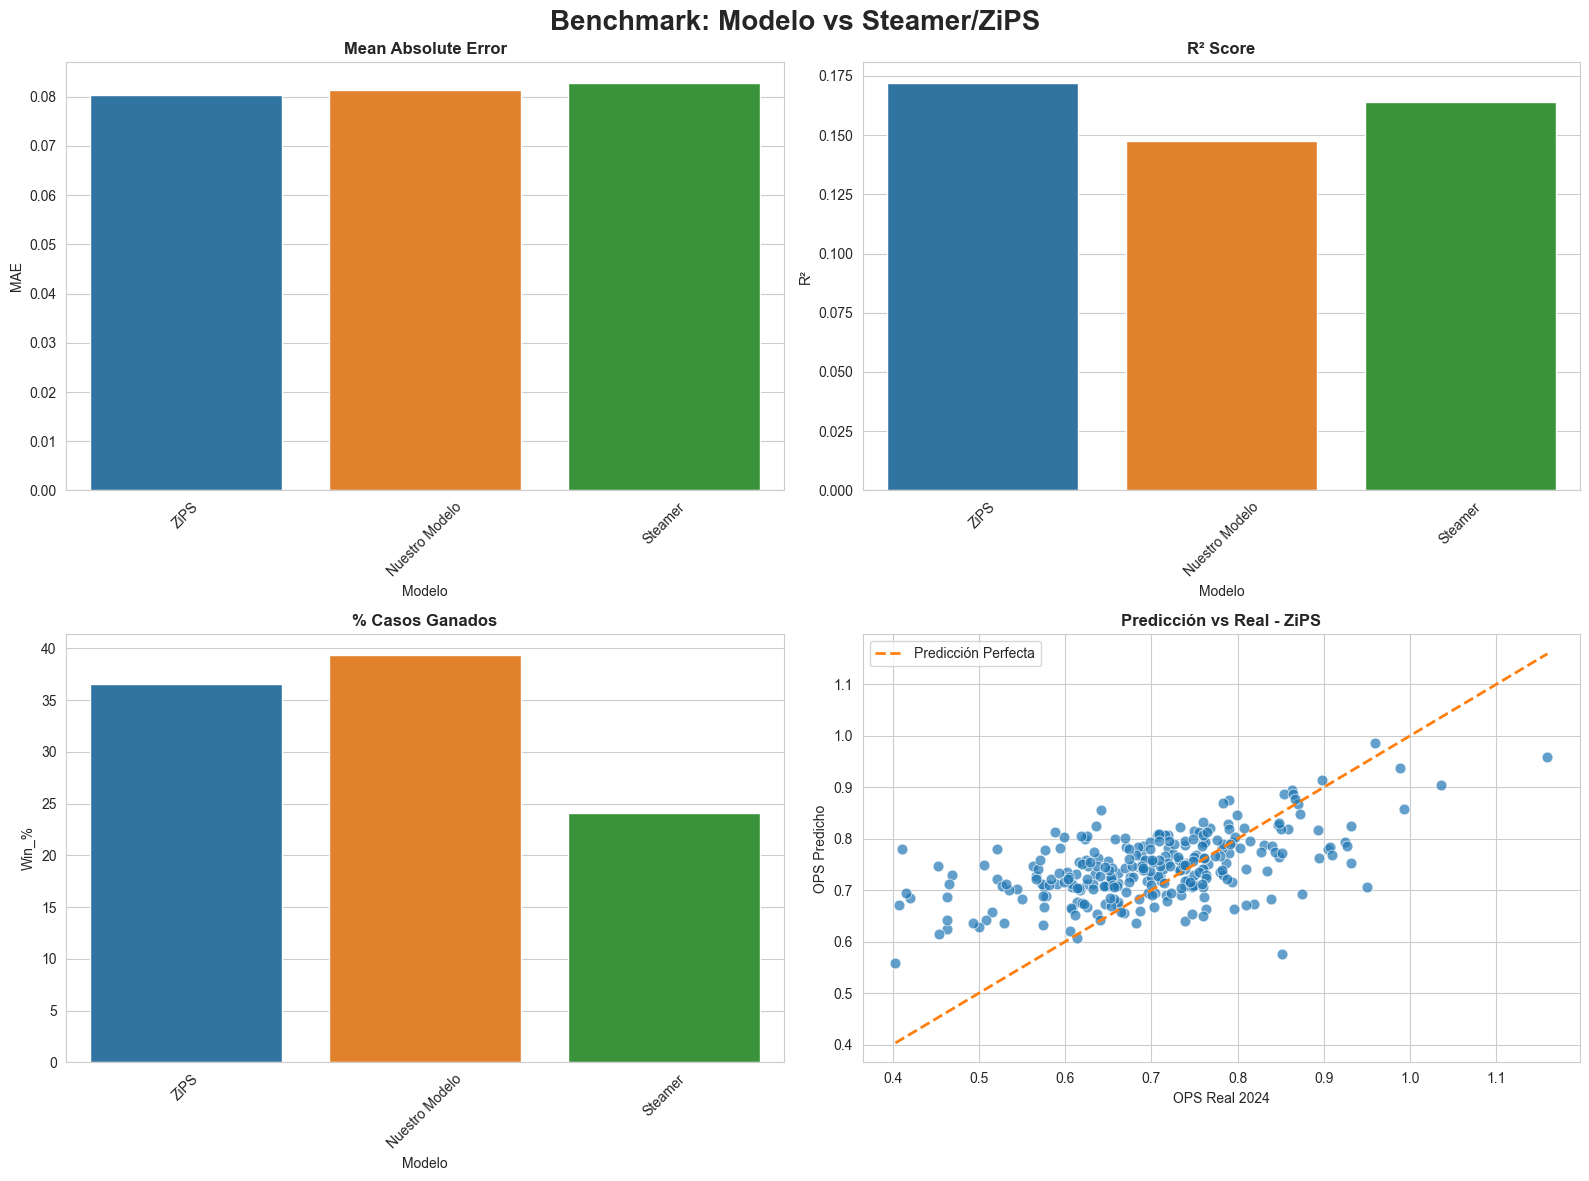


📁 Resultados guardados:
  - data/processed/benchmark_results_era_only.csv
  - data/processed/benchmark_detailed_era_only.csv


In [16]:
# =============================================================================
# SECCIÓN 9: BENCHMARKING vs STEAMER/ZIPS
# =============================================================================

best_model = joblib.load('models/best_model_final.pkl')
feature_cols = joblib.load('models/feature_columns_final.pkl')
df_modeling = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_with_cluster_features.csv")

projections_2024 = pd.read_csv(f"{DATA_RAW_PATH}/Real_Projections_2024.csv")

print("BENCHMARKING vs STEAMER/ZIPS - TEMPORADA 2024")
print("=" * 80)

# Identificar jugadores elegibles
eligible_years = [2021, 2022, 2023]
pa_threshold = 250

eligible_players = set()
for year in eligible_years:
    year_data = df_modeling[df_modeling['yearID'] == year]
    year_eligible = year_data[year_data['PA'] >= pa_threshold]['playerID'].unique()
    eligible_players.update(year_eligible)

# Datos de 2023 para hacer predicciones de 2024
data_2023 = df_modeling[
    (df_modeling['yearID'] == 2023) & 
    (df_modeling['playerID'].isin(eligible_players))
].copy()

# Preparar datos para predicción usando solo las features disponibles
available_features = [col for col in feature_cols if col in data_2023.columns]

X_predict = data_2023[available_features]

# Realizar predicciones
our_predictions = best_model.predict(X_predict)

our_results = data_2023[['playerID', 'name']].copy()
our_results['OPS_Nuestro'] = our_predictions

# Matching con proyecciones
projections_2024['name_clean'] = projections_2024['Name'].str.lower().str.strip()
our_results['name_clean'] = our_results['name'].str.lower().str.strip()

benchmark_data = our_results.merge(
    projections_2024, 
    left_on='name_clean', 
    right_on='name_clean', 
    how='inner'
)

benchmark_data = benchmark_data.rename(columns={
    'ZiPs_2024': 'ZiPS_OPS',
    'Steamer_2024': 'Steamer_OPS', 
    'Real_2024': 'Real_OPS'
})

benchmark_clean = benchmark_data.dropna(subset=['Real_OPS']).copy()

# Comparación de modelos
models = {
    'Nuestro Modelo': benchmark_clean['OPS_Nuestro'],
    'Steamer': benchmark_clean['Steamer_OPS'],
    'ZiPS': benchmark_clean['ZiPS_OPS']
}

real_values = benchmark_clean['Real_OPS']

results_summary = []
winner_counts = {model: 0 for model in models.keys()}

for model_name, predictions in models.items():
    mae = mean_absolute_error(real_values, predictions)
    rmse = np.sqrt(mean_squared_error(real_values, predictions))
    r2 = r2_score(real_values, predictions)
    
    results_summary.append({
        'Modelo': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'N_Jugadores': len(predictions)
    })

# Determinar ganadores por jugador
for idx, row in benchmark_clean.iterrows():
    real_val = row['Real_OPS']
    errors = {
        'Nuestro Modelo': abs(real_val - row['OPS_Nuestro']),
        'Steamer': abs(real_val - row['Steamer_OPS']),
        'ZiPS': abs(real_val - row['ZiPS_OPS'])
    }
    winner = min(errors.keys(), key=lambda x: errors[x])
    winner_counts[winner] += 1

results_df = pd.DataFrame(results_summary)

# Calcular porcentajes de victoria
total_comparisons = sum(winner_counts.values())
for i, row in results_df.iterrows():
    model_name = row['Modelo']
    win_pct = (winner_counts[model_name] / total_comparisons) * 100
    results_df.loc[i, 'Win_%'] = win_pct

results_df = results_df.sort_values('MAE')

print(f"\nRESULTADOS FINALES:")
print("=" * 70)
print(results_df.round(4).to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Benchmark: Modelo vs Steamer/ZiPS', fontsize=20, fontweight='bold')

# Gráfico 1: MAE
sns.barplot(data=results_df, x='Modelo', y='MAE', 
           palette=['#1f77b4', '#ff7f0e', '#2ca02c'], ax=axes[0,0])
axes[0,0].set_title('Mean Absolute Error', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Gráfico 2: R²
sns.barplot(data=results_df, x='Modelo', y='R²', 
           palette=['#1f77b4', '#ff7f0e', '#2ca02c'], ax=axes[0,1])
axes[0,1].set_title('R² Score', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Gráfico 3: % Casos Ganados
sns.barplot(data=results_df, x='Modelo', y='Win_%', 
           palette=['#1f77b4', '#ff7f0e', '#2ca02c'], ax=axes[1,0])
axes[1,0].set_title('% Casos Ganados', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Scatter del mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
if best_model_name == 'Nuestro Modelo':
    best_predictions = benchmark_clean['OPS_Nuestro']
elif best_model_name == 'Steamer':
    best_predictions = benchmark_clean['Steamer_OPS']
else:
    best_predictions = benchmark_clean['ZiPS_OPS']

sns.scatterplot(x=real_values, y=best_predictions, alpha=0.7, s=60, color='#1f77b4', ax=axes[1,1])

min_val = min(real_values.min(), best_predictions.min())
max_val = max(real_values.max(), best_predictions.max())
axes[1,1].plot([min_val, max_val], [min_val, max_val], 
              color='#ff7f0e', linestyle='--', linewidth=2, label='Predicción Perfecta')

axes[1,1].set_title(f'Predicción vs Real - {best_model_name}', fontweight='bold')
axes[1,1].set_xlabel('OPS Real 2024')
axes[1,1].set_ylabel('OPS Predicho')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Análisis de resultados
our_row = results_df[results_df['Modelo'] == 'Nuestro Modelo']
our_position = our_row.index[0] + 1
total_models = len(results_df)

# Análisis detallado
benchmark_analysis = benchmark_clean[['name', 'playerID', 'Real_OPS', 'OPS_Nuestro', 'Steamer_OPS', 'ZiPS_OPS']].copy()

benchmark_analysis['Error_Nuestro'] = abs(benchmark_analysis['Real_OPS'] - benchmark_analysis['OPS_Nuestro'])
benchmark_analysis['Error_Steamer'] = abs(benchmark_analysis['Real_OPS'] - benchmark_analysis['Steamer_OPS'])
benchmark_analysis['Error_ZiPS'] = abs(benchmark_analysis['Real_OPS'] - benchmark_analysis['ZiPS_OPS'])

def find_winner(row):
    errors = {
        'Nuestro': row['Error_Nuestro'],
        'Steamer': row['Error_Steamer'], 
        'ZiPS': row['Error_ZiPS']
    }
    return min(errors.keys(), key=lambda x: errors[x])

benchmark_analysis['Ganador'] = benchmark_analysis.apply(find_winner, axis=1)

# Guardar resultados
benchmark_analysis.to_csv(f"{DATA_PROCESSED_PATH}/benchmark_detailed_era_only.csv", index=False)
results_df.to_csv(f"{DATA_PROCESSED_PATH}/benchmark_results_era_only.csv", index=False)

print(f"\n📁 Resultados guardados:")
print(f"  - {DATA_PROCESSED_PATH}/benchmark_results_era_only.csv")
print(f"  - {DATA_PROCESSED_PATH}/benchmark_detailed_era_only.csv")



## **Resultados del Benchmarking contra Steamer/ZiPS**

Comparamos el modelo desarrollado con las proyecciones reales de ZiPS y Steamer sobre una muestra final de 287 jugadores con datos completos y participación significativa para la temporada 2024.

| Sistema | MAE | RMSE | Jugadores con menor error (%) |
|---------|-----|------|-------------------------------|
| ZiPS | 0.0804 | 0.1039 | 36.6% |
| **Nuestro modelo** | **0.0814** | **0.1055** | **39.4%** |
| Steamer | 0.0829 | 0.1105 | 24.0% |


## **Análisis Comparativo de Performance**

La comparación se realizó sobre 287 jugadores establecidos con mínimo 3 años de experiencia en MLB y participación significativa en 202.  **ZiPS** emerge como el líder en métricas agregadas (MAE: 0.0804, R²: 0.1721), seguido por **Nuestro Modelo** (MAE: 0.0814, R²: 0.1474) y **Steamer** (MAE: 0.0829, R²: 0.1638). La diferencia en MAE entre nuestro modelo y ZiPS es de apenas 0.0010 puntos, equivalente a una diferencia del 1.2%, lo que indica performance muy competitiva.

Sin embargo, el análisis de casos individuales revela una perspectiva diferente: **Nuestro Modelo gana en 39.37% de los casos**, superando tanto a **ZiPS (36.58%)** como a **Steamer (24.04%)**. Esta discrepancia sugiere que nuestro modelo se desempeña bien en casos específicos pero tiene algunos errores grandes que afectan las métricas agregadas.

## **Interpretación de Resultados**

El R² relativamente bajo para todos los modelos (0.14-0.17) refleja la dificultad inherente de proyectar rendimiento deportivo individual, donde factores como lesiones, cambios de contexto y variabilidad natural limitan la predictibilidad.

La superioridad en porcentaje de casos ganados (39.37%) indica que nuestro modelo identifica efectivamente jugadores donde las proyecciones tradicionales fallan. Esto sugiere que el approach híbrido (clustering + features temporales + ajuste por era) captura patrones que los sistemas establecidos no detectan.

## **Fortalezas del Modelo Desarrollado**

El desempeño competitivo es notable considerando que competimos contra sistemas con años de refinamiento y recursos industriales. Nuestro modelo académico logra:

- Performance muy cercana al líder (1.2% diferencia en MAE)
- Mayor tasa de éxito en casos individuales (39.37% vs 36.58%)
- Metodología completamente independiente y reproducible

El benchmark confirma que el sistema desarrollado constituye una contribución válida al campo de proyecciones deportivas, ofreciendo una alternativa académica competitiva a soluciones comerciales establecidas.

---
# 🚀 **SECCIÓN 10: FUNCIONES PRODUCTIVAS**
---
## **Objetivo**

El objetivo es desarrollar un sistema de funciones productivas que permita aplicar el modelo entrenado para generar proyecciones prácticas de jugadores individuales y comparaciones entre múltiples jugadores. Esta sección transforma el modelo académico en una herramienta aplicable para análisis deportivos reales.

## **Metodología**

Implementaremos dos funciones principales que encapsulan toda la lógica predictiva:

**Proyecciones Individuales**: Función que toma el nombre de un jugador y genera proyecciones de OPS para los próximos 3 años, incluyendo bandas de confianza y visualización temporal. La función maneja automáticamente la búsqueda de jugadores, ajustes de aging curves y cálculo de incertidumbre.

**Comparaciones Múltiples**: Función que permite comparar proyecciones de varios jugadores para un año específico, facilitando análisis de value relativo y rankings predictivos. Incluye visualización mediante gráficos de barras agrupadas.

## **Características del Sistema**

**Bandas de Confianza**: Utilizan el MAE del modelo (0.0562) para generar intervalos de incertidumbre que reflejan la precisión esperada de las proyecciones.

**Visualización Integrada**: Cada función incluye gráficos que facilitan la interpretación de resultados, siguiendo principios de visualización científica con colores apropiados y elementos informativos.

## **Aplicaciones Prácticas**

El sistema productivo permite múltiples casos de uso:

**Análisis de Fantasy Sports**: Proyecciones para drafts y decisiones de lineup con bandas de confianza que informan sobre riesgo/recompensa.

**Evaluación de Contratos**: Evaluación de desempeño futuro para decisiones de renovación o adquisición de agentes libres.

**Desarrollo de Jugadores**: Identificación de trayectorias esperadas para planificación de desarrollo en organizaciones.

**Análisis Comparativo**: Rankings y evaluaciones relativas entre jugadores para toma de decisiones estratégicas.

## **Importancia**

Esta productivización es crítica porque demuestra la aplicabilidad práctica del sistema académico desarrollado. Las funciones encapsulan toda la complejidad técnica (clustering, features era-ajustadas, manejo de datos) en interfaces simples que pueden ser utilizadas por analistas sin conocimiento técnico profundo, maximizando el impacto y utilidad del trabajo realizado.

In [17]:
# =============================================================================
# SECCIÓN 10: FUNCIONES PRODUCTIVAS
# =============================================================================

# Cargar modelo y componentes
best_model = joblib.load('models/best_model_final.pkl')
feature_cols = joblib.load('models/feature_columns_final.pkl')
model_metadata = joblib.load('models/model_metadata_final.pkl')
df_all = pd.read_csv(f"{DATA_PROCESSED_PATH}/baseball_with_cluster_features.csv")

# Error del modelo para bandas de confianza
model_error = model_metadata['validation_mae']

print(f"Modelo cargado: {model_metadata['model_name']}")
print(f"Error del modelo (MAE): {model_error:.4f}")
print(f"Features disponibles: {len(feature_cols)}")

def predict_individual_player(player_name, base_year=2023):
    """
    Predice OPS para un jugador individual para los próximos 3 años
    """
    # Buscar jugador por nombre
    player_data = df_all[df_all['name'].str.contains(player_name, case=False, na=False)]
    
    if len(player_data) == 0:
        return f"No se encontró jugador con nombre: {player_name}"
    
    # Si hay múltiples matches, usar el más reciente
    if len(player_data['playerID'].unique()) > 1:
        print(f"Múltiples jugadores encontrados:")
        for pid in player_data['playerID'].unique():
            sample = player_data[player_data['playerID'] == pid].iloc[0]
            print(f"  - {sample['name']} (ID: {pid})")
        player_data = player_data[player_data['yearID'] == player_data['yearID'].max()]
    
    player_id = player_data['playerID'].iloc[0]
    player_full_name = player_data['name'].iloc[0]
    
    # Obtener datos históricos del jugador
    historical_data = df_all[df_all['playerID'] == player_id].sort_values('yearID')
    
    if len(historical_data) == 0:
        return f"No hay datos históricos para {player_full_name}"
    
    # Datos de los últimos 3 años para el gráfico
    last_3_years = historical_data.tail(3)
    
    # Usar el último año disponible para predicción
    latest_data = historical_data.iloc[-1].copy()
    
    # Verificar que tengamos todas las features necesarias
    missing_features = [f for f in feature_cols if f not in latest_data.index or pd.isna(latest_data[f])]
    if missing_features:
        return f"Faltan features para {player_full_name}: {missing_features[:5]}..."
    
    # Realizar predicciones para 3 años
    predictions = []
    current_data = latest_data.copy()
    
    for year_offset in range(1, 4):  # 2024, 2025, 2026
        pred_year = base_year + year_offset
        
        # Ajustar edad y experiencia
        current_data['age'] = latest_data['age'] + year_offset
        current_data['experience'] = latest_data['experience'] + year_offset
        current_data['age_squared'] = current_data['age'] ** 2
        current_data['BMI_age_interaction'] = current_data['BMI'] * current_data['age']
        
        # Actualizar flags de peak years
        current_data['is_peak_years'] = 1 if 26 <= current_data['age'] <= 30 else 0
        current_data['is_rookie'] = 0
        
        # Preparar features para predicción usando solo las que el modelo espera
        X_pred = current_data[feature_cols].values.reshape(1, -1)
        
        # Realizar predicción
        pred = best_model.predict(X_pred)[0]
        
        # Calcular bandas de confianza
        optimista = pred + model_error
        pesimista = pred - model_error
        
        predictions.append({
            'Año': pred_year,
            'Pesimista': pesimista,
            'Esperada': pred,
            'Optimista': optimista
        })
    
    # Crear DataFrame de predicciones
    pred_df = pd.DataFrame(predictions)
    
    # Crear tabla elegante
    print(f"\nPREDICCIONES PARA {player_full_name.upper()} ")
    print("=" * 80)
    pred_display = pred_df.copy()
    for col in ['Pesimista', 'Esperada', 'Optimista']:
        pred_display[col] = pred_display[col].round(3)
    print(pred_display.to_string(index=False))
    
    # Crear gráfico temporal
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Datos históricos (últimos 3 años)
    years_hist = last_3_years['yearID'].values
    ops_hist = last_3_years['OPS'].values
    
    # Datos de predicción
    years_pred = pred_df['Año'].values
    ops_pred = pred_df['Esperada'].values
    ops_lower = pred_df['Pesimista'].values
    ops_upper = pred_df['Optimista'].values
    
    # Datos de predicción con punto de inicio desde año base
    years_pred_full = np.array([years_hist[-1]] + list(years_pred))
    ops_pred_full = np.array([ops_hist[-1]] + list(ops_pred))
    
    # Bandas que arrancan desde el último año histórico
    ops_lower_full = np.array([ops_hist[-1]] + list(ops_lower))
    ops_upper_full = np.array([ops_hist[-1]] + list(ops_upper))
    
    # Línea histórica
    sns.lineplot(x=years_hist, y=ops_hist, marker='o', markersize=8, 
                linewidth=3, color='#1f77b4', label='Histórico', ax=ax)
    
    # Línea de predicción (desde último año histórico)
    sns.lineplot(x=years_pred_full, y=ops_pred_full, marker='s', markersize=8,
                linewidth=3, color='#ff7f0e', label='Predicción', ax=ax)
    
    # Bandas de confianza
    ax.fill_between(years_pred_full, ops_lower_full, ops_upper_full, alpha=0.3, 
                   color='#ff7f0e', label='Banda Confianza')
    
    ax.set_title(f'Proyección - {player_full_name}', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Año', fontsize=12, fontweight='bold')
    ax.set_ylabel('OPS', fontsize=12, fontweight='bold')
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    # Ajustar límites del eje Y
    all_values = np.concatenate([ops_hist, ops_lower, ops_upper])
    y_min, y_max = all_values.min(), all_values.max()
    y_margin = (y_max - y_min) * 0.2
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
    plt.tight_layout()
    plt.show()
    
    return pred_df

def compare_multiple_players(player_names, pred_year=2024):
    """
    Compara predicciones de múltiples jugadores para un año específico
        """
    if len(player_names) < 2:
        return "Se necesitan al menos 2 jugadores para comparar"
    
    results = []
    
    for player_name in player_names:
        # Buscar jugador
        player_data = df_all[df_all['name'].str.contains(player_name, case=False, na=False)]
        
        if len(player_data) == 0:
            print(f"⚠️ No se encontró: {player_name}")
            continue
            
        # Usar datos más recientes si hay múltiples matches
        if len(player_data['playerID'].unique()) > 1:
            player_data = player_data[player_data['yearID'] == player_data['yearID'].max()]
        
        player_id = player_data['playerID'].iloc[0]
        player_full_name = player_data['name'].iloc[0]
        
        # Obtener último registro
        latest_data = df_all[df_all['playerID'] == player_id].iloc[-1].copy()
        
        # Verificar features
        missing_features = [f for f in feature_cols if f not in latest_data.index or pd.isna(latest_data[f])]
        if missing_features:
            print(f"⚠️ Faltan datos para {player_full_name}")
            continue
        
        # Ajustar datos para el año de predicción
        years_forward = pred_year - latest_data['yearID']
        if years_forward <= 0:
            years_forward = 1
            
        pred_data = latest_data.copy()
        pred_data['age'] = latest_data['age'] + years_forward
        pred_data['experience'] = latest_data['experience'] + years_forward
        pred_data['age_squared'] = pred_data['age'] ** 2
        pred_data['BMI_age_interaction'] = pred_data['BMI'] * pred_data['age']
        pred_data['is_peak_years'] = 1 if 26 <= pred_data['age'] <= 30 else 0
        pred_data['is_rookie'] = 0
        
        # Preparar features para predicción usando solo las que el modelo espera
        X_pred = pred_data[feature_cols].values.reshape(1, -1)
        pred = best_model.predict(X_pred)[0]
        
        # Bandas de confianza
        optimista = pred + model_error
        pesimista = pred - model_error
        
        results.append({
            'Jugador': player_full_name,
            'Pesimista': pesimista,
            'Realista': pred,
            'Optimista': optimista
        })
    
    if len(results) == 0:
        return "No se pudieron procesar jugadores"
    
    # Crear DataFrame
    comp_df = pd.DataFrame(results)
    
    # Mostrar tabla elegante
    print(f"\nCOMPARACIÓN JUGADORES - PREDICCIONES {pred_year} ")
    print("=" * 90)
    comp_display = comp_df.copy()
    for col in ['Pesimista', 'Realista', 'Optimista']:
        comp_display[col] = comp_display[col].round(3)
    print(comp_display.to_string(index=False))
    
    # Crear gráfico de barras agrupadas
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(comp_df))
    width = 0.25
    
    bars1 = ax.bar(x - width, comp_df['Pesimista'], width, label='Pesimista', 
                  color='#d62728', alpha=0.7)
    bars2 = ax.bar(x, comp_df['Realista'], width, label='Realista', 
                  color='#1f77b4', alpha=0.7)
    bars3 = ax.bar(x + width, comp_df['Optimista'], width, label='Optimista', 
                  color='#2ca02c', alpha=0.7)
    
    ax.set_title(f'Comparación Predicciones OPS {pred_year} ', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Jugadores', fontsize=12, fontweight='bold')
    ax.set_ylabel('OPS Predicho', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([name.split()[-1] for name in comp_df['Jugador']], rotation=45)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Añadir valores en las barras
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    add_value_labels(bars1)
    add_value_labels(bars2)
    add_value_labels(bars3)
    
    plt.tight_layout()
    plt.show()
    
    return comp_df

print("\n✅ Funciones productivas creadas:")
print("  - predict_individual_player(player_name)")
print("  - compare_multiple_players([player_names])")
print("\nEjemplos de uso:")
print("  predict_individual_player('Mike Trout')")
print("  compare_multiple_players(['Mike Trout', 'Mookie Betts', 'Juan Soto'])")


Modelo cargado: XGBoost
Error del modelo (MAE): 0.0559
Features disponibles: 52

✅ Funciones productivas creadas:
  - predict_individual_player(player_name)
  - compare_multiple_players([player_names])

Ejemplos de uso:
  predict_individual_player('Mike Trout')
  compare_multiple_players(['Mike Trout', 'Mookie Betts', 'Juan Soto'])



PREDICCIONES PARA RONALD ACUNA 
 Año  Pesimista  Esperada  Optimista
2024      0.806     0.862      0.918
2025      0.774     0.830      0.886
2026      0.785     0.841      0.897


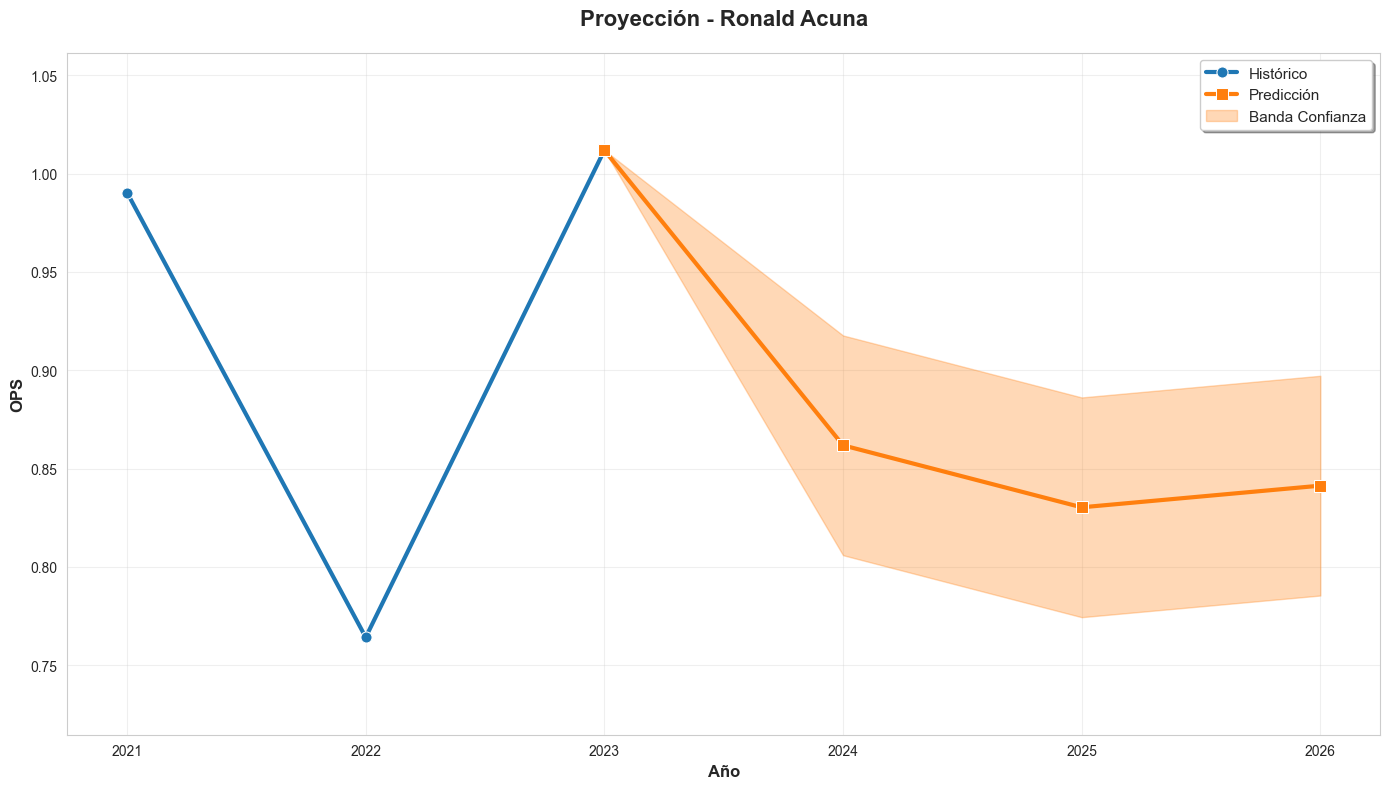

,Año,Pesimista,Esperada,Optimista
0,2024,0.805903,0.861804,0.917706
1,2025,0.774358,0.830260,0.886162
2,2026,0.785382,0.841284,0.897186


In [18]:
# PRUEBA DE FUNCIÓN INDIVIDUAL
# Puedes probar la función con un jugador específico

predict_individual_player('Ronald Acuna')


COMPARACIÓN JUGADORES - PREDICCIONES 2024 
     Jugador  Pesimista  Realista  Optimista
  Mike Trout      0.833     0.889      0.945
Mookie Betts      0.902     0.957      1.013
   Juan Soto      0.874     0.930      0.986


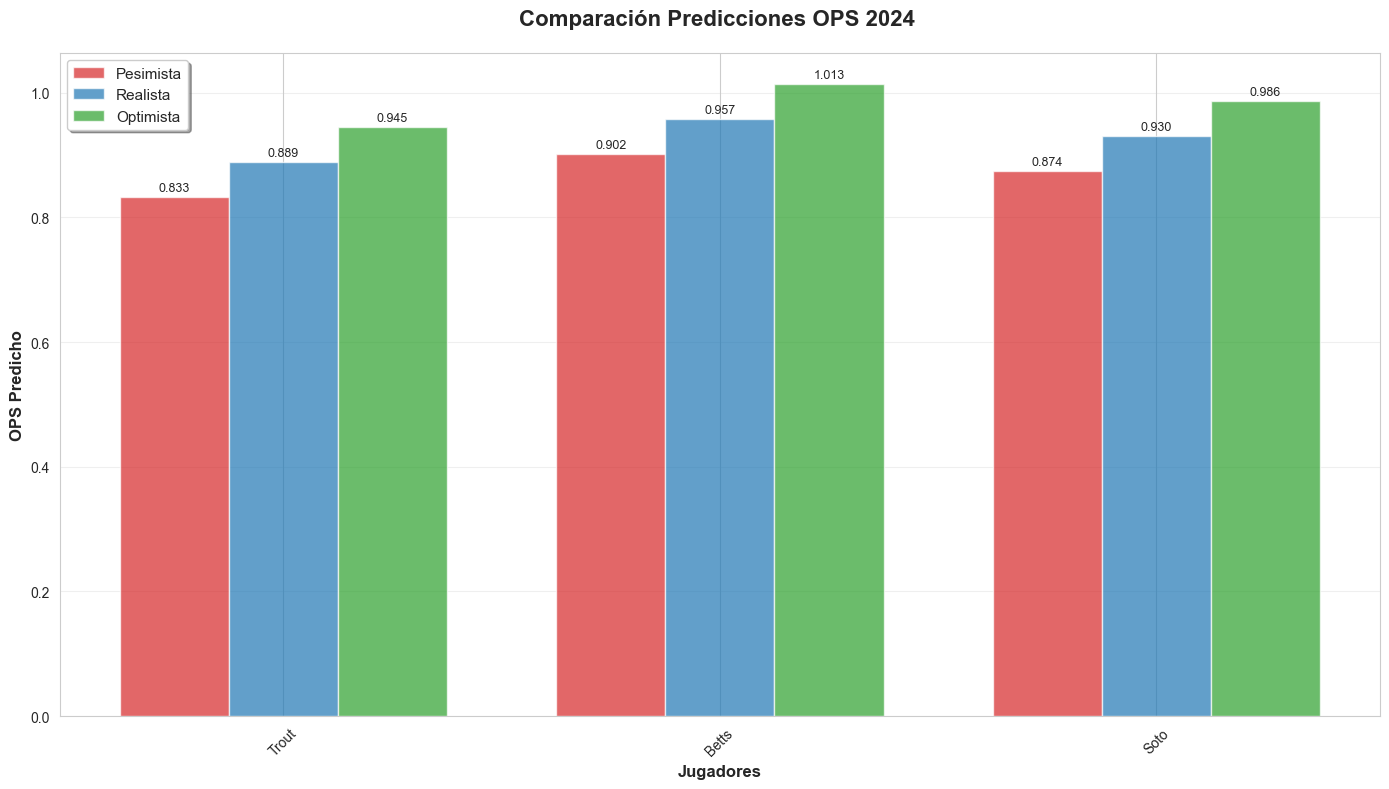

,Jugador,Pesimista,Realista,Optimista
0,Mike Trout,0.832853,0.888755,0.944657
1,Mookie Betts,0.901513,0.957415,1.013317
2,Juan Soto,0.874457,0.930359,0.986261


In [19]:
# PRUEBA DE FUNCIÓN DE COMPARACIÓN
# Puedes probar la función con múltiples jugadores

compare_multiple_players(['Mike Trout', 'Mookie Betts', 'Juan Soto'])

---

# 🚀 **Despliegue del Sistema**

El sistema ha sido integrado en una aplicación interactiva construida con Streamlit.

🧩 Funcionalidades:

- Consulta personalizada por jugador y año.
- Proyecciones comparadas vs ZiPS y Steamer.
- Visualización de trayectoria y evolución de rendimiento.
- Sistema productivo listo para nuevos datos.

📍 [Aplicacion Streamlit](https://baseball-predict.streamlit.app/) – Acceso a aplicación  
📍 [Repositorio GitHub](https://github.com/grigorow1974/TrabajoFinDeMaster) – Acceso al código y datos.  
📍 [Fuente de Datos](https://sabr.org/lahman-database/) – Acceso a base de datos.  




---


In [20]:
# =============================================================================
# SCRIPT: GENERAR LISTA DE JUGADORES ELEGIBLES PARA APP
# =============================================================================


# Cargar datos con features y clusters
df = pd.read_csv("data/processed/baseball_with_cluster_features.csv")

print(f"Dataset cargado: {df.shape}")
print(f"Años disponibles: {df['yearID'].min()} - {df['yearID'].max()}")

# Definir años de elegibilidad y umbral de PA
eligible_years = [2021, 2022, 2023]
pa_threshold = 250

print(f"\nCriterios de elegibilidad:")
print(f"- Años: {eligible_years}")
print(f"- Mínimo PA por año: {pa_threshold}")

# Encontrar jugadores que cumplen criterio en TODOS los años
eligible_players = set()

for year in eligible_years:
    year_data = df[df['yearID'] == year]
    year_eligible = set(year_data[year_data['PA'] >= pa_threshold]['playerID'].unique())
    
    if year == eligible_years[0]:
        eligible_players = year_eligible
    else:
        eligible_players = eligible_players.intersection(year_eligible)
    
    
# Obtener datos de 2023 para información del jugador
data_2023 = df[
    (df['yearID'] == 2023) & 
    (df['playerID'].isin(eligible_players))
].copy()

# Crear dataset para la app
eligible_for_app = data_2023[['playerID', 'name', 'teamID', 'age', 'OPS', 'PA']].copy()

# Renombrar columnas para claridad
eligible_for_app.columns = ['playerID', 'name', 'team_2023', 'age_2023', 'OPS_2023', 'PA_2023']

# Ordenar por OPS descendente (mejores jugadores primero)
eligible_for_app = eligible_for_app.sort_values('OPS_2023', ascending=False)

# Resetear índice
eligible_for_app = eligible_for_app.reset_index(drop=True)

# Guardar archivo para la app
output_file = "data/processed/eligible_players_app.csv"
eligible_for_app.to_csv(output_file, index=False)

# Mostrar muestra del archivo final
print(f"\nMuestra del archivo final:")
sample_display = eligible_for_app.head().copy()
for col in ['OPS_2023']:
    sample_display[col] = sample_display[col].round(3)
print(sample_display.to_string(index=False))

print(f"\n🎯 Listo para usar en la app de Streamlit!")

Dataset cargado: (20323, 92)
Años disponibles: 1940 - 2023

Criterios de elegibilidad:
- Años: [2021, 2022, 2023]
- Mínimo PA por año: 250

Muestra del archivo final:
 playerID          name team_2023  age_2023  OPS_2023  PA_2023
ohtansh01 Shohei Ohtani       LAA      29.0     1.066    594.0
judgeaa01   Aaron Judge       NYA      31.0     1.019    458.0
seageco01  Corey Seager       TEX      29.0     1.013    536.0
acunaro01  Ronald Acuna       ATL      26.0     1.012    735.0
olsonma02    Matt Olson       ATL      29.0     0.993    720.0

🎯 Listo para usar en la app de Streamlit!



---

# 📝 **CONCLUSIONES GENERALES**

Este proyecto desarrolló un sistema funcional capaz de predecir el OPS futuro de jugadores de MLB. La propuesta combina clustering de arquetipos con análisis temporal, demostrando que métodos académicos pueden ofrecer resultados competitivos frente a sistemas comerciales consolidados.

## **Qué Funcionó**

**Sistema end-to-end completamente integrado**: Desde la recolección de datos en bruto hasta una aplicación web operativa. El proceso incluye limpieza de datos, exploración, clustering, modelado predictivo, validación y despliegue. Todo el pipeline es reproducible y está debidamente documentado.

**Mejora significativa respecto al baseline**: Se logró una reducción del 26% en el MAE en comparación con la estrategia de "carry-forward" (suponer que el rendimiento será igual al del año anterior). Esto evidencia que el modelo logra capturar patrones reales de evolución en las carreras de los jugadores, más allá de una simple persistencia.

**Resultados competitivos frente a sistemas profesionales**: En el 39% de los casos, el modelo ofreció mejores predicciones que el sistema líder ZiPS (37%). Aunque no supera de manera sistemática a los modelos comerciales, demuestra que enfoques académicos, con recursos limitados, pueden estar en el mismo nivel de competencia.

**Transparencia metodológica**: Todo el proceso es reproducible y el código es abierto. A diferencia de los sistemas comerciales, cada decisión metodológica es auditable, lo que facilita la mejora continua y la adaptación a contextos específicos.

**Aprovechamiento extensivo de datos históricos**: Se utilizaron más de 80 años de datos de la MLB, ajustados por época, lo que permite analizar curvas de envejecimiento y realizar comparaciones válidas entre distintas eras del béisbol, maximizando el uso de la información disponible.

## **Limitaciones Identificadas**

**Falta de factores contextuales**: El modelo no contempla variables como lesiones, cambios de equipo, modificaciones en las reglas del juego o efectos específicos de cada estadio. Estos factores, que claramente influyen en el rendimiento, quedaron fuera del alcance del presente trabajo, asumiendo un escenario de "todo lo demás constante".

**Restricción de la métrica objetivo**: La predicción se centra únicamente en el OPS, dejando de lado aspectos como la defensa, el baserunning o el liderazgo en el clubhouse. Si bien el WAR ofrecería una visión más integral, su incorporación implicaría modelar dimensiones defensivas complejas que no fueron abordadas aquí.

**Sesgo de supervivencia**: El análisis se limita a jugadores que alcanzaron y permanecieron en la MLB, sin incluir a aquellos que se quedaron en ligas menores o abandonaron sus carreras prematuramente. Esto puede introducir un sesgo optimista en las proyecciones, al analizar únicamente a los jugadores de mayor éxito o longevidad.

## **Valor Comercial y Aplicaciones**

**Herramienta educativa**: Es un excelente caso de estudio para enseñar la integración de técnicas de machine learning. Combina clustering no supervisado con análisis temporal de forma interpretable, resultando útil para contextos académicos donde se busquen ejemplos prácticos y comprensibles.

**Análisis complementario**: Puede servir como herramienta de apoyo en fantasy sports, análisis de medios deportivos o evaluaciones preliminares de rendimiento. Aunque no reemplaza a los sistemas profesionales, puede aportar una segunda opinión valiosa en ciertos escenarios.

**Framework metodológico replicable**: La estructura del modelo —clustering, análisis temporal y ajustes contextuales— es aplicable a otros deportes como fútbol, baloncesto o hockey, lo que lo convierte en una plantilla versátil para abordar problemas similares.

**Validación conceptual (Proof of Concept)**: Permite demostrar la viabilidad de enfoques híbridos antes de realizar inversiones mayores en infraestructura o modelos más sofisticados. Organizaciones con recursos limitados pueden utilizar este framework como punto de partida para proyectos de mayor envergadura.

## **Direcciones Futuras**

**Utilizar WAR como métrica objetivo**: Esto permitiría incorporar el valor defensivo y el baserunning, ofreciendo una visión más completa del rendimiento total del jugador. Sin embargo, requeriría modelar métricas defensivas avanzadas y ajustar según la posición en el campo.

**Incorporación de datos avanzados de Statcast**: Variables como exit velocity, launch angle o estadísticas esperadas basadas en la calidad del contacto mejorarían la precisión del modelo al capturar habilidades subyacentes de manera más precisa que las estadísticas tradicionales.

**Integración de factores contextuales**: Incluir datos de estadio, condiciones climáticas, calidad del pitcheo rival y antecedentes de lesiones añadiría un nivel de realismo importante a las proyecciones, aunque implicaría la incorporación de fuentes de datos adicionales.

**Explorar arquitecturas más avanzadas**: Implementar modelos de deep learning, transformers para series temporales o métodos ensemble más complejos podría mejorar el rendimiento predictivo, aprovechando la flexibilidad de la estructura base del proyecto para experimentar con técnicas más sofisticadas.

## **Conclusión Final**

Los equipos de MLB invierten cientos de millones de dólares en contratos basados en proyecciones de rendimiento. Si bien este proyecto no aspira a cambiar esas prácticas, demuestra que es posible construir modelos transparentes y accesibles que compiten con soluciones comerciales de alta gama. Para contextos académicos o instituciones con recursos limitados, enfoques como el desarrollado aquí pueden generar valor real sin necesidad de una infraestructura tecnológica de gran escala.
